In [1]:
import pandas as pd
import geopandas as gpd
import sys, os


In [ ]:
# event_ids = os.listdir("/data/big/fmoss/data/past_forecasts/kms/")
# df_windfield_all = pd.DataFrame()
# for event in event_ids:
#     df_windfield = pd.read_csv(f"/data/big/fmoss/data/past_forecasts/kms/{event}")
#     df_windfield = df_windfield.drop(columns=["geometry"])
#     df_windfield_all = pd.concat([df_windfield_all, df_windfield], ignore_index=True)

In [2]:
model_input = pd.read_parquet("/data/big/fmoss/data/model_input_dataset/training_dataset_weighted_N_events.parquet")

events_to_consider = [
    '2016-0256-TWN', '2016-0350-TWN', '2017-0432-PHL', '2012-0282-CHN',
    '2020-0308-CHN', '2016-0256-PHL', '2018-0347-CHN', '2016-0256-CHN',
    '2019-0472-KOR', '2016-0350-CHN', '2020-0425-VNM', '2019-0424-PRK',
    '2016-0490-PHL', '2019-0549-PHL', '2018-0285-CHN', '2020-0403-KOR',
    '2012-0294-CHN', '2016-0363-PHL', '2020-0470-VNM', '2016-0503-PHL',
    '2017-0432-JPN', '2018-0399-PHL', '2020-0470-PHL', '2012-0294-VNM',
    '2019-0573-PHL', '2016-0342-CHN'
       ]
stationary_data = model_input[model_input["DisNo."].isin(events_to_consider)].drop(columns=["wind_speed", "track_distance"])

In [2]:
emdat = pd.read_csv("/data/big/fmoss/data/EMDAT/emdat-tropicalcyclone-2000-2022-processed-sids.csv")

In [8]:
events_to_consider = [
    '2016-0256-TWN', '2016-0350-TWN', '2017-0432-PHL', '2012-0282-CHN',
    '2020-0308-CHN', '2016-0256-PHL', '2018-0347-CHN', '2016-0256-CHN',
    '2019-0472-KOR', '2016-0350-CHN', '2020-0425-VNM', '2019-0424-PRK',
    '2016-0490-PHL', '2019-0549-PHL', '2018-0285-CHN', '2020-0403-KOR',
    '2012-0294-CHN', '2016-0363-PHL', '2020-0470-VNM', '2016-0503-PHL',
    '2017-0432-JPN', '2018-0399-PHL', '2020-0470-PHL', '2012-0294-VNM',
    '2019-0573-PHL', '2016-0342-CHN'
       ]

emdat_red = emdat[["DisNo.", "sid", "iso3", "Event Name", 'Start Year',
       'Start Month', 'Start Day']]
emdat_red[emdat_red["DisNo."].isin(events_to_consider)]

,DisNo.,sid,iso3,Event Name,Start Year,Start Month,Start Day
229,2016-0256-PHL,2016185N08145,PHL,Typhoon Butchoy (Nepartak),2016,7,8.0
231,2016-0363-PHL,2016287N13130,PHL,Typhoon Karen (Sarika),2016,10,16.0
234,2016-0490-PHL,2016266N11144,PHL,Typhoon Helen (Megi),2016,9,28.0
235,2016-0503-PHL,2016355N07146,PHL,Typhoon 'Nina' (Nock-Ten),2016,12,25.0
240,2017-0432-PHL,2017288N09138,PHL,Typhoon 'Lan'/'Paolo',2017,10,18.0
247,2018-0399-PHL,2018294N08161,PHL,Typhoon 'Yutu' (Rosita),2018,10,30.0
253,2019-0549-PHL,2019308N13114,PHL,Tropical cyclone 'Nakri',2019,11,10.0
254,2019-0573-PHL,2019329N09160,PHL,Tropical cyclone 'Kammuri' (Tisoy),2019,12,2.0
259,2020-0470-PHL,2020296N09137,PHL,Typhoon 'Molave' (Quinta),2020,10,28.0
363,2017-0432-JPN,2017288N09138,JPN,Typhoon 'Lan'/'Paolo',2017,10,22.0


In [ ]:
# testing_data.to_parquet("/data/big/fmoss/data/past_forecasts/testing_dataset_kms_members.parquet", index=False)

Evaluation

In [3]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

from xgboost import XGBClassifier, XGBRegressor

save_path_classifier = "/data/big/fmoss/data/past_forecasts/model_first_stage_model.json"
save_path_regressor = "/data/big/fmoss/data/past_forecasts/second_stage_model.json"

# Load the trained models
clf_loaded = XGBClassifier()
clf_loaded.load_model(save_path_classifier)

reg_loaded = XGBRegressor()
reg_loaded.load_model(save_path_regressor)

features = [
    "wind_speed",
    # "track_distance",
    "rainfall_max_24h",
    # "N_events_5_years",
    "N_events_5_years_weighted",
    "population",
    "coast_length",
    "with_coast",
    "mean_elev",
    "mean_slope",
    "mean_rug",
    "urban",
    "rural",
    "water",
    "storm_tide_rp_0010",
    "landslide_risk_sum",
    # "flood_risk",
    # "shdi",
    # "perc_affected_pop_grid_region"
    ]

import pandas as pd
import numpy as np

def run_two_stage_predictions(testing_data, clf_loaded, reg_loaded, features):
    """
    Run a two-stage model (classifier + regression) for each (country, event, ensemble member) combination.

    Parameters
    ----------
    testing_data : DataFrame
        Must include columns ['GID_0','sid_x','ensemble_member','DisNo.','id','population'] + features.
    clf_loaded : fitted classifier model
        Must have a predict_proba method.
    reg_loaded : fitted regression model
        Must have a predict method.
    features : list
        Feature column names used in both models.

    Returns
    -------
    DataFrame
        Combined predictions for all test combinations, including:
        ['DisNo.','sid_x','sid_y','GID_0','GID_1','id','population','ensemble_member',
         'actual_perc','prediction_perc','actual_ppl','prediction_ppl','sid','member']
    """
    df_predictions = pd.DataFrame()

    # Unique country–event–member combinations
    aux = testing_data[["GID_0", "sid_x", "ensemble_member"]].drop_duplicates()

    for row in aux.itertuples(index=False):
        country = row.GID_0
        sid = row.sid_x
        member = row.ensemble_member

        # Select test data for this combination
        df_test = testing_data[
            (testing_data.sid_x == sid)
            & (testing_data.GID_0 == country)
            & (testing_data.ensemble_member == member)
        ].sort_values("id")

        if df_test.empty:
            continue

        event_id = df_test["DisNo."].iloc[0]

        # 🟢 Stage 1 — Classification
        X_test = df_test[features]
        y_proba = clf_loaded.predict_proba(X_test)[:, 1]
        df_test = df_test.copy()
        df_test["predicted_bin"] = (y_proba >= 0.5).astype(int)

        # # 🟢 Get actuals (handle missing events)
        # if event_id in df_train["DisNo."].unique():
        #     y_test = (
        #         df_train[df_train["DisNo."] == event_id]
        #         .sort_values("id")["perc_affected_pop_grid_region"]
        #     )
        # else:
        #     y_test = pd.Series([0] * len(df_test))

        # 🟢 Stage 2 — Regression (only for predicted impact)
        df_stage2 = df_test[df_test["predicted_bin"] == 1].copy()
        if not df_stage2.empty:
            df_stage2["prediction_perc"] = reg_loaded.predict(df_stage2[features])
        else:
            df_stage2 = pd.DataFrame(columns=df_test.columns.tolist() + ["prediction_perc"])

        # Rows predicted as no impact
        df_stage2_zero = df_test[df_test["predicted_bin"] == 0].copy()
        df_stage2_zero["prediction_perc"] = 0

        # Combine both subsets
        df_test_full = pd.concat([df_stage2, df_stage2_zero], axis=0).sort_index()

        # 🟢 Organize output
        df_test_reduced = df_test_full[[
            "DisNo.", "sid_x", "sid_y", "GID_0", "GID_1", "id",
            "population", "wind_speed", "track_distance", "delta_time", "ensemble_member"
        ]].copy()

        # df_test_reduced["actual_perc"] = y_test.to_list()
        df_test_reduced["prediction_perc"] = df_test_full["prediction_perc"].values

        # Clip predictions to 0–100%
        df_test_reduced["prediction_perc"] = df_test_reduced["prediction_perc"].clip(0, 100)

        # Convert percentages → absolute numbers
        # df_test_reduced["actual_ppl"] = df_test_reduced["actual_perc"] * df_test_reduced["population"] / 100
        df_test_reduced["prediction_ppl"] = df_test_reduced["prediction_perc"] * df_test_reduced["population"] / 100

        # Keep one row per grid
        df_test_reduced = df_test_reduced.drop_duplicates(subset=["DisNo.", "id"]).reset_index(drop=True)

        # Add identifiers
        df_test_reduced["sid"] = sid
        df_test_reduced["member"] = member

        # Append to master
        df_predictions = pd.concat([df_predictions, df_test_reduced], ignore_index=True)

    return df_predictions


def run_two_stage_predictions_historical(testing_data, clf_loaded, reg_loaded, features):
    """
    Run a two-stage model (classifier + regression) for each (country, event, ensemble member) combination.

    Parameters
    ----------
    testing_data : DataFrame
        Must include columns ['GID_0','sid_x','ensemble_member','DisNo.','id','population'] + features.
    clf_loaded : fitted classifier model
        Must have a predict_proba method.
    reg_loaded : fitted regression model
        Must have a predict method.
    features : list
        Feature column names used in both models.

    Returns
    -------
    DataFrame
        Combined predictions for all test combinations, including:
        ['DisNo.','sid_x','sid_y','GID_0','GID_1','id','population','ensemble_member',
         'actual_perc','prediction_perc','actual_ppl','prediction_ppl','sid','member']
    """
    df_predictions = pd.DataFrame()


    # Select test data for this combination
    df_test = testing_data.sort_values("id")

    # 🟢 Stage 1 — Classification
    X_test = df_test[features]
    y_proba = clf_loaded.predict_proba(X_test)[:, 1]
    df_test = df_test.copy()
    df_test["predicted_bin"] = (y_proba >= 0.5).astype(int)

    # 🟢 Stage 2 — Regression (only for predicted impact)
    df_stage2 = df_test[df_test["predicted_bin"] == 1].copy()
    if not df_stage2.empty:
        df_stage2["prediction_perc"] = reg_loaded.predict(df_stage2[features])
    else:
        df_stage2 = pd.DataFrame(columns=df_test.columns.tolist() + ["prediction_perc"])

    # Rows predicted as no impact
    df_stage2_zero = df_test[df_test["predicted_bin"] == 0].copy()
    df_stage2_zero["prediction_perc"] = 0

    # Combine both subsets
    df_test_full = pd.concat([df_stage2, df_stage2_zero], axis=0).sort_index()

    # 🟢 Organize output
    df_test_reduced = df_test_full[[
        "DisNo.", "GID_0", "GID_1", "id",
        "population", "wind_speed", 
    ]].copy()

    # df_test_reduced["actual_perc"] = y_test.to_list()
    df_test_reduced["prediction_perc"] = df_test_full["prediction_perc"].values

    # Clip predictions to 0–100%
    df_test_reduced["prediction_perc"] = df_test_reduced["prediction_perc"].clip(0, 100)

    # Convert percentages → absolute numbers
    # df_test_reduced["actual_ppl"] = df_test_reduced["actual_perc"] * df_test_reduced["population"] / 100
    df_test_reduced["prediction_ppl"] = df_test_reduced["prediction_perc"] * df_test_reduced["population"] / 100

    # Keep one row per grid
    df_test_reduced = df_test_reduced.drop_duplicates(subset=["DisNo.", "id"]).reset_index(drop=True)

    # Append to master
    df_predictions = pd.concat([df_predictions, df_test_reduced], ignore_index=True)

    return df_predictions


predicitons on past forecasts

In [ ]:
event_ids = os.listdir("/data/big/fmoss/data/past_forecasts/kms/")
df_windfield_all = pd.DataFrame()
for event in event_ids:
    # Load data
    df_windfield = pd.read_csv(f"/data/big/fmoss/data/past_forecasts/kms/{event}")
    # Testing set
    testing_data = df_windfield.drop("geometry", axis=1).merge(stationary_data, on=["GID_0", "DisNo.", "id"])
    testing_data = testing_data.dropna(subset="ensemble_member")
    # Binary column
    testing_data["reported_bin"] = (testing_data["perc_affected_pop_grid_region"] > 0).astype(int)
    # Training set (for getting reported impact)
    events_testing = testing_data["DisNo."].unique()
    df_train = model_input[~model_input["DisNo."].isin(events_testing)]
    df_predictions = run_two_stage_predictions(testing_data, df_train, clf_loaded, reg_loaded, features)
    df_predictions.to_csv(f"/data/big/fmoss/data/past_forecasts/predictions/kms/{event}", index=False)
    del df_predictions
    del df_windfield
    del testing_data
    print(f"{event} completed")


predicitons on historical data

In [6]:
event_ids = os.listdir("/data/big/fmoss/data/past_forecasts/kms/")
for event in event_ids:
    # Load data
    testing_data = model_input[model_input["DisNo."] == event.split(".")[0]].copy()
    # Binary column
    testing_data["reported_bin"] = (testing_data["perc_affected_pop_grid_region"] > 0).astype(int)
    # Training set (for getting reported impact)
    df_predictions = run_two_stage_predictions_historical(testing_data, clf_loaded, reg_loaded, features)
    os.makedirs("/data/big/fmoss/data/past_forecasts/predictions/kms/historical_tracks/", exist_ok=True)
    df_predictions.to_csv(f"/data/big/fmoss/data/past_forecasts/predictions/kms/historical_tracks/{event}", index=False)
    del df_predictions
    del testing_data
    print(f"{event} completed")

2019-0549-PHL.csv completed
2019-0424-PRK.csv completed
2018-0399-PHL.csv completed
2017-0432-PHL.csv completed


/tmp/ipykernel_1754362/4105956371.py:192: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_test_full = pd.concat([df_stage2, df_stage2_zero], axis=0).sort_index()


2016-0503-PHL.csv completed
2020-0470-VNM.csv completed
2017-0432-JPN.csv completed
2016-0256-PHL.csv completed
2020-0403-KOR.csv completed
2016-0256-CHN.csv completed
2018-0285-CHN.csv completed
2012-0294-CHN.csv completed
2019-0573-PHL.csv completed
2016-0490-PHL.csv completed
2016-0363-PHL.csv completed
2016-0350-TWN.csv completed
2020-0425-VNM.csv completed
2018-0347-CHN.csv completed
2020-0308-CHN.csv completed
2020-0470-PHL.csv completed
2016-0342-CHN.csv completed
2019-0472-KOR.csv completed
2012-0294-VNM.csv completed
2012-0282-CHN.csv completed
2016-0256-TWN.csv completed
2016-0350-CHN.csv completed


In [58]:
event = os.listdir("/data/big/fmoss/data/past_forecasts/kms/")[1]
# Load data
df_windfield = pd.read_csv(f"/data/big/fmoss/data/past_forecasts/kms/{event}")
# Testing set
testing_data = df_windfield.drop("geometry", axis=1).merge(stationary_data, on=["GID_0", "DisNo.", "id"])
testing_data = testing_data.dropna(subset="ensemble_member")
# Binary column
testing_data["reported_bin"] = (testing_data["perc_affected_pop_grid_region"] > 0).astype(int)
# Training set (for getting reported impact)
events_testing = testing_data["DisNo."].unique()
df_train = model_input[~model_input["DisNo."].isin(events_testing)]
df_predictions = run_two_stage_predictions(testing_data, df_train, clf_loaded, reg_loaded, features)

In [55]:
df_predictions.columns

Index(['DisNo.', 'sid_x', 'sid_y', 'GID_0', 'GID_1', 'id', 'population',
       'wind_speed', 'track_distance', 'delta_time', 'ensemble_member',
       'actual_perc', 'prediction_perc', 'actual_ppl', 'prediction_ppl', 'sid',
       'member'],
      dtype='object')

In [60]:
df_predictions[["DisNo.", "delta_time", "ensemble_member", "id", "prediction_perc"]].sort_values("prediction_perc")

,DisNo.,delta_time,ensemble_member,id,prediction_perc
47183,2019-0424-PRK,48.0,6.0,PRK_5418,0.000000
81969,2019-0424-PRK,24.0,4.0,PRK_3872,0.000000
81968,2019-0424-PRK,24.0,4.0,PRK_3918,0.000000
81967,2019-0424-PRK,24.0,4.0,PRK_3873,0.000000
23032,2019-0424-PRK,36.0,15.0,PRK_4556,0.000000
...,...,...,...,...,...
14356,2019-0424-PRK,36.0,9.0,PRK_1775,35.156361
83632,2019-0424-PRK,24.0,5.0,PRK_1775,35.156361
26379,2019-0424-PRK,36.0,17.0,PRK_1928,35.385357
14623,2019-0424-PRK,36.0,9.0,PRK_1704,35.466785


ADM1 results

In [4]:
def compute_grid_level_ensemble(df_predictions):
    group_keys = ["DisNo.", "GID_0", "GID_1", "sid_x", "delta_time", "id"]
    grid_agg = (
        df_predictions.groupby(group_keys)
        .agg(
            prediction_ppl_mean=("prediction_ppl", "mean"), 
            prediction_ppl_median=("prediction_ppl", "median"), 
            prediction_ppl_q25    = ("prediction_ppl", lambda x: np.quantile(x, 0.25)), 
            prediction_ppl_q75    = ("prediction_ppl", lambda x: np.quantile(x, 0.75)), 
            prediction_ppl_std=("prediction_ppl", "std"), 
            prediction_ppl_max=("prediction_ppl", "max"), 
            actual_ppl=("actual_ppl", "mean"), 
            actual_perc=("actual_perc", "mean"), 
            population=("population", "mean"), 
            wind_speed_mean=("wind_speed", "mean"),
            wind_speed_std=("wind_speed", "std"),
            wind_speed_max=("wind_speed", "max"),
            wind_speed_median=("wind_speed", "median"),
            wind_speed_q25 = ("wind_speed", lambda x: np.quantile(x, 0.25)), 
            wind_speed_q75 = ("wind_speed", lambda x: np.quantile(x, 0.75)), 
        )
        .reset_index()
    )
    
    # Compute mean predicted percentage at grid level 
    grid_agg["predicted_mean"] = 100 * grid_agg["prediction_ppl_mean"] / grid_agg["population"]
    grid_agg["predicted_std"] = 100 * grid_agg["prediction_ppl_std"] / grid_agg["population"]
    grid_agg["predicted_max"] = 100 * grid_agg["prediction_ppl_max"] / grid_agg["population"]

    grid_agg["predicted_median"] = 100 * grid_agg["prediction_ppl_median"] / grid_agg["population"]
    grid_agg["predicted_q25"] = 100 * grid_agg["prediction_ppl_q25"] / grid_agg["population"]
    grid_agg["predicted_q75"] = 100 * grid_agg["prediction_ppl_q75"] / grid_agg["population"]

    grid_agg["predicted_mean"] = grid_agg["predicted_mean"].clip(0, 100)
    grid_agg["predicted_max"] = grid_agg["predicted_max"].clip(0, 100)
    grid_agg["predicted_median"] = grid_agg["predicted_median"].clip(0, 100)
    grid_agg["predicted_q25"] = grid_agg["predicted_q25"].clip(0, 100).fillna(0)
    grid_agg["predicted_q75"] = grid_agg["predicted_q75"].clip(0, 100).fillna(0)
    grid_agg["predicted_std"] = grid_agg["predicted_std"].clip(0, 100).fillna(0)
    grid_agg["reported"] = grid_agg["actual_perc"].clip(0, 100)

    # Wind model: assign all population if threshold exceeded
    grid_agg["predicted_wind_mean"] = np.where(grid_agg["wind_speed_mean"] > 33, grid_agg["population"], 0)
    grid_agg["predicted_wind_max"] = np.where(grid_agg["wind_speed_max"] > 33, grid_agg["population"], 0)
    grid_agg["predicted_wind_plus_std"] = np.where((grid_agg["wind_speed_mean"] + grid_agg["wind_speed_std"]) > 33, grid_agg["population"], 0)
    grid_agg["predicted_wind_minus_std"] = np.where((grid_agg["wind_speed_mean"] - grid_agg["wind_speed_std"]) > 33, grid_agg["population"], 0)

    grid_agg["predicted_wind_median"] = np.where(grid_agg["wind_speed_median"] > 33, grid_agg["population"], 0)
    grid_agg["predicted_wind_q25"] = np.where(grid_agg["wind_speed_q25"] > 33, grid_agg["population"], 0)
    grid_agg["predicted_wind_q75"] = np.where(grid_agg["wind_speed_q75"] > 33, grid_agg["population"], 0)
    
    # Keep only rows with positive population
    grid_agg = grid_agg[grid_agg.population > 0]
    
    return grid_agg

def compute_grouped_predictions_ensemble(grid_agg):
    """
    Aggregate grid-level ensemble predictions to ADM1 level.
    Handles mean, ±std, max, and wind-model predictions using population weighting.
    """
    group_keys = ["DisNo.", "GID_0", "GID_1", "sid_x", "delta_time"]

    # Convert grid-level percentages to population
    grid_agg["pred_ppl_mean"] = grid_agg["predicted_mean"] * grid_agg["population"] / 100
    grid_agg["pred_ppl_plus_std"] = (grid_agg["predicted_mean"] + grid_agg["predicted_std"]).clip(0, 100) * grid_agg["population"] / 100
    grid_agg["pred_ppl_minus_std"] = (grid_agg["predicted_mean"] - grid_agg["predicted_std"]).clip(0, 100) * grid_agg["population"] / 100
    grid_agg["pred_ppl_max"] = grid_agg["predicted_max"] * grid_agg["population"] / 100

    grid_agg["pred_ppl_median"] = grid_agg["predicted_median"] * grid_agg["population"] / 100
    grid_agg["pred_ppl_q25"] = grid_agg["predicted_q25"] * grid_agg["population"] / 100
    grid_agg["pred_ppl_q75"] = grid_agg["predicted_q75"] * grid_agg["population"] / 100

    # Wind model at grid level already defined as 0 or population
    grid_agg["pred_ppl_wind_mean"] = grid_agg["predicted_wind_mean"]
    grid_agg["pred_ppl_wind_max"] = grid_agg["predicted_wind_max"]
    grid_agg["predicted_wind_plus_std"] = grid_agg["predicted_wind_plus_std"]
    grid_agg["predicted_wind_minus_std"] = grid_agg["predicted_wind_minus_std"]

    grid_agg["pred_ppl_wind_median"] = grid_agg["predicted_wind_median"]
    grid_agg["pred_ppl_wind_q25"] = grid_agg["predicted_wind_q25"]
    grid_agg["pred_ppl_wind_q75"] = grid_agg["predicted_wind_q75"]

    # Aggregate by ADM1`
    grouped = (
        grid_agg.groupby(group_keys)
        .agg(
            predicted_mean_total=("pred_ppl_mean", "sum"),
            predicted_plus_std_total=("pred_ppl_plus_std", "sum"),
            predicted_minus_std_total=("pred_ppl_minus_std", "sum"),

            predicted_max_total=("pred_ppl_max", "sum"),

            predicted_median_total=("pred_ppl_median", "sum"),
            predicted_q25_total=("pred_ppl_q25", "sum"),
            predicted_q75_total=("pred_ppl_q75", "sum"),

            predicted_wind_mean_total=("pred_ppl_wind_mean", "sum"),
            predicted_wind_plus_std_total=("predicted_wind_plus_std", "sum"),
            predicted_wind_minus_std_total=("predicted_wind_minus_std", "sum"),
            predicted_wind_max_total=("pred_ppl_wind_max", "sum"),

            predicted_wind_median_total=("pred_ppl_wind_median", "sum"),
            predicted_wind_q25_total=("pred_ppl_wind_q25", "sum"),
            predicted_wind_q75_total=("pred_ppl_wind_q75", "sum"),

            actual_total=("actual_ppl", "sum"),
            reported=("reported", "max"),
            population=("population", "sum"),
            wind_speed_mean=("wind_speed_mean", "max"),
            wind_speed_max=("wind_speed_max", "max")
        )
        .reset_index()
    )

    # Convert back to percentages at ADM1 level
    grouped["predicted_mean"] = 100 * grouped["predicted_mean_total"] / grouped["population"]
    grouped["predicted_plus_std"] = 100 * grouped["predicted_plus_std_total"] / grouped["population"]
    grouped["predicted_minus_std"] = 100 * grouped["predicted_minus_std_total"] / grouped["population"]

    grouped["predicted_max"] = 100 * grouped["predicted_max_total"] / grouped["population"]

    grouped["predicted_median"] = 100 * grouped["predicted_median_total"] / grouped["population"]
    grouped["predicted_q25"] = 100 * grouped["predicted_q25_total"] / grouped["population"]
    grouped["predicted_q75"] = 100 * grouped["predicted_q75_total"] / grouped["population"]

    grouped["predicted_wind_mean"] = 100 * grouped["predicted_wind_mean_total"] / grouped["population"]
    grouped["predicted_wind_max"] = 100 * grouped["predicted_wind_max_total"] / grouped["population"]
    grouped["predicted_wind_plus_std"] = 100 * grouped["predicted_wind_plus_std_total"] / grouped["population"]
    grouped["predicted_wind_minus_std"] = 100 * grouped["predicted_wind_minus_std_total"] / grouped["population"]

    grouped["predicted_wind_median"] = 100 * grouped["predicted_wind_median_total"] / grouped["population"]
    grouped["predicted_wind_q25"] = 100 * grouped["predicted_wind_q25_total"] / grouped["population"]
    grouped["predicted_wind_q75"] = 100 * grouped["predicted_wind_q75_total"] / grouped["population"]

    # Clip to valid percentages
    for col in ["predicted_mean", "predicted_plus_std", "predicted_minus_std", 
                "predicted_max", 
                "predicted_median", "predicted_q25", "predicted_q75",
                "predicted_wind_mean", "predicted_wind_max", "predicted_wind_plus_std", "predicted_wind_minus_std",
                "predicted_wind_median", "predicted_wind_q25", "predicted_wind_q75"]:
        grouped[col] = grouped[col].clip(0, 100)

    # Compute errors
    grouped["error_mean"] = grouped["predicted_mean"] - (100 * grouped["actual_total"] / grouped["population"])
    grouped["abs_error_mean"] = grouped["error_mean"].abs()
    grouped["error_max"] = grouped["predicted_max"] - (100 * grouped["actual_total"] / grouped["population"])
    grouped["abs_error_max"] = grouped["error_max"].abs()
    grouped["error_wind_mean"] = grouped["predicted_wind_mean"] - (100 * grouped["actual_total"] / grouped["population"])
    grouped["abs_error_wind_mean"] = grouped["error_wind_mean"].abs()
    grouped["error_wind_max"] = grouped["predicted_wind_max"] - (100 * grouped["actual_total"] / grouped["population"])
    grouped["abs_error_wind_max"] = grouped["error_wind_max"].abs()
    # grouped["reported"] = 100 * grouped["actual_total"] / grouped["population"]

    return grouped

def compute_grouped_predictions_historical(grid_agg):
    """
    Aggregate grid-level ensemble predictions to ADM1 level.
    Handles mean, ±std, max, and wind-model predictions using population weighting.
    """
    group_keys = ["DisNo.", "GID_0", "GID_1"]

    grid_agg["reported"] = grid_agg["actual_perc"].copy()

    # Aggregate by ADM1`
    grouped = (
        grid_agg.groupby(group_keys)
        .agg(
            prediction_ppl=("prediction_ppl", "sum"),
            actual_total=("actual_ppl", "sum"),
            reported=("reported", "max"),
            population=("population", "sum"),
            wind_speed=("wind_speed", "max"),
        )
        .reset_index()
    )

    # Convert back to percentages at ADM1 level
    grouped["predicted"] = 100 * grouped["prediction_ppl"] / grouped["population"]


    # Clip to valid percentages
    for col in ["predicted"]:
        grouped[col] = grouped[col].clip(0, 100)

    # Compute errors
    grouped["error"] = grouped["predicted"] - grouped["reported"]
    grouped["abs_error"] = grouped["error"].abs()

    return grouped

from sklearn.metrics import precision_score, recall_score, f1_score
import numpy as np
import pandas as pd


def evaluate_predictions_two_thresholds(df, pred_col="predicted_mean", thresholds=[0, 15]):
    """
    Evaluate MAE, Median AE, Precision/Recall/F1 at different thresholds
    for a given prediction column (e.g. predicted_mean, predicted_plus_std, predicted_minus_std, predicted_max).
    """
    df = df.copy()

    # Compute "reported" if missing (from population-based actual)
    if "reported" not in df.columns:
        df["reported"] = 100 * df["actual_total"] / df["population"]

    # ---- Absolute Errors ----
    df["abs_error"] = np.abs(df["reported"] - df[pred_col])
    mae = df["abs_error"].mean()
    median_ae = df["abs_error"].median()

    # ---- Metrics at thresholds ----
    metrics = {
        f"mae_{pred_col}": float(f"{mae:.3g}"),
        f"median_ae_{pred_col}": float(f"{median_ae:.3g}")
    }

    for thr in thresholds:
        rep_bin = (df["reported"] > thr).astype(int)
        pred_bin = (df[pred_col] > thr).astype(int)

        # precision and recall
        precision = precision_score(rep_bin, pred_bin, zero_division=np.nan)
        recall = recall_score(rep_bin, pred_bin, zero_division=np.nan)
        f1 = f1_score(rep_bin, pred_bin, zero_division=np.nan)

        # True positive and true negative rates
        TP = ((rep_bin == 1) & (pred_bin == 1)).sum()
        TN = ((rep_bin == 0) & (pred_bin == 0)).sum()
        total = len(df)
        tp_rate = TP / total
        tn_rate = TN / total

        metrics[f"precision_thr_{thr}_{pred_col}"] = float(f"{precision:.3g}")
        metrics[f"recall_thr_{thr}_{pred_col}"] = float(f"{recall:.3g}")
        metrics[f"f1_thr_{thr}_{pred_col}"] = float(f"{f1:.3g}")
        metrics[f"tp_rate_thr_{thr}_{pred_col}"] = float(f"{tp_rate:.3g}")
        metrics[f"tn_rate_thr_{thr}_{pred_col}"] = float(f"{tn_rate:.3g}")

    return metrics

def evaluate_by_delta_time_ensemble(df, thresholds=[0, 15]):
    """
    Compute precision, recall, and F1 vs delta_time using:
    - predicted_mean_total
    - predicted_plus_std_total
    - predicted_minus_std_total
    - predicted_max_total (worst-case)
    - predicted_wind_mean_total
    - predicted_wind_max_total
    
    CI is defined from ±std, worst-case and wind scenarios are separate columns.
    """
    results = []
    df = df.copy()
    
    for dt, group in df.groupby("delta_time"):
        metrics = {"delta_time": dt}

        # Evaluate mean, ±std, worst-case, and wind predictions
        for col in ["predicted_mean", "predicted_plus_std", "predicted_minus_std", 
                    "predicted_max", 
                    "predicted_median", "predicted_q25", "predicted_q75",
                    "predicted_wind_mean", "predicted_wind_max", "predicted_wind_plus_std", "predicted_wind_minus_std",
                    "predicted_wind_median", "predicted_wind_q25", "predicted_wind_q75"]:
            metrics.update(evaluate_predictions_two_thresholds(group, pred_col=col, thresholds=thresholds))

        results.append(metrics)

    return pd.DataFrame(results).sort_values("delta_time").reset_index(drop=True)


In [5]:
adm1_grouped = pd.DataFrame()
grid_grouped = pd.DataFrame()
for event in os.listdir("/data/big/fmoss/data/past_forecasts/predictions/kms/"):
    if event.endswith(".csv"):
        df_predictions = pd.read_csv(f"/data/big/fmoss/data/past_forecasts/predictions/kms/{event}")
        actual_data = model_input[model_input["DisNo."] == event.split(".")[0]][
            ["DisNo.", "id" ,"perc_affected_pop_grid_region", "population"]
            ]
        actual_data = actual_data.rename({"perc_affected_pop_grid_region":"actual_perc"}, axis=1)
        actual_data["actual_ppl"] = actual_data["actual_perc"] * actual_data["population"] /100
        df_predictions = df_predictions.drop(
            columns=["actual_perc", "actual_ppl"]
            ).merge(actual_data[
                ["DisNo.", "id","actual_perc","actual_ppl"]
                ], on=["DisNo.", "id"], how="left")
        grid_agg = compute_grid_level_ensemble(df_predictions)
        grid_grouped = pd.concat([grid_grouped, grid_agg], ignore_index=True)
        adm1_grouped_event = compute_grouped_predictions_ensemble(grid_agg)
        adm1_grouped = pd.concat([adm1_grouped, adm1_grouped_event], ignore_index=True)
        print(f"{event} aggregated")
        del df_predictions
        del adm1_grouped_event
        del grid_agg

grid_grouped.to_csv("/data/big/fmoss/data/past_forecasts/predictions/kms_grid.csv", index=False)
adm1_grouped.to_csv("/data/big/fmoss/data/past_forecasts/predictions/kms_adm1.csv", index=False)

2019-0549-PHL.csv aggregated
2019-0424-PRK.csv aggregated


2018-0399-PHL.csv aggregated
2017-0432-PHL.csv aggregated
2016-0503-PHL.csv aggregated
2020-0470-VNM.csv aggregated
2017-0432-JPN.csv aggregated
2016-0256-PHL.csv aggregated
2020-0403-KOR.csv aggregated
2016-0256-CHN.csv aggregated
2018-0285-CHN.csv aggregated
2012-0294-CHN.csv aggregated
2019-0573-PHL.csv aggregated
2016-0490-PHL.csv aggregated
2016-0363-PHL.csv aggregated
2016-0350-TWN.csv aggregated
2020-0425-VNM.csv aggregated
2018-0347-CHN.csv aggregated
2020-0308-CHN.csv aggregated
2020-0470-PHL.csv aggregated
2016-0342-CHN.csv aggregated
2019-0472-KOR.csv aggregated
2012-0294-VNM.csv aggregated
2012-0282-CHN.csv aggregated
2016-0256-TWN.csv aggregated
2016-0350-CHN.csv aggregated


In [ ]:
adm1_grouped_historical = pd.DataFrame()
for event in os.listdir("/data/big/fmoss/data/past_forecasts/predictions/kms/historical_tracks/"):
    df_predictions = pd.read_csv(f"/data/big/fmoss/data/past_forecasts/predictions/kms/historical_tracks/{event}")
    actual_data = model_input[model_input["DisNo."] == event.split(".")[0]][
        ["DisNo.", "id" ,"perc_affected_pop_grid_region", "population"]
        ]
    actual_data = actual_data.rename({"perc_affected_pop_grid_region":"actual_perc"}, axis=1)
    actual_data["actual_ppl"] = actual_data["actual_perc"] * actual_data["population"] /100
    df_predictions = df_predictions.merge(actual_data[
            ["DisNo.", "id","actual_perc","actual_ppl"]
            ], on=["DisNo.", "id"], how="left")
    
    adm1_grouped_event = compute_grouped_predictions_historical(df_predictions)

    adm1_grouped_historical = pd.concat([adm1_grouped_historical, adm1_grouped_event], ignore_index=True)
    print(f"{event} aggregated")
    del df_predictions
    del adm1_grouped_event

adm1_grouped_historical.to_csv("/data/big/fmoss/data/past_forecasts/predictions/kms_adm1_historical.csv", index=False)

Checks

In [90]:
df_predictions = pd.read_csv(f"/data/big/fmoss/data/past_forecasts/predictions/kms/2018-0399-PHL.csv")
grid_agg = compute_grid_level_ensemble(df_predictions)
adm1_grouped_event = compute_grouped_predictions_ensemble(grid_agg)

In [ ]:
example = df_predictions[(df_predictions["DisNo."] == "2018-0399-PHL") & (df_predictions["id"] == "PHL_11458") & (df_predictions.delta_time == 12)]
print(example.wind_speed.mean())
print(example.wind_speed.std())

34.62255437872793
4.320944180709692


In [98]:
example_grid = grid_agg[(grid_agg["DisNo."] == "2018-0399-PHL") & (grid_agg["id"] == "PHL_11458") & (grid_agg.delta_time == 12)]
example_grid[["predicted_wind_mean", "predicted_wind_plus_std", "predicted_wind_minus_std"]]

,predicted_wind_mean,predicted_wind_plus_std,predicted_wind_minus_std
8768,19.220955,19.220955,0.0


In [102]:

example_adm1 = adm1_grouped_event[(adm1_grouped_event["DisNo."] == "2018-0399-PHL") & (adm1_grouped_event["GID_1"] == "PHL.37_1") & (adm1_grouped_event.delta_time == 12)]
example_adm1[["predicted_wind_mean", "predicted_wind_plus_std", "predicted_wind_minus_std"]]

,predicted_wind_mean,predicted_wind_plus_std,predicted_wind_minus_std
208,2.313083,33.017061,0.426876


Load

In [6]:
adm1_grouped = pd.read_csv("/data/big/fmoss/data/past_forecasts/predictions/kms_adm1.csv")
grid_grouped = pd.read_csv("/data/big/fmoss/data/past_forecasts/predictions/kms_grid.csv")
adm1_grouped["actual_ppl_affected"] = adm1_grouped["reported"] * adm1_grouped["population"]/ 100

In [7]:
adm1_grouped.columns

Index(['DisNo.', 'GID_0', 'GID_1', 'sid_x', 'delta_time',
       'predicted_mean_total', 'predicted_plus_std_total',
       'predicted_minus_std_total', 'predicted_max_total',
       'predicted_median_total', 'predicted_q25_total', 'predicted_q75_total',
       'predicted_wind_mean_total', 'predicted_wind_plus_std_total',
       'predicted_wind_minus_std_total', 'predicted_wind_max_total',
       'actual_total', 'reported', 'population', 'wind_speed_mean',
       'wind_speed_max', 'predicted_mean', 'predicted_plus_std',
       'predicted_minus_std', 'predicted_max', 'predicted_median',
       'predicted_q25', 'predicted_q75', 'predicted_wind_mean',
       'predicted_wind_max', 'predicted_wind_plus_std',
       'predicted_wind_minus_std', 'error_mean', 'abs_error_mean', 'error_max',
       'abs_error_max', 'error_wind_mean', 'abs_error_wind_mean',
       'error_wind_max', 'abs_error_wind_max', 'actual_ppl_affected'],
      dtype='object')

In [10]:
adm1_grouped[['DisNo.', 'GID_0', 'GID_1', 'sid_x', 'delta_time',
       'predicted_mean', 'predicted_plus_std',
       'predicted_minus_std', 'predicted_max', 'predicted_median',
       'predicted_q25', 'predicted_q75',
       ]].sort_values("predicted_mean")

,DisNo.,GID_0,GID_1,sid_x,delta_time,predicted_mean,predicted_plus_std,predicted_minus_std,predicted_max,predicted_median,predicted_q25,predicted_q75
5428,2020-0470-PHL,PHL,PHL.26_1,2020296N09137-2020-10-28 00:00:00+00:00,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2884,2016-0256-PHL,PHL,PHL.9_1,2016185N08145-2016-07-06 00:00:00+00:00,48.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
5435,2020-0470-PHL,PHL,PHL.28_1,2020296N09137-2020-10-26 12:00:00+00:00,36.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
5434,2020-0470-PHL,PHL,PHL.28_1,2020296N09137-2020-10-26 00:00:00+00:00,48.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
5433,2020-0470-PHL,PHL,PHL.27_1,2020296N09137-2020-10-28 00:00:00+00:00,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...
3996,2019-0573-PHL,PHL,PHL.5_1,2019329N09160-2019-12-02 00:00:00+00:00,0.0,27.339429,30.138160,24.540697,29.238786,28.779631,26.673153,28.925619
3680,2019-0573-PHL,PHL,PHL.19_1,2019329N09160-2019-12-01 12:00:00+00:00,12.0,27.823402,29.942908,25.703896,29.753794,28.772283,27.546235,28.841254
3695,2019-0573-PHL,PHL,PHL.20_1,2019329N09160-2019-12-02 00:00:00+00:00,0.0,28.158560,30.959548,25.357573,30.569516,29.412789,28.499243,29.467350
3715,2019-0573-PHL,PHL,PHL.23_1,2019329N09160-2019-12-01 12:00:00+00:00,12.0,28.187919,30.465510,25.910328,30.120156,29.077990,28.201740,29.189304


In [7]:
metrics_df = evaluate_by_delta_time_ensemble(adm1_grouped)

In [8]:
# Load actual predictions from non-forecast model
# actual_predictions_adm1 = pd.read_parquet("/data/big/fmoss/data/model_output/merged/adm1_grouped/xgb_model_2_stage.parquet")
# actual_predictions_adm1 = actual_predictions_adm1[actual_predictions_adm1["DisNo."].isin(adm1_grouped["DisNo."].unique())]

actual_predictions_adm1 = pd.read_csv("/data/big/fmoss/data/past_forecasts/predictions/kms_adm1_historical.csv")

In [9]:
# Load actual predictions from non-forecast model
actual_wind_predictions_adm1 = pd.read_parquet("/data/big/fmoss/data/model_output/merged/adm1_grouped/wind_naive_model.parquet")
actual_wind_predictions_adm1 = actual_wind_predictions_adm1[actual_wind_predictions_adm1["DisNo."].isin(adm1_grouped["DisNo."].unique())]
actual_wind_predictions_adm1["reported_ppl"] = actual_wind_predictions_adm1["reported"] * actual_wind_predictions_adm1["population"] / 100

In [10]:
# wind model
actual_data = model_input[model_input["DisNo."].isin(events_to_consider)].drop_duplicates().copy()
actual_data.loc[actual_data["wind_speed"] >= 33, "predicted"] = actual_data["population"]
actual_data.loc[actual_data["wind_speed"] < 33, "predicted"] = 0
actual_data["reported"] = actual_data["perc_affected_pop_grid_region"]

# to adm1 
actual_data_adm1 = actual_data.groupby(["DisNo.", "GID_1"])[
    ["predicted", "population", "reported"]
    ].agg({
        "reported": "max",
        "population":"sum",
        "predicted":"sum"
    }).dropna().reset_index()

In [69]:
actual_data_adm1

,DisNo.,GID_1,reported,population,predicted
0,2012-0282-CHN,CHN.10_1,0.0,7.784814e+07,0.00000
1,2012-0282-CHN,CHN.11_1,0.0,4.074890e+07,0.00000
2,2012-0282-CHN,CHN.12_1,0.0,9.730872e+07,0.00000
3,2012-0282-CHN,CHN.13_1,0.0,5.600852e+07,0.00000
4,2012-0282-CHN,CHN.14_1,0.0,6.825176e+07,0.00000
...,...,...,...,...,...
1278,2020-0470-VNM,VNM.63_1,0.0,7.960380e+05,0.00000
1279,2020-0470-VNM,VNM.6_1,0.0,1.156691e+06,0.00000
1280,2020-0470-VNM,VNM.7_1,0.0,1.345455e+06,0.00000
1281,2020-0470-VNM,VNM.8_1,0.0,1.517097e+06,501066.60717


In [24]:
metrics_df.columns

Index(['delta_time', 'mae_predicted_mean', 'median_ae_predicted_mean',
       'precision_thr_0_predicted_mean', 'recall_thr_0_predicted_mean',
       'f1_thr_0_predicted_mean', 'precision_thr_15_predicted_mean',
       'recall_thr_15_predicted_mean', 'f1_thr_15_predicted_mean',
       'mae_predicted_plus_std', 'median_ae_predicted_plus_std',
       'precision_thr_0_predicted_plus_std', 'recall_thr_0_predicted_plus_std',
       'f1_thr_0_predicted_plus_std', 'precision_thr_15_predicted_plus_std',
       'recall_thr_15_predicted_plus_std', 'f1_thr_15_predicted_plus_std',
       'mae_predicted_minus_std', 'median_ae_predicted_minus_std',
       'precision_thr_0_predicted_minus_std',
       'recall_thr_0_predicted_minus_std', 'f1_thr_0_predicted_minus_std',
       'precision_thr_15_predicted_minus_std',
       'recall_thr_15_predicted_minus_std', 'f1_thr_15_predicted_minus_std',
       'mae_predicted_max', 'median_ae_predicted_max',
       'precision_thr_0_predicted_max', 'recall_thr_0_pre

In [16]:
metrics_df

,delta_time,mae_predicted_mean,median_ae_predicted_mean,precision_thr_0_predicted_mean,recall_thr_0_predicted_mean,f1_thr_0_predicted_mean,precision_thr_15_predicted_mean,recall_thr_15_predicted_mean,f1_thr_15_predicted_mean,mae_predicted_plus_std,...,recall_thr_15_predicted_wind_mean,f1_thr_15_predicted_wind_mean,mae_predicted_wind_max,median_ae_predicted_wind_max,precision_thr_0_predicted_wind_max,recall_thr_0_predicted_wind_max,f1_thr_0_predicted_wind_max,precision_thr_15_predicted_wind_max,recall_thr_15_predicted_wind_max,f1_thr_15_predicted_wind_max
0,0.0,3.89,0.0,0.233,0.642,0.342,0.676,0.762,0.716,4.28,...,0.0635,0.1160,4.15,0.0,0.542,0.217,0.310,0.457,0.254,0.327
1,12.0,3.25,0.0,0.227,0.669,0.339,0.640,0.750,0.691,3.62,...,0.0469,0.0882,3.32,0.0,0.679,0.286,0.402,0.559,0.297,0.388
2,24.0,3.50,0.0,0.247,0.648,0.357,0.603,0.677,0.638,3.86,...,0.0154,0.0299,4.36,0.0,0.522,0.295,0.377,0.442,0.292,0.352
3,36.0,4.00,0.0,0.241,0.705,0.360,0.434,0.662,0.524,4.67,...,0.0308,0.0597,5.44,0.0,0.462,0.295,0.360,0.333,0.354,0.343
4,48.0,4.54,0.0,0.241,0.803,0.370,0.338,0.482,0.397,5.46,...,0.0179,0.0345,7.48,0.0,0.390,0.285,0.329,0.193,0.286,0.230
5,60.0,4.52,0.0,0.228,0.942,0.367,0.427,0.582,0.492,5.42,...,0.0000,0.0000,7.28,0.0,0.391,0.437,0.413,0.268,0.400,0.321
6,72.0,3.84,0.0,0.217,0.919,0.351,0.588,0.476,0.526,4.71,...,0.0000,0.0000,7.97,0.0,0.371,0.581,0.453,0.275,0.524,0.361


In [ ]:
metrics_df[["delta_time", 
    "precision_thr_0_predicted_mean", "recall_thr_0_predicted_mean", "f1_thr_0_predicted_mean",
    "precision_thr_15_predicted_mean", "recall_thr_15_predicted_mean", "f1_thr_15_predicted_mean",
    
    ]]

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def plot_precision_recall_ensemble(metrics_df, thresholds=[0, 15],
                                   title_prefix="Past Forecasts",
                                   model_name="2-stg-XGBoost",
                                   n_events=None):
    """
    Plot precision and recall vs time-to-landfall for mean ± std ensemble forecasts.
    CI is defined as metrics computed for mean ± std predictions.
    Worst-case scenario is also shown as a dotted line.
    """
    metrics_df = metrics_df.copy()
    time_to_landfall = -metrics_df["delta_time"]

    fig, axes = plt.subplots(1, len(thresholds), figsize=(7 * len(thresholds), 5), sharex=True, sharey=True)
    if len(thresholds) == 1:
        axes = [axes]

    for i, thr in enumerate(thresholds):
        ax = axes[i]

        # Columns
        prec_mean = f"precision_thr_{thr}_predicted_mean"
        prec_lo = f"precision_thr_{thr}_predicted_minus_std"
        prec_hi = f"precision_thr_{thr}_predicted_plus_std"
        prec_max = f"precision_thr_{thr}_predicted_max"

        rec_mean = f"recall_thr_{thr}_predicted_mean"
        rec_lo = f"recall_thr_{thr}_predicted_minus_std"
        rec_hi = f"recall_thr_{thr}_predicted_plus_std"
        rec_max = f"recall_thr_{thr}_predicted_max"

        # Plot Precision with CI
        if all(col in metrics_df.columns for col in [prec_mean, prec_lo, prec_hi]):
            ax.plot(time_to_landfall, metrics_df[prec_mean], color="tab:blue", lw=2, label="")
            ax.fill_between(time_to_landfall, metrics_df[prec_lo], metrics_df[prec_hi],
                            color="tab:blue", alpha=0.2, label="Precision ± std")

        # Plot Recall with CI
        if all(col in metrics_df.columns for col in [rec_mean, rec_lo, rec_hi]):
            ax.plot(time_to_landfall, metrics_df[rec_mean], linestyle='--', color="tab:orange", lw=2, label="")
            ax.fill_between(time_to_landfall, metrics_df[rec_lo], metrics_df[rec_hi],
                            color="tab:orange", alpha=0.2, label="Recall ± std")

        # # Worst-case scenario (dotted)
        # if prec_max in metrics_df.columns:
        #     ax.plot(time_to_landfall, metrics_df[prec_max], linestyle=':', color="k", lw=2, label="Precision (worst)")
        # if rec_max in metrics_df.columns:
        #     ax.plot(time_to_landfall, metrics_df[rec_max], linestyle=':', color="tab:red", lw=2, label="Recall (worst)")

        ax.set_title(f"Threshold = {thr}%", fontsize=15)
        ax.set_ylim(0, 1)
        ax.grid(True, linestyle="--", alpha=0.6)
        ax.tick_params(axis='both', labelsize=12)
        ax.legend(fontsize=11, loc="lower right")

    fig.text(0.5, 0.04, 'Time to Landfall (hours)', ha='center', fontsize=15)
    fig.text(0.04, 0.5, 'Metric Value', va='center', rotation='vertical', fontsize=15)
    plt.tight_layout(rect=[0.05, 0.05, 1, 1])
    title_text = f"{title_prefix}, {n_events if n_events else '?'} events \n{model_name}"
    plt.suptitle(title_text, size=16, y=1.08)
    plt.show()


plot_precision_recall_ensemble(
    metrics_df,
    thresholds=[0, 15],
    title_prefix="Past Forecasts",
    model_name="2-stg-XGBoost",
    n_events=len(adm1_grouped["DisNo."].unique())
)



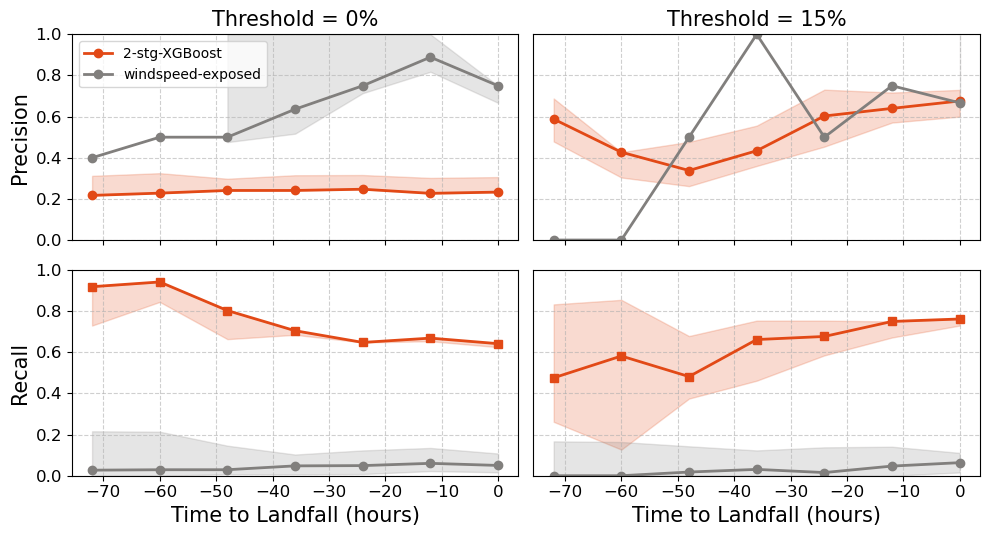

In [29]:
import matplotlib.pyplot as plt
import numpy as np

def plot_precision_recall_ensemble(metrics_df, thresholds=[0, 15]):
    """
    2x2 plot: top row = precision, bottom row = recall
    CI defined as min/max across [mean, mean-std, mean+std]
    """
    metrics_df = metrics_df.copy()
    time_to_landfall = -metrics_df["delta_time"]

    fig, ax = plt.subplots(2, 2, figsize=(10, 6), sharex=True, sharey=False)

    for i, thr in enumerate(thresholds):
        # Column names for 2-stg-xgb model
        prec_mean = f"precision_thr_{thr}_predicted_mean"
        prec_lo = f"precision_thr_{thr}_predicted_minus_std"
        prec_hi = f"precision_thr_{thr}_predicted_plus_std"

        rec_mean = f"recall_thr_{thr}_predicted_mean"
        rec_lo = f"recall_thr_{thr}_predicted_minus_std"
        rec_hi = f"recall_thr_{thr}_predicted_plus_std"

        # Column names for windspeed-exposed model
        prec_mean_wind = f"precision_thr_{thr}_predicted_wind_mean"
        prec_lo_wind = f"precision_thr_{thr}_predicted_wind_minus_std"
        prec_hi_wind = f"precision_thr_{thr}_predicted_wind_plus_std"

        rec_mean_wind = f"recall_thr_{thr}_predicted_wind_mean"
        rec_lo_wind = f"recall_thr_{thr}_predicted_wind_minus_std"
        rec_hi_wind = f"recall_thr_{thr}_predicted_wind_plus_std"

        # ---------------- PRECISION (top row) ----------------
        ax_prec = ax[0, i]
        # 2stg xgb model
        mean_val = metrics_df[prec_mean]
        lower = np.minimum.reduce([metrics_df[prec_lo], metrics_df[prec_hi], mean_val])
        upper = np.maximum.reduce([metrics_df[prec_lo], metrics_df[prec_hi], mean_val])
        ax_prec.plot(time_to_landfall, mean_val, color="#E24916", marker="o", lw=2, label="2-stg-XGBoost")
        ax_prec.fill_between(time_to_landfall, lower, upper, color="#E24916", alpha=0.2)
        # windspeed-exposed model
        mean_val = metrics_df[prec_mean_wind]
        lower = np.minimum.reduce([metrics_df[prec_lo_wind], metrics_df[prec_hi_wind], mean_val])
        upper = np.maximum.reduce([metrics_df[prec_lo_wind], metrics_df[prec_hi_wind], mean_val])
        ax_prec.plot(time_to_landfall, mean_val, color="#817F7D", marker="o", lw=2, label="windspeed-exposed")
        ax_prec.fill_between(time_to_landfall, lower, upper, color="#817F7D", alpha=0.2)

        ax_prec.set_title(f"Threshold = {thr}%", fontsize=15)
        ax_prec.set_ylim(0, 1)
        ax_prec.grid(True, linestyle='--', alpha=0.6)
        ax_prec.tick_params(labelsize=12)
        if i == 1:
            ax_prec.tick_params(left=False, labelleft=False)

        # ---------------- RECALL (bottom row) ----------------
        ax_rec = ax[1, i]
        # 2-stg-xgb model
        mean_val = metrics_df[rec_mean]
        lower = np.minimum.reduce([metrics_df[rec_lo], metrics_df[rec_hi], mean_val])
        upper = np.maximum.reduce([metrics_df[rec_lo], metrics_df[rec_hi], mean_val])
        ax_rec.plot(time_to_landfall, mean_val, color="#E24916", marker="s", linestyle="-", lw=2, label="")
        ax_rec.fill_between(time_to_landfall, lower, upper, color="#E24916", alpha=0.2)
        # windspeed-exposed model
        mean_val = metrics_df[rec_mean_wind]
        lower = np.minimum.reduce([metrics_df[rec_lo_wind], metrics_df[rec_hi_wind], mean_val])
        upper = np.maximum.reduce([metrics_df[rec_lo_wind], metrics_df[rec_hi_wind], mean_val])
        ax_rec.plot(time_to_landfall, mean_val, color="#817F7D", marker="o", lw=2, label="windspeed-exposed")
        ax_rec.fill_between(time_to_landfall, lower, upper, color="#817F7D", alpha=0.2)
        ax_rec.set_ylim(0, 1)
        ax_rec.grid(True, linestyle='--', alpha=0.6)
        ax_rec.tick_params(labelsize=12)
        if i == 1:
            ax_rec.tick_params(left=False, labelleft=False)

    # Shared X-axis
    for a in ax[1, :]:
        a.set_xlabel("Time to Landfall (hours)", fontsize=15)

    # Shared Y-axis labels
    ax[0, 0].set_ylabel("Precision", fontsize=15)
    ax[1, 0].set_ylabel("Recall", fontsize=15)

    ax[0, 0].legend()

    plt.tight_layout(rect=[0, 0.05, 1, 0.96])
    plt.show()


plot_precision_recall_ensemble(metrics_df)


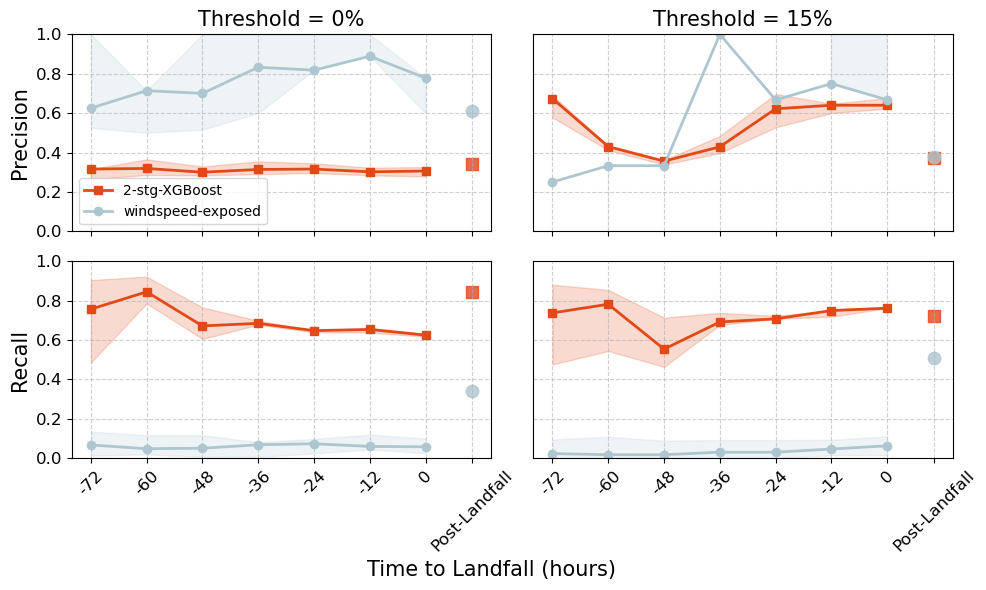

In [12]:
import matplotlib.pyplot as plt
import numpy as np

def compute_metrics_postlandfall(df, thr):
    """Compute precision & recall for a given threshold using reported/predicted."""
    
    if thr == 0:
        y_true = df["reported"] > 0
        y_pred = df["predicted"] > 0

    elif thr == 15:
        y_true = df["reported"] >= 15
        y_pred = df["predicted"] >= 15

    TP = np.sum((y_true) & (y_pred))
    TN = np.sum((~y_true) & (~y_pred))
    FP = np.sum((~y_true) & (y_pred))
    FN = np.sum((y_true) & (~y_pred))
    total = len(df)

    precision = TP / (TP + FP) if (TP + FP) > 0 else 0
    recall    = TP / (TP + FN) if (TP + FN) > 0 else 0

    tp_rate = TP / total if total > 0 else np.nan
    tn_rate = TN / total if total > 0 else np.nan

    return precision, recall, tp_rate, tn_rate


def plot_precision_recall_ensemble_post(
    metrics_df,
    actual_predictions_adm1,
    actual_wind_predictions_adm1,
    thresholds=[0, 15]
):
    """
    Same as your previous function but with:
    - Post-landfall precision/recall added at the end
    - Added as a final point in both models
    """

    metrics_df = metrics_df.copy()
    time_to_landfall = -metrics_df["delta_time"]

    fig, ax = plt.subplots(2, 2, figsize=(10, 6), sharex=True, sharey=False)

    for i, thr in enumerate(thresholds):

        # normal pre-landfall columns
        # prec_mean = f"precision_thr_{thr}_predicted_mean"
        # prec_lo = f"precision_thr_{thr}_predicted_minus_std"
        # prec_hi = f"precision_thr_{thr}_predicted_plus_std"

        # rec_mean = f"recall_thr_{thr}_predicted_mean"
        # rec_lo = f"recall_thr_{thr}_predicted_minus_std"
        # rec_hi = f"recall_thr_{thr}_predicted_plus_std"
        
        prec_mean = f"precision_thr_{thr}_predicted_median"
        prec_lo = f"precision_thr_{thr}_predicted_q25"
        prec_hi = f"precision_thr_{thr}_predicted_q75"

        rec_mean = f"recall_thr_{thr}_predicted_median"
        rec_lo = f"recall_thr_{thr}_predicted_q25"
        rec_hi = f"recall_thr_{thr}_predicted_q75"

        # wind-exposed columns
        # prec_mean_wind = f"precision_thr_{thr}_predicted_wind_mean"
        # prec_lo_wind   = f"precision_thr_{thr}_predicted_wind_minus_std"
        # prec_hi_wind   = f"precision_thr_{thr}_predicted_wind_plus_std"

        # rec_mean_wind = f"recall_thr_{thr}_predicted_wind_mean"
        # rec_lo_wind   = f"recall_thr_{thr}_predicted_wind_minus_std"
        # rec_hi_wind   = f"recall_thr_{thr}_predicted_wind_plus_std"
        prec_mean_wind = f"precision_thr_{thr}_predicted_wind_median"
        prec_lo_wind   = f"precision_thr_{thr}_predicted_wind_q25"
        prec_hi_wind   = f"precision_thr_{thr}_predicted_wind_q75"

        rec_mean_wind = f"recall_thr_{thr}_predicted_wind_median"
        rec_lo_wind   = f"recall_thr_{thr}_predicted_wind_q25"
        rec_hi_wind   = f"recall_thr_{thr}_predicted_wind_q75"

        # ---------------------------------------------------
        # POST-LANDFALL PRECISION/RECALL
        # ---------------------------------------------------
        p_post_xgb, r_post_xgb, tp_post_xgb, tn_post_xgb    = compute_metrics_postlandfall(actual_predictions_adm1, thr)
        p_post_wind, r_post_wind, tp_post_wind, tn_post_wind = compute_metrics_postlandfall(actual_wind_predictions_adm1, thr)

        post_time = time_to_landfall.max() + 10  # 10h after last point

        # ---------------------------------------------------
        # ---------------- PRECISION (top row) --------------
        # ---------------------------------------------------
        ax_prec = ax[0, i]

        # 2-stg-xgb
        mean_val = metrics_df[prec_mean]
        lower = np.minimum.reduce([metrics_df[prec_lo], metrics_df[prec_hi], mean_val])
        upper = np.maximum.reduce([metrics_df[prec_lo], metrics_df[prec_hi], mean_val])

        ax_prec.plot(time_to_landfall, mean_val, color="#E24916", marker="s", lw=2, label="2-stg-XGBoost")
        ax_prec.fill_between(time_to_landfall, lower, upper, color="#E24916", alpha=0.2)
        ax_prec.scatter(post_time, p_post_xgb, color="#E24916", marker="s", s=80, alpha=0.8)

        # windspeed-exposed
        mean_val = metrics_df[prec_mean_wind]
        lower = np.minimum.reduce([metrics_df[prec_lo_wind], metrics_df[prec_hi_wind], mean_val])
        upper = np.maximum.reduce([metrics_df[prec_lo_wind], metrics_df[prec_hi_wind], mean_val])

        ax_prec.plot(time_to_landfall, mean_val, color="#AEC6CF", marker="o", lw=2, label="windspeed-exposed")
        ax_prec.fill_between(time_to_landfall, lower, upper, color="#AEC6CF", alpha=0.2)
        ax_prec.scatter(post_time, p_post_wind, color="#AEC6CF", marker="o", s=80, alpha=0.8)

        ax_prec.set_title(f"Threshold = {thr}%", fontsize=15)
        ax_prec.set_ylim(0, 1)
        ax_prec.grid(True, linestyle="--", alpha=0.6)
        ax_prec.tick_params(labelsize=12)
        if i == 1:
            ax_prec.tick_params(left=False, labelleft=False)

        # ---------------------------------------------------
        # ---------------- RECALL (bottom row) --------------
        # ---------------------------------------------------
        ax_rec = ax[1, i]

        # 2-stg-xgb
        mean_val = metrics_df[rec_mean]
        lower = np.minimum.reduce([metrics_df[rec_lo], metrics_df[rec_hi], mean_val])
        upper = np.maximum.reduce([metrics_df[rec_lo], metrics_df[rec_hi], mean_val])

        ax_rec.plot(time_to_landfall, mean_val, color="#E24916", marker="s", lw=2)
        ax_rec.fill_between(time_to_landfall, lower, upper, color="#E24916", alpha=0.2)
        ax_rec.scatter(post_time, r_post_xgb, color="#E24916", marker="s", s=80, alpha=0.8)

        # windspeed-exposed
        mean_val = metrics_df[rec_mean_wind]
        lower = np.minimum.reduce([metrics_df[rec_lo_wind], metrics_df[rec_hi_wind], mean_val])
        upper = np.maximum.reduce([metrics_df[rec_lo_wind], metrics_df[rec_hi_wind], mean_val])

        ax_rec.plot(time_to_landfall, mean_val, color="#AEC6CF", marker="o", lw=2)
        ax_rec.fill_between(time_to_landfall, lower, upper, color="#AEC6CF", alpha=0.2)
        ax_rec.scatter(post_time, r_post_wind, color="#AEC6CF", marker="o", s=80, alpha=0.8)

        ax_rec.set_ylim(0, 1)
        ax_rec.grid(True, linestyle="--", alpha=0.6)
        ax_rec.tick_params(labelsize=12)
        if i == 1:
            ax_rec.tick_params(left=False, labelleft=False)

        # add post-landfall to x-ticks
        xticks = list(time_to_landfall) + [post_time]
        ax_prec.set_xticks(xticks)
        ax_rec.set_xticks(xticks)

        xticklabels = [str(int(x)) for x in time_to_landfall] + ["Post-Landfall"]
        ax_prec.set_xticklabels(xticklabels, rotation=45)
        ax_rec.set_xticklabels(xticklabels, rotation=45)

    # Labels
    ax[0, 0].set_ylabel("Precision", fontsize=15)
    ax[1, 0].set_ylabel("Recall", fontsize=15)
    ax[1, 0].set_xlabel("Time to Landfall (hours)", fontsize=15, x=1)
    ax[0, 0].legend()

    plt.tight_layout()
    plt.savefig("/home/fmoss/GLOBAL MODEL/local_files/precision_recall_historical_forecasts_median_approach.png", 
            dpi=300,
            bbox_inches='tight',
            pad_inches=0.2)
    plt.show()

plot_precision_recall_ensemble_post(
    metrics_df,
    actual_predictions_adm1,
    actual_data_adm1,
    thresholds=[0, 15])

In [65]:
def compute_metrics_postlandfall(df, thr):
    """Compute precision & recall for a given threshold using reported/predicted."""
    
    if thr == 0:
        y_true = df["reported"] > 0
        y_pred = df["predicted"] > 0

    elif thr == 15:
        y_true = df["reported"] > 15
        y_pred = df["predicted"] > 15

    TP = np.sum((y_true) & (y_pred))
    TN = np.sum((~y_true) & (~y_pred))
    FP = np.sum((~y_true) & (y_pred))
    FN = np.sum((y_true) & (~y_pred))
    total = len(df)

    precision = TP / (TP + FP) if (TP + FP) > 0 else 0
    recall    = TP / (TP + FN) if (TP + FN) > 0 else 0

    tp_rate = TP / total if total > 0 else np.nan
    tn_rate = TN / total if total > 0 else np.nan

    return precision, recall, tp_rate, tn_rate
compute_metrics_postlandfall(actual_data_adm1, 0)[:2]

(0.6091954022988506, 0.3419354838709677)

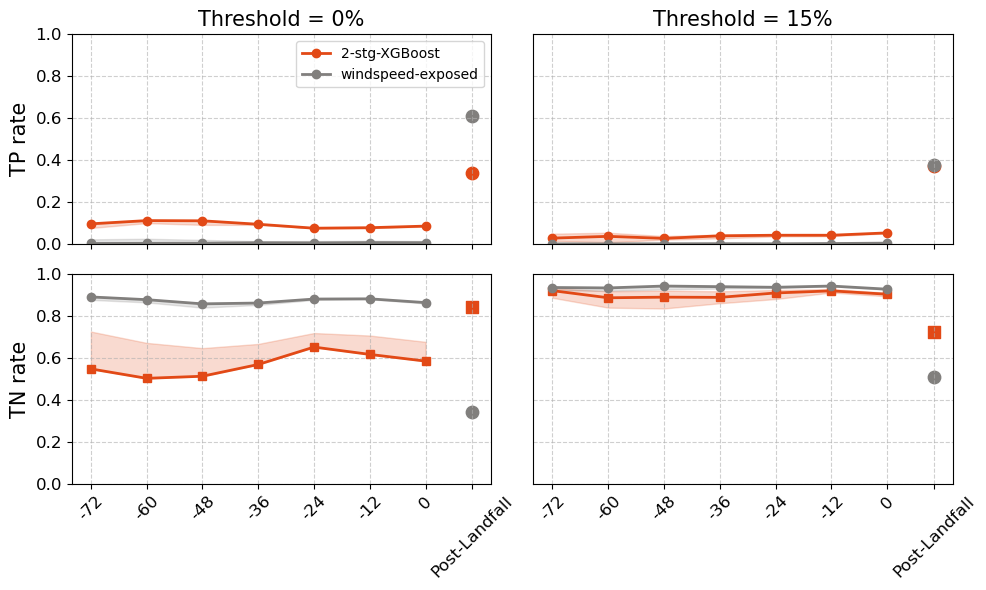

In [55]:
import matplotlib.pyplot as plt
import numpy as np

def compute_metrics_postlandfall(df, thr):
    """Compute precision & recall for a given threshold using reported/predicted."""
    
    if thr == 0:
        y_true = df["reported"] > 0
        y_pred = df["predicted"] > 0

    elif thr == 15:
        y_true = df["reported"] >= 15
        y_pred = df["predicted"] >= 15

    TP = np.sum((y_true) & (y_pred))
    TN = np.sum((~y_true) & (~y_pred))
    FP = np.sum((~y_true) & (y_pred))
    FN = np.sum((y_true) & (~y_pred))
    total = len(df)

    precision = TP / (TP + FP) if (TP + FP) > 0 else 0
    recall    = TP / (TP + FN) if (TP + FN) > 0 else 0

    tp_rate = TP / total if total > 0 else np.nan
    tn_rate = TN / total if total > 0 else np.nan

    return precision, recall, tp_rate, tn_rate


def plot_tp_tn_rates_ensemble_post(
    metrics_df,
    actual_predictions_adm1,
    actual_wind_predictions_adm1,
    thresholds=[0, 15]
):
    """
    Same as your previous function but with:
    - Post-landfall precision/recall added at the end
    - Added as a final point in both models
    """

    metrics_df = metrics_df.copy()
    time_to_landfall = -metrics_df["delta_time"]

    fig, ax = plt.subplots(2, 2, figsize=(10, 6), sharex=True, sharey=False)

    for i, thr in enumerate(thresholds):

        # normal pre-landfall columns
        prec_mean = f"tp_rate_thr_{thr}_predicted_mean"
        prec_lo = f"tp_rate_thr_{thr}_predicted_minus_std"
        prec_hi = f"tp_rate_thr_{thr}_predicted_plus_std"

        rec_mean = f"tn_rate_thr_{thr}_predicted_mean"
        rec_lo = f"tn_rate_thr_{thr}_predicted_minus_std"
        rec_hi = f"tn_rate_thr_{thr}_predicted_plus_std"

        # wind-exposed columns
        prec_mean_wind = f"tp_rate_thr_{thr}_predicted_wind_mean"
        prec_lo_wind   = f"tp_rate_thr_{thr}_predicted_wind_minus_std"
        prec_hi_wind   = f"tp_rate_thr_{thr}_predicted_wind_plus_std"

        rec_mean_wind = f"tn_rate_thr_{thr}_predicted_wind_mean"
        rec_lo_wind   = f"tn_rate_thr_{thr}_predicted_wind_minus_std"
        rec_hi_wind   = f"tn_rate_thr_{thr}_predicted_wind_plus_std"

        # ---------------------------------------------------
        # POST-LANDFALL PRECISION/RECALL
        # ---------------------------------------------------
        p_post_xgb, r_post_xgb, tp_post_xgb, tn_post_xgb    = compute_metrics_postlandfall(actual_predictions_adm1, thr)
        p_post_wind, r_post_wind, tp_post_wind, tn_post_wind = compute_metrics_postlandfall(actual_wind_predictions_adm1, thr)

        post_time = time_to_landfall.max() + 10  # 10h after last point

        # ---------------------------------------------------
        # ---------------- PRECISION (top row) --------------
        # ---------------------------------------------------
        ax_prec = ax[0, i]

        # 2-stg-xgb
        mean_val = metrics_df[prec_mean]
        lower = np.minimum.reduce([metrics_df[prec_lo], metrics_df[prec_hi], mean_val])
        upper = np.maximum.reduce([metrics_df[prec_lo], metrics_df[prec_hi], mean_val])

        ax_prec.plot(time_to_landfall, mean_val, color="#E24916", marker="o", lw=2, label="2-stg-XGBoost")
        ax_prec.fill_between(time_to_landfall, lower, upper, color="#E24916", alpha=0.2)
        ax_prec.scatter(post_time, p_post_xgb, color="#E24916", marker="o", s=80)

        # windspeed-exposed
        mean_val = metrics_df[prec_mean_wind]
        lower = np.minimum.reduce([metrics_df[prec_lo_wind], metrics_df[prec_hi_wind], mean_val])
        upper = np.maximum.reduce([metrics_df[prec_lo_wind], metrics_df[prec_hi_wind], mean_val])

        ax_prec.plot(time_to_landfall, mean_val, color="#817F7D", marker="o", lw=2, label="windspeed-exposed")
        ax_prec.fill_between(time_to_landfall, lower, upper, color="#817F7D", alpha=0.2)
        ax_prec.scatter(post_time, p_post_wind, color="#817F7D", marker="o", s=80)

        ax_prec.set_title(f"Threshold = {thr}%", fontsize=15)
        ax_prec.set_ylim(0, 1)
        ax_prec.grid(True, linestyle="--", alpha=0.6)
        ax_prec.tick_params(labelsize=12)
        if i == 1:
            ax_prec.tick_params(left=False, labelleft=False)

        # ---------------------------------------------------
        # ---------------- RECALL (bottom row) --------------
        # ---------------------------------------------------
        ax_rec = ax[1, i]

        # 2-stg-xgb
        mean_val = metrics_df[rec_mean]
        lower = np.minimum.reduce([metrics_df[rec_lo], metrics_df[rec_hi], mean_val])
        upper = np.maximum.reduce([metrics_df[rec_lo], metrics_df[rec_hi], mean_val])

        ax_rec.plot(time_to_landfall, mean_val, color="#E24916", marker="s", lw=2)
        ax_rec.fill_between(time_to_landfall, lower, upper, color="#E24916", alpha=0.2)
        ax_rec.scatter(post_time, r_post_xgb, color="#E24916", marker="s", s=80)

        # windspeed-exposed
        mean_val = metrics_df[rec_mean_wind]
        lower = np.minimum.reduce([metrics_df[rec_lo_wind], metrics_df[rec_hi_wind], mean_val])
        upper = np.maximum.reduce([metrics_df[rec_lo_wind], metrics_df[rec_hi_wind], mean_val])

        ax_rec.plot(time_to_landfall, mean_val, color="#817F7D", marker="o", lw=2)
        ax_rec.fill_between(time_to_landfall, lower, upper, color="#817F7D", alpha=0.2)
        ax_rec.scatter(post_time, r_post_wind, color="#817F7D", marker="o", s=80)

        ax_rec.set_ylim(0, 1)
        ax_rec.grid(True, linestyle="--", alpha=0.6)
        ax_rec.tick_params(labelsize=12)
        if i == 1:
            ax_rec.tick_params(left=False, labelleft=False)

        # add post-landfall to x-ticks
        xticks = list(time_to_landfall) + [post_time]
        ax_prec.set_xticks(xticks)
        ax_rec.set_xticks(xticks)

        xticklabels = [str(int(x)) for x in time_to_landfall] + ["Post-Landfall"]
        ax_prec.set_xticklabels(xticklabels, rotation=45)
        ax_rec.set_xticklabels(xticklabels, rotation=45)

    # Labels
    ax[0, 0].set_ylabel("TP rate", fontsize=15)
    ax[1, 0].set_ylabel("TN rate", fontsize=15)
    ax[0, 0].legend()

    plt.tight_layout()
    plt.show()

plot_tp_tn_rates_ensemble_post(
    metrics_df,
    actual_predictions_adm1,
    actual_data_adm1,
    thresholds=[0, 15])

In [15]:
import matplotlib.pyplot as plt
import numpy as np

def plot_precision_recall_ensemble_single(metrics_df,
                                          threshold=0,
                                          title_prefix="Past Forecasts",
                                          model_name="2-stg-XGBoost",
                                          n_events=None):
    """
    Plot separate Precision and Recall vs time-to-landfall for ensemble forecasts,
    including worst-case and wind-based models.
    """
    metrics_df = metrics_df.copy()
    time_to_landfall = -metrics_df["delta_time"]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True, sharey=True)
    titles = ["Precision", "Recall"]

    # Precision and Recall columns
    prec_mean = f"precision_thr_{threshold}_predicted_mean"
    prec_lo = f"precision_thr_{threshold}_predicted_minus_std"
    prec_hi = f"precision_thr_{threshold}_predicted_plus_std"
    prec_max = f"precision_thr_{threshold}_predicted_max"
    prec_wind_mean = f"precision_thr_{threshold}_predicted_wind_mean"
    prec_wind_max = f"precision_thr_{threshold}_predicted_wind_max"

    rec_mean = f"recall_thr_{threshold}_predicted_mean"
    rec_lo = f"recall_thr_{threshold}_predicted_minus_std"
    rec_hi = f"recall_thr_{threshold}_predicted_plus_std"
    rec_max = f"recall_thr_{threshold}_predicted_max"
    rec_wind_mean = f"recall_thr_{threshold}_predicted_wind_mean"
    rec_wind_max = f"recall_thr_{threshold}_predicted_wind_max"

    # --- Precision subplot ---
    ax = axes[0]

    # Mean ± std
    if all(col in metrics_df.columns for col in [prec_mean, prec_lo, prec_hi]):
        # ax.plot(time_to_landfall, metrics_df[prec_mean], color="tab:blue", lw=2, label="Mean (2-stg-model)")
        ax.fill_between(time_to_landfall, metrics_df[prec_lo], metrics_df[prec_hi],
                        color="tab:blue", alpha=0.2, label="Mean ± std (2-stg-model)")

    # Worst-case
    if prec_max in metrics_df.columns:
        ax.plot(time_to_landfall, metrics_df[prec_max], linestyle=':', color="tab:red", lw=2, label="Worst-case (2-stg-model)")

    # Wind models
    if prec_wind_mean in metrics_df.columns:
        ax.plot(time_to_landfall, metrics_df[prec_wind_mean], color="tab:green", lw=2, label="Wind (mean)")
    if prec_wind_max in metrics_df.columns:
        ax.plot(time_to_landfall, metrics_df[prec_wind_max], color="darkgreen", lw=2, linestyle='--', label="Wind (max)")

    ax.set_title("Precision", fontsize=15)
    ax.set_ylim(0, 1)
    ax.grid(True, linestyle="--", alpha=0.6)
    ax.tick_params(axis='both', labelsize=12)
    ax.legend(fontsize=11, loc="lower right")

    # --- Recall subplot ---
    ax = axes[1]

    # Mean ± std
    if all(col in metrics_df.columns for col in [rec_mean, rec_lo, rec_hi]):
        ax.plot(time_to_landfall, metrics_df[rec_mean], color="tab:orange", lw=2, label="Mean (2-stg-model)")
        ax.fill_between(time_to_landfall, metrics_df[rec_lo], metrics_df[rec_hi],
                        color="tab:orange", alpha=0.2, label="± std (2-stg-model)")

    # Worst-case
    if rec_max in metrics_df.columns:
        ax.plot(time_to_landfall, metrics_df[rec_max], linestyle=':', color="tab:red", lw=2, label="Worst-case (2-stg-model)")

    # Wind models
    if rec_wind_mean in metrics_df.columns:
        ax.plot(time_to_landfall, metrics_df[rec_wind_mean], color="tab:green", lw=2, label="Wind (mean) ")
    if rec_wind_max in metrics_df.columns:
        ax.plot(time_to_landfall, metrics_df[rec_wind_max], color="darkgreen", lw=2, linestyle='--', label="Wind (max)")

    ax.set_title("Recall", fontsize=15)
    ax.set_ylim(0, 1)
    ax.grid(True, linestyle="--", alpha=0.6)
    ax.tick_params(axis='both', labelsize=12)
    ax.legend(fontsize=11, loc="lower right")

    # Shared labels and title
    fig.text(0.5, 0.04, 'Time to Landfall (hours)', ha='center', fontsize=15)
    fig.text(0.04, 0.5, 'Metric Value', va='center', rotation='vertical', fontsize=15)
    plt.tight_layout(rect=[0.05, 0.05, 1, 1])
    title_text = f"{title_prefix}"
    plt.suptitle(title_text, size=16, y=1.08)
    plt.show()


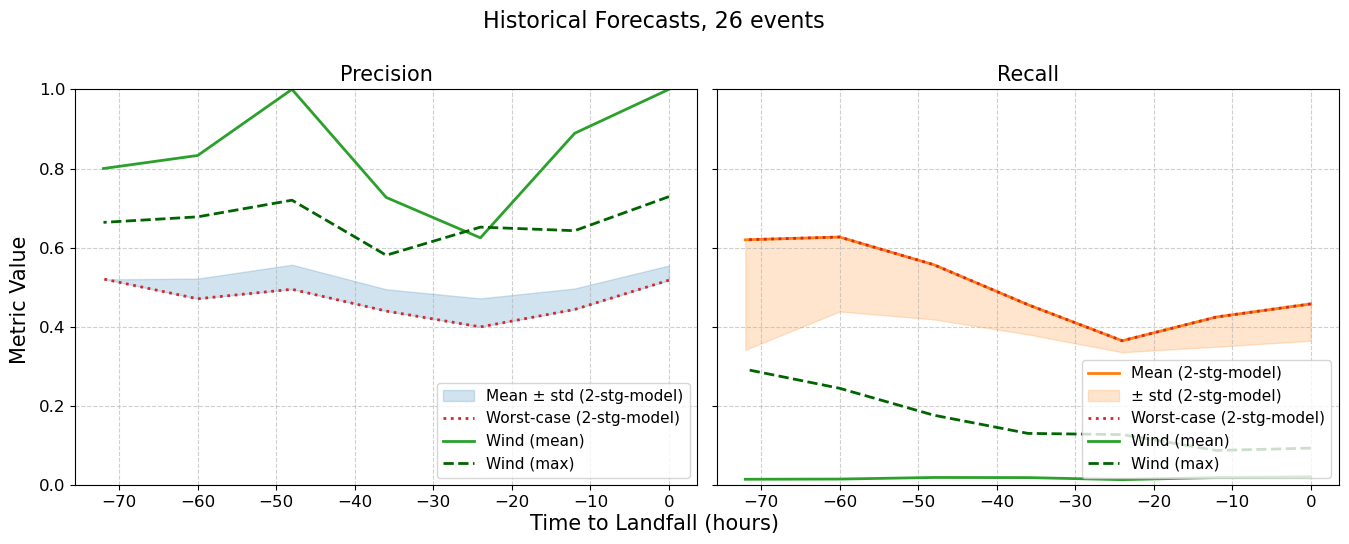

In [26]:
plot_precision_recall_ensemble_single(
    metrics_dt,
    threshold=0,
    title_prefix="Historical Forecasts, 26 events",
    model_name="",
    n_events=len(adm1_grouped["DisNo."].unique())
)


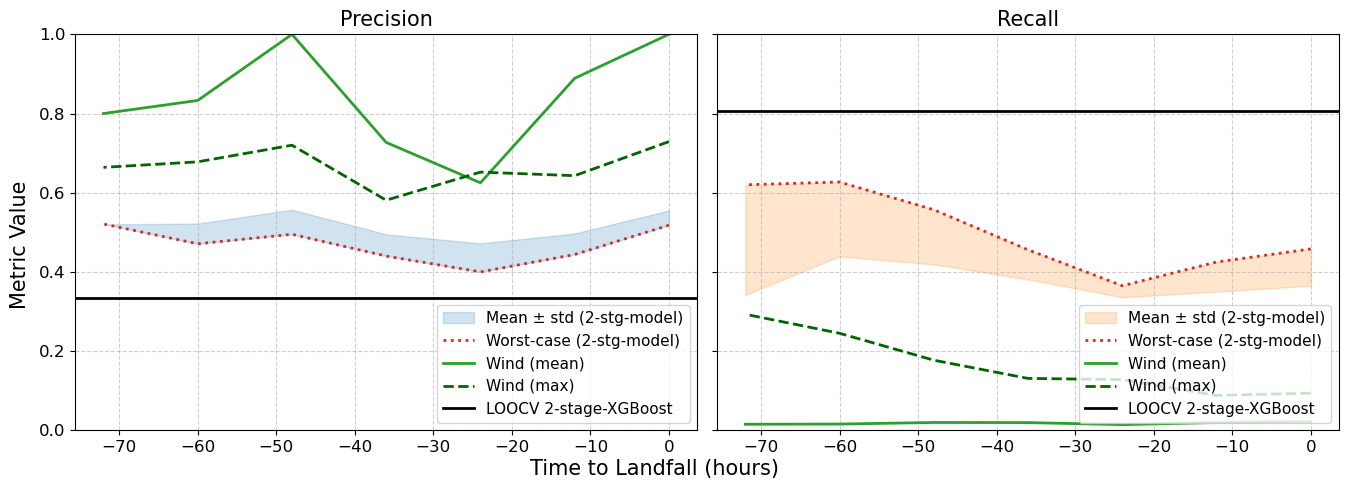

In [46]:

from sklearn.metrics import precision_score, recall_score
def compute_precision_recall_real(actual_predictions_adm1, threshold=0):
    """
    Compute precision and recall for the 'real' (final) prediction model.
    Binarizes the predicted and reported columns based on the threshold.
    """
    df = actual_predictions_adm1.copy()

    # Binarize
    df["reported_bin"] = (df["reported"] > threshold).astype(int)
    df["predicted_bin"] = (df["predicted"] > threshold).astype(int)

    # Compute metrics
    precision = precision_score(df["reported_bin"], df["predicted_bin"], zero_division=0)
    recall = recall_score(df["reported_bin"], df["predicted_bin"], zero_division=0)

    return precision, recall

import matplotlib.pyplot as plt
import numpy as np

def plot_precision_recall_ensemble_single(metrics_df,
                                          threshold=0,
                                          title_prefix="Past Forecasts",
                                          model_name="2-stg-XGBoost",
                                          n_events=None,
                                          precision_real=None,
                                          recall_real=None):
    """
    Plot Precision and Recall vs time-to-landfall for ensemble forecasts,
    including real full-track model comparison.
    """
    metrics_df = metrics_df.copy()
    time_to_landfall = -metrics_df["delta_time"]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True, sharey=True)
    titles = ["Precision", "Recall"]

    # Define column names
    prec_mean = f"precision_thr_{threshold}_predicted_mean"
    prec_lo = f"precision_thr_{threshold}_predicted_minus_std"
    prec_hi = f"precision_thr_{threshold}_predicted_plus_std"
    prec_max = f"precision_thr_{threshold}_predicted_max"
    prec_wind_mean = f"precision_thr_{threshold}_predicted_wind_mean"
    prec_wind_max = f"precision_thr_{threshold}_predicted_wind_max"

    rec_mean = f"recall_thr_{threshold}_predicted_mean"
    rec_lo = f"recall_thr_{threshold}_predicted_minus_std"
    rec_hi = f"recall_thr_{threshold}_predicted_plus_std"
    rec_max = f"recall_thr_{threshold}_predicted_max"
    rec_wind_mean = f"recall_thr_{threshold}_predicted_wind_mean"
    rec_wind_max = f"recall_thr_{threshold}_predicted_wind_max"

    # --- Precision subplot ---
    ax = axes[0]

    if all(col in metrics_df.columns for col in [prec_mean, prec_lo, prec_hi]):
        ax.fill_between(time_to_landfall, metrics_df[prec_lo], metrics_df[prec_hi],
                        color="tab:blue", alpha=0.2, label="Mean ± std (2-stg-model)")

    if prec_max in metrics_df.columns:
        ax.plot(time_to_landfall, metrics_df[prec_max], linestyle=':', color="tab:red", lw=2, label="Worst-case (2-stg-model)")

    if prec_wind_mean in metrics_df.columns:
        ax.plot(time_to_landfall, metrics_df[prec_wind_mean], color="tab:green", lw=2, label="Wind (mean)")
    if prec_wind_max in metrics_df.columns:
        ax.plot(time_to_landfall, metrics_df[prec_wind_max], color="darkgreen", lw=2, linestyle='--', label="Wind (max)")

    # Add real model line
    if precision_real is not None:
        ax.axhline(precision_real, color="black", linestyle="-", lw=2, label="LOOCV 2-stage-XGBoost")

    ax.set_title("Precision", fontsize=15)
    ax.set_ylim(0, 1)
    ax.grid(True, linestyle="--", alpha=0.6)
    ax.tick_params(axis='both', labelsize=12)
    ax.legend(fontsize=11, loc="lower right")

    # --- Recall subplot ---
    ax = axes[1]

    if all(col in metrics_df.columns for col in [rec_mean, rec_lo, rec_hi]):
        # ax.plot(time_to_landfall, metrics_df[rec_mean], color="tab:orange", lw=2, label="Mean (2-stg-model)")
        ax.fill_between(time_to_landfall, metrics_df[rec_lo], metrics_df[rec_hi],
                        color="tab:orange", alpha=0.2, label="Mean ± std (2-stg-model)")

    if rec_max in metrics_df.columns:
        ax.plot(time_to_landfall, metrics_df[rec_max], linestyle=':', color="tab:red", lw=2, label="Worst-case (2-stg-model)")

    if rec_wind_mean in metrics_df.columns:
        ax.plot(time_to_landfall, metrics_df[rec_wind_mean], color="tab:green", lw=2, label="Wind (mean)")
    if rec_wind_max in metrics_df.columns:
        ax.plot(time_to_landfall, metrics_df[rec_wind_max], color="darkgreen", lw=2, linestyle='--', label="Wind (max)")

    # Add real model line
    if recall_real is not None:
        ax.axhline(recall_real, color="black", linestyle="-", lw=2, label="LOOCV 2-stage-XGBoost")

    ax.set_title("Recall", fontsize=15)
    ax.set_ylim(0, 1)
    ax.grid(True, linestyle="--", alpha=0.6)
    ax.tick_params(axis='both', labelsize=12)
    ax.legend(fontsize=11, loc="lower right")

    # Shared labels and title
    fig.text(0.5, 0.04, 'Time to Landfall (hours)', ha='center', fontsize=15)
    fig.text(0.04, 0.5, 'Metric Value', va='center', rotation='vertical', fontsize=15)
    plt.tight_layout(rect=[0.05, 0.05, 1, 1])
    plt.suptitle(f"{title_prefix}", size=16, y=1.08)

    plt.savefig("/home/fmoss/GLOBAL MODEL/local_files/historical_forecasts_binary.png", 
            dpi=300, 
            bbox_inches='tight',   # ensures labels and titles aren't cut off
            pad_inches=0.3         # increases margin padding around the plot (default is 0.1)
            )
    
    plt.show()


precision_real, recall_real = compute_precision_recall_real(actual_predictions_adm1)

plot_precision_recall_ensemble_single(
    metrics_df,
    threshold=0,
    title_prefix="",
    precision_real=precision_real,
    recall_real=recall_real
)


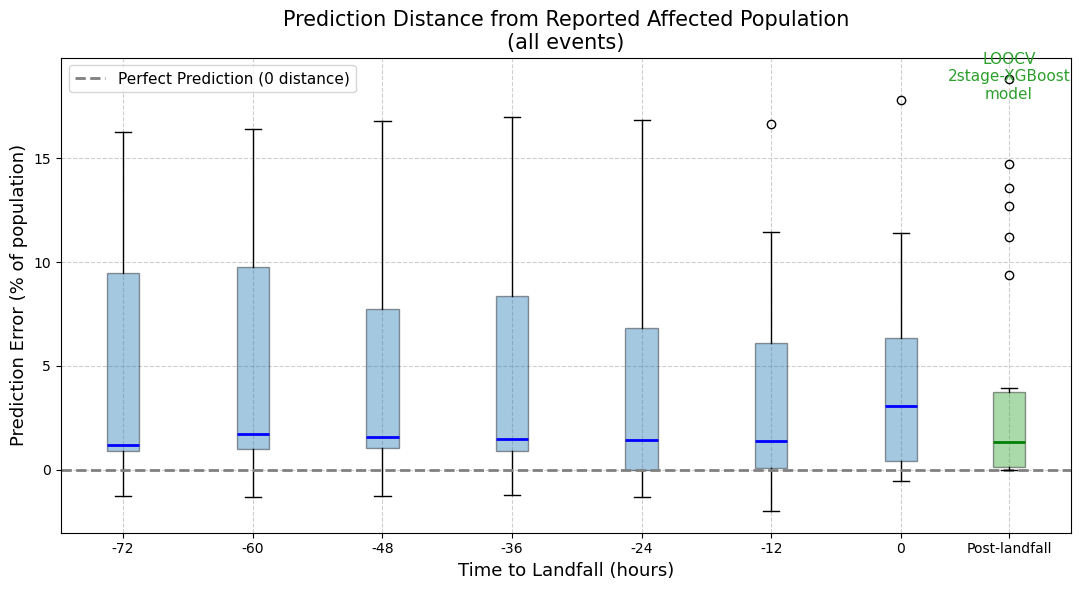

In [33]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

def plot_error_boxplots_by_leadtime_with_real(adm1_grouped, actual_predictions_adm1):
    """
    Plot boxplots of normalized distance (predicted - reported) vs time-to-landfall,
    and add on the right a distribution of country-level (GID_0) normalized errors
    from the 'real' (full-track) predictions dataset.
    """

    # ---- Step 1: Compute population-weighted totals per event/time ----
    adm1_grouped["predicted_mean_total"] = adm1_grouped["predicted_mean"] * adm1_grouped["population"] / 100
    adm1_grouped["predicted_plus_std_total"] = adm1_grouped["predicted_plus_std"] * adm1_grouped["population"] / 100
    adm1_grouped["predicted_minus_std_total"] = adm1_grouped["predicted_minus_std"] * adm1_grouped["population"] / 100

    # ---- Step 2: Aggregate by event (DisNo.) and delta_time ----
    grouped = (
        adm1_grouped.groupby(["DisNo.", "delta_time"])
        .agg(
            predicted_mean_total=("predicted_mean_total", "sum"),
            predicted_plus_std_total=("predicted_plus_std_total", "sum"),
            predicted_minus_std_total=("predicted_minus_std_total", "sum"),
            actual_total=("actual_total", "sum"),
            total_population=("population", "sum")
        )
        .reset_index()
    )

    # ---- Step 3: Normalize by population ----
    grouped["pred_mean_pct"] = grouped["predicted_mean_total"] / grouped["total_population"] * 100
    grouped["ci_lower_pct"] = grouped["predicted_minus_std_total"] / grouped["total_population"] * 100
    grouped["ci_upper_pct"] = grouped["predicted_plus_std_total"] / grouped["total_population"] * 100
    grouped["reported_pct"] = grouped["actual_total"] / grouped["total_population"] * 100

    # ---- Step 4: Compute distances (predicted - reported) ----
    grouped["dist_mean"] = grouped["pred_mean_pct"] - grouped["reported_pct"]

    # ---- Step 5: Prepare data for boxplots ----
    lead_times = sorted(grouped["delta_time"].unique())
    time_to_landfall = [-t for t in lead_times]  # invert so 0 = landfall
    dist_mean_by_time = [grouped.loc[grouped["delta_time"] == t, "dist_mean"].values for t in lead_times]

    # ---- Step 6: Compute final real prediction distribution ----
    df_real = actual_predictions_adm1.copy()

    # Aggregate by event
    df_real_grouped = (
        df_real.groupby("DisNo.").agg({
            "actual_ppl":"sum",
            "prediction_ppl": "sum",
            "population":"sum"
        })
    ).reset_index()

    df_real_grouped["error_pct"] = 100* np.abs(df_real_grouped["actual_ppl"] - df_real_grouped["prediction_ppl"]) / df_real_grouped["population"]

    # ---- Step 7: Plot ----
    plt.figure(figsize=(11, 6))
    bp_mean = plt.boxplot(
        dist_mean_by_time,
        positions=time_to_landfall,
        widths=3,
        patch_artist=True,
        boxprops=dict(facecolor='tab:blue', alpha=0.4),
        medianprops=dict(color='blue', lw=2),
        labels=[str(int(x)) for x in time_to_landfall]
    )

    # Add reference line
    plt.axhline(0, color="gray", lw=2, linestyle="--", label="Perfect Prediction (0 distance)")

    # ---- Step 8: Add real-model distribution ----
    violin_position = max(time_to_landfall) + 10  # offset to the right
    plt.boxplot(
        df_real_grouped["error_pct"],
        positions=[violin_position],
        widths=3,
        patch_artist=True,
        boxprops=dict(facecolor='tab:green', alpha=0.4),
        medianprops=dict(color='green', lw=2),
    )
    plt.text(violin_position, plt.ylim()[1]*0.9, "LOOCV\n2stage-XGBoost\nmodel", ha="center", fontsize=11, color="tab:green")

    # ---- Step 9: X-axis tick customization ----
    all_positions = time_to_landfall + [violin_position]
    all_labels = [str(int(x)) for x in time_to_landfall] + ["Post-landfall"]
    plt.xticks(all_positions, all_labels)

    # ---- Step 10: Styling ----
    plt.xlabel("Time to Landfall (hours)", fontsize=13)
    plt.ylabel("Prediction Error (% of population)", fontsize=13)
    plt.title("Prediction Distance from Reported Affected Population\n(all events)", fontsize=15)
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.legend(loc="upper left", fontsize=11)
    plt.tight_layout()
    plt.show()

plot_error_boxplots_by_leadtime_with_real(adm1_grouped, actual_predictions_adm1)


In [11]:
adm1_grouped.columns

Index(['DisNo.', 'GID_0', 'GID_1', 'sid_x', 'delta_time',
       'predicted_mean_total', 'predicted_plus_std_total',
       'predicted_minus_std_total', 'predicted_max_total',
       'predicted_wind_mean_total', 'predicted_wind_max_total', 'actual_total',
       'population', 'predicted_mean', 'predicted_plus_std',
       'predicted_minus_std', 'predicted_max', 'predicted_wind_mean',
       'predicted_wind_max', 'error_mean', 'abs_error_mean', 'error_max',
       'abs_error_max', 'error_wind_mean', 'abs_error_wind_mean',
       'error_wind_max', 'abs_error_wind_max'],
      dtype='object')

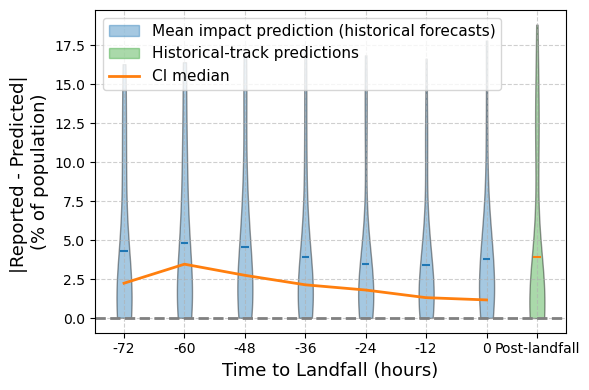

In [13]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd

def plot_error_violinplots_by_leadtime_with_real(adm1_grouped, actual_predictions_adm1, plot="mean"):
    """
    Plot violin plots of normalized distance (predicted - reported) vs time-to-landfall,
    overlaying the median of the confidence interval width, and add on the right a distribution 
    of country-level (GID_0) normalized errors from the 'real' (full-track) predictions dataset.
    """

    # ---- Step 1: Compute population-weighted totals per event/time ----
    adm1_grouped["predicted_mean_total"] = adm1_grouped["predicted_mean"] * adm1_grouped["population"] / 100
    adm1_grouped["predicted_plus_std_total"] = adm1_grouped["predicted_plus_std"] * adm1_grouped["population"] / 100
    adm1_grouped["predicted_minus_std_total"] = adm1_grouped["predicted_minus_std"] * adm1_grouped["population"] / 100
    adm1_grouped["predicted_max_total"] = adm1_grouped["predicted_max"] * adm1_grouped["population"] / 100

    # ---- Step 2: Aggregate by event (DisNo.) and delta_time ----
    grouped = (
        adm1_grouped.groupby(["DisNo.", "delta_time"])
        .agg(
            predicted_mean_total=("predicted_mean_total", "sum"),
            predicted_max_total=("predicted_max_total", "sum"),
            predicted_plus_std_total=("predicted_plus_std_total", "sum"),
            predicted_minus_std_total=("predicted_minus_std_total", "sum"),
            # actual_total=("actual_total", "sum"),
            actual_total=("actual_ppl_affected", "sum"),
            total_population=("population", "sum")
        )
        .reset_index()
    )

    # ---- Step 3: Normalize by population ----
    grouped["pred_mean_pct"] = grouped["predicted_mean_total"] / grouped["total_population"] * 100
    grouped["pred_max_pct"] = grouped["predicted_max_total"] / grouped["total_population"] * 100
    grouped["ci_lower_pct"] = grouped["predicted_minus_std_total"] / grouped["total_population"] * 100
    grouped["ci_upper_pct"] = grouped["predicted_plus_std_total"] / grouped["total_population"] * 100
    grouped["reported_pct"] = grouped["actual_total"] / grouped["total_population"] * 100

    # ---- Step 4: Compute distances (predicted - reported) and CI width ----
    grouped["dist_mean"] = np.abs(grouped["pred_mean_pct"] - grouped["reported_pct"])
    grouped["dist_max"] = np.abs(grouped["pred_max_pct"] - grouped["reported_pct"])
    grouped["ci_width"] = grouped["ci_upper_pct"] - grouped["ci_lower_pct"]

    # ---- Step 5: Prepare data for violins ----
    lead_times = sorted(grouped["delta_time"].unique())
    time_to_landfall = [-t for t in lead_times]  # invert so 0 = landfall
    dist_mean_by_time = [grouped.loc[grouped["delta_time"] == t, "dist_mean"].values for t in lead_times]
    dist_max_by_time = [grouped.loc[grouped["delta_time"] == t, "dist_max"].values for t in lead_times]
    ci_median_by_time = [np.median(grouped.loc[grouped["delta_time"] == t, "ci_width"].values) for t in lead_times]

    # ---- Step 6: Compute final real prediction distribution ----
    df_real = actual_predictions_adm1.copy()
    df_real_grouped = (
        df_real.groupby("DisNo.").agg({
            "actual_ppl": "sum",
            "prediction_ppl": "sum",
            "population": "sum"
        })
    ).reset_index()
    df_real_grouped["error_pct"] = 100 * np.abs(
        df_real_grouped["actual_ppl"] - df_real_grouped["prediction_ppl"]
    ) / df_real_grouped["population"]

    # ---- Step 7: Plot violins ----
    plt.figure(figsize=(6, 4))

    if plot=="mean":
        vp_main = plt.violinplot(
            dist_mean_by_time,
            positions=time_to_landfall,
            widths=3,
            showmeans=True,
            showextrema=False
        )
    elif plot=="max":
        vp_main = plt.violinplot(
            dist_max_by_time,
            positions=time_to_landfall,
            widths=3,
            showmeans=True,
            showextrema=False
        )

    # Customize main violins
    for body in vp_main['bodies']:
        body.set_facecolor('tab:blue')
        body.set_edgecolor('black')
        body.set_alpha(0.4)

    # Proxy for main violins
    main_violin_patch = mpatches.Patch(
        color='tab:blue', alpha=0.4,
        label=f"{plot.capitalize()} impact prediction (historical forecasts)"
    )

    # Reference line
    plt.axhline(0, color="gray", lw=2, linestyle="--", label="Perfect Prediction (0 distance)")

    # ---- Step 8: Overlay CI median ----
    ci_line, = plt.plot(time_to_landfall, ci_median_by_time, color='tab:orange', lw=2, linestyle='-', label="CI median")


    # ---- Step 9: Real-model violin ----
    violin_position = max(time_to_landfall) + 10
    vp_real = plt.violinplot(
        [df_real_grouped["error_pct"].values],
        positions=[violin_position],
        widths=3,
        showmeans=True,
        showextrema=False
    )
    for body in vp_real['bodies']:
        body.set_facecolor('tab:green')
        body.set_edgecolor('black')
        body.set_alpha(0.4)
    real_violin_patch = mpatches.Patch(color='tab:green', alpha=0.4, label="Historical-track predictions")

    # plt.text(violin_position, plt.ylim()[1]*0.95, "LOOCV\n2stage-XGBoost",
    #          ha="center", fontsize=11, color="tab:green")

    # ---- Step 10: X-axis and styling ----
    all_positions = time_to_landfall + [violin_position]
    all_labels = [str(int(x)) for x in time_to_landfall] + ["Post-landfall"]
    plt.xticks(all_positions, all_labels)
    plt.xlabel("Time to Landfall (hours)", fontsize=13)
    plt.ylabel("|Reported - Predicted| \n(% of population)", fontsize=13)
    plt.grid(True, linestyle="--", alpha=0.6)

    # ---- Step 11: Legend ----
    plt.legend(handles=[main_violin_patch, real_violin_patch, ci_line], loc="upper left", fontsize=11)


    plt.tight_layout()
    # plt.savefig(f"/home/fmoss/GLOBAL MODEL/local_files/historical_forecasts_distribution_{plot}.png",
    #             dpi=300,
    #             bbox_inches='tight',
    #             pad_inches=0.3)
    plt.show()

plot_error_violinplots_by_leadtime_with_real(adm1_grouped, actual_predictions_adm1, plot="mean")

In [20]:
# ---- Step 2: Aggregate by event (DisNo.) and delta_time ----
grouped = (
    adm1_grouped.groupby(["DisNo.", "delta_time"])
    .agg(
        predicted_mean_total=("predicted_mean_total", "sum"),
        predicted_max_total=("predicted_max_total", "sum"),
        predicted_plus_std_total=("predicted_plus_std_total", "sum"),
        predicted_minus_std_total=("predicted_minus_std_total", "sum"),
        actual_total=("actual_total", "sum"),
        total_population=("population", "sum")
    )
    .reset_index()
)
# ---- Step 3: Normalize by population ----
grouped["pred_mean_pct"] = grouped["predicted_mean_total"] / grouped["total_population"] * 100
grouped["pred_max_pct"] = grouped["predicted_max_total"] / grouped["total_population"] * 100
grouped["ci_lower_pct"] = grouped["predicted_minus_std_total"] / grouped["total_population"] * 100
grouped["ci_upper_pct"] = grouped["predicted_plus_std_total"] / grouped["total_population"] * 100
grouped["reported_pct"] = grouped["actual_total"] / grouped["total_population"] * 100

# ---- Step 4: Compute distances (predicted - reported) and CI width ----
grouped["dist_mean"] = np.abs(grouped["pred_mean_pct"] - grouped["reported_pct"]) 
grouped["dist_max"] = np.abs(grouped["pred_max_pct"] - grouped["reported_pct"])
grouped["ci_width"] = grouped["ci_upper_pct"] - grouped["ci_lower_pct"]
grouped[["DisNo.", "delta_time", "pred_mean_pct", "pred_max_pct", "reported_pct", "dist_mean", "dist_max"]]

,DisNo.,delta_time,pred_mean_pct,pred_max_pct,reported_pct,dist_mean,dist_max
0,2012-0282-CHN,12.0,1.612644,3.592643,0.003925,1.608719,3.588718
1,2012-0282-CHN,24.0,1.458730,3.696437,0.003925,1.454805,3.692512
2,2012-0282-CHN,36.0,1.061445,2.908174,0.003925,1.057520,2.904249
3,2012-0282-CHN,48.0,1.195037,3.869749,0.003925,1.191112,3.865824
4,2012-0294-CHN,0.0,0.435786,0.658409,0.002413,0.433373,0.655996
...,...,...,...,...,...,...,...
132,2020-0470-VNM,24.0,1.170597,1.564656,2.478465,1.307868,0.913808
133,2020-0470-VNM,36.0,1.273511,1.743831,2.478465,1.204954,0.734634
134,2020-0470-VNM,48.0,1.240170,1.912179,2.478465,1.238294,0.566285
135,2020-0470-VNM,60.0,1.165386,1.620468,2.478465,1.313079,0.857996


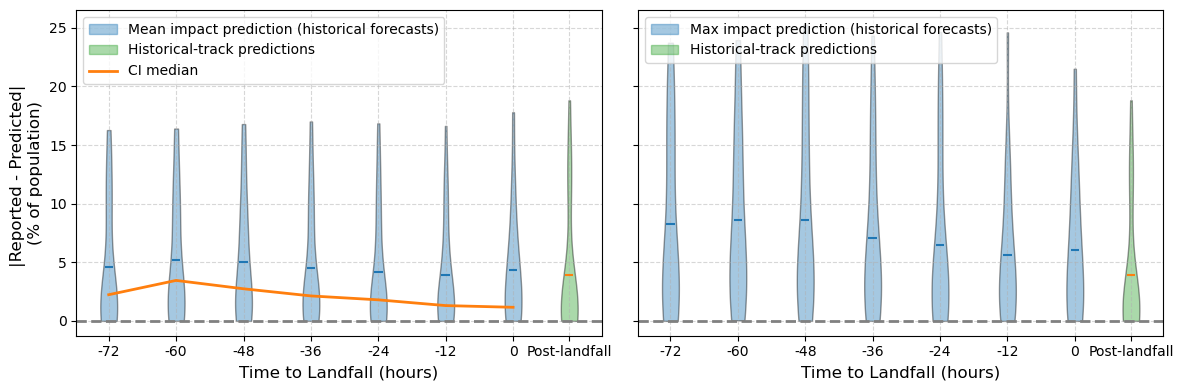

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd

def plot_mean_max_violin_comparison(adm1_grouped, actual_predictions_adm1):
    """
    Plot violin plots of normalized distance (predicted - reported) vs time-to-landfall
    for both mean and max predictions side by side. Overlay the median of the confidence
    interval width and show the distribution of country-level errors from the real model.
    """

    # ---- Step 1: Compute population-weighted totals per event/time ----
    adm1_grouped["predicted_mean_total"] = adm1_grouped["predicted_mean"] * adm1_grouped["population"] / 100
    adm1_grouped["predicted_plus_std_total"] = adm1_grouped["predicted_plus_std"] * adm1_grouped["population"] / 100
    adm1_grouped["predicted_minus_std_total"] = adm1_grouped["predicted_minus_std"] * adm1_grouped["population"] / 100
    adm1_grouped["predicted_max_total"] = adm1_grouped["predicted_max"] * adm1_grouped["population"] / 100

    # ---- Step 2: Aggregate by event (DisNo.) and delta_time ----
    grouped = (
        adm1_grouped.groupby(["DisNo.", "delta_time"])
        .agg(
            predicted_mean_total=("predicted_mean_total", "sum"),
            predicted_max_total=("predicted_max_total", "sum"),
            predicted_plus_std_total=("predicted_plus_std_total", "sum"),
            predicted_minus_std_total=("predicted_minus_std_total", "sum"),
            actual_total=("actual_total", "sum"),
            total_population=("population", "sum")
        )
        .reset_index()
    )

    # ---- Step 3: Normalize by population ----
    grouped["pred_mean_pct"] = grouped["predicted_mean_total"] / grouped["total_population"] * 100
    grouped["pred_max_pct"] = grouped["predicted_max_total"] / grouped["total_population"] * 100
    grouped["ci_lower_pct"] = grouped["predicted_minus_std_total"] / grouped["total_population"] * 100
    grouped["ci_upper_pct"] = grouped["predicted_plus_std_total"] / grouped["total_population"] * 100
    grouped["reported_pct"] = grouped["actual_total"] / grouped["total_population"] * 100
    grouped["ci_width"] = grouped["ci_upper_pct"] - grouped["ci_lower_pct"]

    # ---- Step 4: Compute distances (predicted - reported) ----
    grouped["dist_mean"] = np.abs(grouped["pred_mean_pct"] - grouped["reported_pct"])
    grouped["dist_max"] = np.abs(grouped["pred_max_pct"] - grouped["reported_pct"])

    # ---- Step 5: Prepare data for violins ----
    lead_times = sorted(grouped["delta_time"].unique())
    time_to_landfall = [-t for t in lead_times]  # invert so 0 = landfall

    dist_mean_by_time = [grouped.loc[grouped["delta_time"] == t, "dist_mean"].values
                         for t in lead_times]
    dist_max_by_time = [grouped.loc[grouped["delta_time"] == t, "dist_max"].values
                        for t in lead_times]
    ci_median_by_time = [np.median(grouped.loc[grouped["delta_time"] == t, "ci_width"].values)
                         for t in lead_times]

    # ---- Step 6: Compute final real prediction distribution ----
    df_real_grouped = (
        actual_predictions_adm1.groupby("DisNo.").agg({
            "actual_ppl": "sum",
            "prediction_ppl": "sum",
            "population": "sum"
        })
    ).reset_index()
    df_real_grouped["error_pct"] = 100 * np.abs(
        df_real_grouped["actual_ppl"] - df_real_grouped["prediction_ppl"]
    ) / df_real_grouped["population"]

    violin_position = max(time_to_landfall) + 10

    # ---- Step 7: Create subplots ----
    fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

    for ax, dist_data, title, plot_type in zip(
        axes,
        [dist_mean_by_time, dist_max_by_time],
        ["Mean Impact Prediction", "Max Impact Prediction"],
        ["Mean", "Max"]
    ):
        # Main violin
        vp_main = ax.violinplot(
            dist_data,
            positions=time_to_landfall,
            widths=3,
            showmeans=True,
            showextrema=False
        )
        for body in vp_main['bodies']:
            body.set_facecolor('tab:blue')
            body.set_edgecolor('black')
            body.set_alpha(0.4)

        main_violin_patch = mpatches.Patch(
            color='tab:blue', alpha=0.4,
            label=f"{plot_type} impact prediction (historical forecasts)"
        )

        # Reference line
        ax.axhline(0, color="gray", lw=2, linestyle="--", label="Perfect Prediction (0 distance)")
        if ax==axes[0]:
            # CI median
            ci_line, = ax.plot(time_to_landfall, ci_median_by_time, color='tab:orange', lw=2,
                            linestyle='-', label="CI median")

        # Real-model violin
        vp_real = ax.violinplot(
            [df_real_grouped["error_pct"].values],
            positions=[violin_position],
            widths=3,
            showmeans=True,
            showextrema=False
        )
        for body in vp_real['bodies']:
            body.set_facecolor('tab:green')
            body.set_edgecolor('black')
            body.set_alpha(0.4)
        real_violin_patch = mpatches.Patch(color='tab:green', alpha=0.4, label="Historical-track predictions")

        ax.set_xticks(time_to_landfall + [violin_position])
        ax.set_xticklabels([str(int(x)) for x in time_to_landfall] + ["Post-landfall"])
        ax.set_xlabel("Time to Landfall (hours)", fontsize=12)
        # ax.set_title(title, fontsize=14)
        ax.grid(True, linestyle="--", alpha=0.5)

        # Legend
        if ax == axes[0]:
            ax.legend(handles=[main_violin_patch, real_violin_patch, ci_line], fontsize=10, loc="upper left")
        else:
            ax.legend(handles=[main_violin_patch, real_violin_patch], fontsize=10, loc="upper left")

    axes[0].set_ylabel("|Reported - Predicted| \n(% of population)", fontsize=12)

    plt.tight_layout()
    plt.savefig("/home/fmoss/GLOBAL MODEL/local_files/historical_forecasts_mean_max_comparison.png",
                dpi=300, bbox_inches='tight', pad_inches=0.3)
    plt.show()

plot_mean_max_violin_comparison(adm1_grouped, actual_predictions_adm1)


In [20]:
# ---- Step 6: Compute final real prediction distribution ----
df_real_grouped = (
    actual_wind_predictions_adm1.groupby("DisNo.").agg({
        "reported_ppl": "sum",
        "prediction_ppl": "sum",
        "population": "sum"
    })
).reset_index()
df_real_grouped["error_pct"] = (
    100
    * np.abs(df_real_grouped["reported_ppl"] - df_real_grouped["prediction_ppl"])
    / df_real_grouped["population"]
).clip(upper=100)

In [21]:
df_real_grouped

,DisNo.,reported_ppl,prediction_ppl,population,error_pct
0,2012-0282-CHN,6.000007e+06,0.000000e+00,1.456072e+09,0.412068
1,2012-0294-CHN,1.075000e+05,0.000000e+00,1.456072e+09,0.007383
2,2012-0294-VNM,6.047900e+04,0.000000e+00,1.008751e+08,0.059954
3,2016-0256-CHN,2.490000e+04,0.000000e+00,1.456072e+09,0.001710
4,2016-0256-PHL,6.121163e+04,0.000000e+00,1.101933e+08,0.055549
5,2016-0256-TWN,3.000000e+02,5.453814e+08,2.415737e+07,100.000000
6,2016-0342-CHN,2.055000e+05,1.555314e+09,1.456072e+09,100.000000
7,2016-0350-CHN,2.858659e+05,0.000000e+00,1.456072e+09,0.019633
8,2016-0350-TWN,1.600000e+02,7.158534e+08,2.415737e+07,100.000000
9,2016-0363-PHL,4.087447e+05,6.541228e+08,1.101933e+08,100.000000


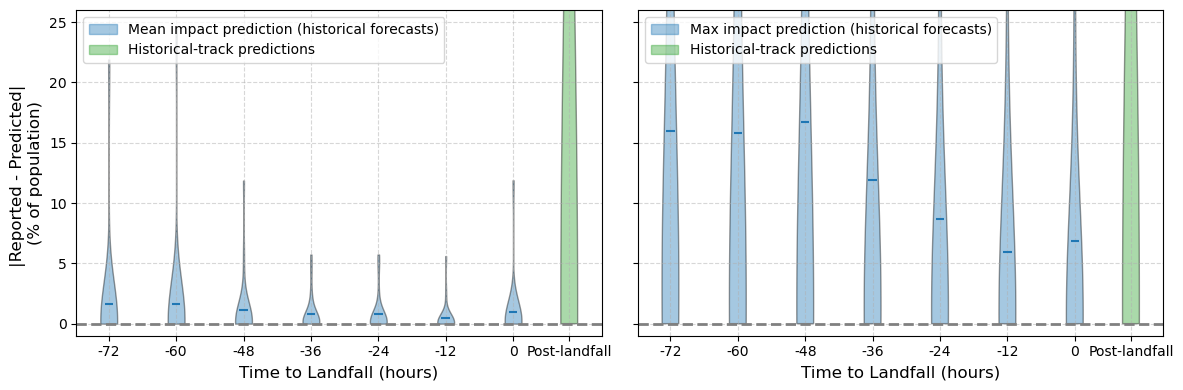

In [16]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd

def plot_mean_max_violin_comparison(adm1_grouped, actual_predictions_adm1):
    """
    Plot violin plots of normalized distance (predicted - reported) vs time-to-landfall
    for both mean and max predictions side by side. Overlay the median of the confidence
    interval width and show the distribution of country-level errors from the real model.
    """

    # ---- Step 1: Compute population-weighted totals per event/time ----
    adm1_grouped["predicted_mean_total"] = adm1_grouped["predicted_mean"] * adm1_grouped["population"] / 100
    adm1_grouped["predicted_plus_std_total"] = adm1_grouped["predicted_plus_std"] * adm1_grouped["population"] / 100
    adm1_grouped["predicted_minus_std_total"] = adm1_grouped["predicted_minus_std"] * adm1_grouped["population"] / 100
    adm1_grouped["predicted_max_total"] = adm1_grouped["predicted_max"] * adm1_grouped["population"] / 100
    adm1_grouped["predicted_wind_mean_total"] = adm1_grouped["predicted_wind_mean"] * adm1_grouped["population"] / 100
    adm1_grouped["predicted_wind_max_total"] = adm1_grouped["predicted_wind_max"] * adm1_grouped["population"] / 100

    # ---- Step 2: Aggregate by event (DisNo.) and delta_time ----
    grouped = (
        adm1_grouped.groupby(["DisNo.", "delta_time"])
        .agg(
            predicted_mean_total=("predicted_mean_total", "sum"),
            predicted_max_total=("predicted_max_total", "sum"),
            predicted_wind_mean_total=("predicted_wind_mean_total", "sum"),
            predicted_wind_max_total=("predicted_wind_max_total", "sum"),
            predicted_plus_std_total=("predicted_plus_std_total", "sum"),
            predicted_minus_std_total=("predicted_minus_std_total", "sum"),
            actual_total=("actual_total", "sum"),
            total_population=("population", "sum")
        )
        .reset_index()
    )

    # ---- Step 3: Normalize by population ----
    grouped["pred_mean_pct"] = grouped["predicted_mean_total"] / grouped["total_population"] * 100
    grouped["pred_max_pct"] = grouped["predicted_max_total"] / grouped["total_population"] * 100
    grouped["pred_wind_mean_pct"] = grouped["predicted_wind_mean_total"] / grouped["total_population"] * 100
    grouped["pred_wind_max_pct"] = grouped["predicted_wind_max_total"] / grouped["total_population"] * 100

    grouped["ci_lower_pct"] = grouped["predicted_minus_std_total"] / grouped["total_population"] * 100
    grouped["ci_upper_pct"] = grouped["predicted_plus_std_total"] / grouped["total_population"] * 100

    grouped["reported_pct"] = grouped["actual_total"] / grouped["total_population"] * 100
    grouped["ci_width"] = grouped["ci_upper_pct"] - grouped["ci_lower_pct"]

    # ---- Step 4: Compute distances (predicted - reported) ----
    grouped["dist_mean"] = np.abs(grouped["pred_mean_pct"] - grouped["reported_pct"])
    grouped["dist_max"] = np.abs(grouped["pred_max_pct"] - grouped["reported_pct"])
    grouped["dist_mean_wind"] = np.abs(grouped["pred_wind_mean_pct"] - grouped["reported_pct"])
    grouped["dist_max_wind"] = np.abs(grouped["pred_wind_max_pct"] - grouped["reported_pct"])

    # ---- Step 5: Prepare data for violins ----
    lead_times = sorted(grouped["delta_time"].unique())
    time_to_landfall = [-t for t in lead_times]  # invert so 0 = landfall

    dist_mean_by_time = [grouped.loc[grouped["delta_time"] == t, "dist_mean_wind"].values
                         for t in lead_times]
    dist_max_by_time = [grouped.loc[grouped["delta_time"] == t, "dist_max_wind"].values
                        for t in lead_times]
    # ci_median_by_time = [np.median(grouped.loc[grouped["delta_time"] == t, "ci_width"].values)
    #                      for t in lead_times]

    # ---- Step 6: Compute final real prediction distribution ----
    df_real_grouped = (
        actual_predictions_adm1.groupby("DisNo.").agg({
            "reported_ppl": "sum",
            "prediction_ppl": "sum",
            "population": "sum"
        })
    ).reset_index()
    df_real_grouped["error_pct"] = (
        100
        * np.abs(df_real_grouped["reported_ppl"] - df_real_grouped["prediction_ppl"])
        / df_real_grouped["population"]
    ).clip(upper=100)


    violin_position = max(time_to_landfall) + 10

    # ---- Step 7: Create subplots ----
    fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

    for ax, dist_data, title, plot_type in zip(
        axes,
        [dist_mean_by_time, dist_max_by_time],
        ["Mean Impact Prediction", "Max Impact Prediction"],
        ["Mean", "Max"]
    ):
        # Main violin
        vp_main = ax.violinplot(
            dist_data,
            positions=time_to_landfall,
            widths=3,
            showmeans=True,
            showextrema=False
        )
        for body in vp_main['bodies']:
            body.set_facecolor('tab:blue')
            body.set_edgecolor('black')
            body.set_alpha(0.4)

        main_violin_patch = mpatches.Patch(
            color='tab:blue', alpha=0.4,
            label=f"{plot_type} impact prediction (historical forecasts)"
        )

        # Reference line
        ax.axhline(0, color="gray", lw=2, linestyle="--", label="Perfect Prediction (0 distance)")
        # if ax==axes[0]:
        #     # CI median
        #     ci_line, = ax.plot(time_to_landfall, ci_median_by_time, color='tab:orange', lw=2,
        #                     linestyle='-', label="CI median")

        # Real-model violin
        vp_real = ax.violinplot(
            [df_real_grouped["error_pct"].values],
            positions=[violin_position],
            widths=3,
            showmeans=True,
            showextrema=False
        )
        for body in vp_real['bodies']:
            body.set_facecolor('tab:green')
            body.set_edgecolor('black')
            body.set_alpha(0.4)
        real_violin_patch = mpatches.Patch(color='tab:green', alpha=0.4, label="Historical-track predictions")

        ax.set_xticks(time_to_landfall + [violin_position])
        ax.set_xticklabels([str(int(x)) for x in time_to_landfall] + ["Post-landfall"])
        ax.set_xlabel("Time to Landfall (hours)", fontsize=12)
        # ax.set_title(title, fontsize=14)
        ax.grid(True, linestyle="--", alpha=0.5)

        ax.set_ylim([-1, 26])

        # Legend
        if ax == axes[0]:
            # ax.legend(handles=[main_violin_patch, real_violin_patch, ci_line], fontsize=10, loc="upper left")
            ax.legend(handles=[main_violin_patch, real_violin_patch], fontsize=10, loc="upper left")
        else:
            ax.legend(handles=[main_violin_patch, real_violin_patch], fontsize=10, loc="upper left")

    axes[0].set_ylabel("|Reported - Predicted| \n(% of population)", fontsize=12)

    plt.tight_layout()
    plt.savefig("/home/fmoss/GLOBAL MODEL/local_files/historical_forecasts_mean_max_comparison_wind.png",
                dpi=300, bbox_inches='tight', pad_inches=0.3)
    plt.show()

plot_mean_max_violin_comparison(adm1_grouped, actual_wind_predictions_adm1)


Time distribution plots

In [18]:
# adm1_grouped["actual_ppl_affected"] = adm1_grouped["reported"] * adm1_grouped["population"]/ 100
# adm1_grouped[["DisNo.", "GID_1", "reported", "population", "delta_time", "actual_total", "actual_ppl_affected"]].sort_values("reported")

In [56]:
adm1_grouped["actual_ppl_affected"] = adm1_grouped["reported"] * adm1_grouped["population"]/ 100

In [57]:
adm1_grouped["predicted_mean_total"] = adm1_grouped["predicted_mean"] * adm1_grouped["population"] / 100
adm1_grouped["predicted_plus_std_total"] = adm1_grouped["predicted_plus_std"] * adm1_grouped["population"] / 100
adm1_grouped["predicted_minus_std_total"] = adm1_grouped["predicted_minus_std"] * adm1_grouped["population"] / 100
adm1_grouped["predicted_max_total"] = adm1_grouped["predicted_max"] * adm1_grouped["population"] / 100
adm1_grouped["predicted_wind_mean_total"] = adm1_grouped["predicted_wind_mean"] * adm1_grouped["population"] / 100
adm1_grouped["predicted_wind_max_total"] = adm1_grouped["predicted_wind_max"] * adm1_grouped["population"] / 100

# ---- Step 2: Aggregate by event (DisNo.) and delta_time ----
grouped = (
    adm1_grouped.groupby(["DisNo.", "delta_time"])
    .agg(
        predicted_mean_total=("predicted_mean_total", "sum"),
        predicted_max_total=("predicted_max_total", "sum"),
        predicted_wind_mean_total=("predicted_wind_mean_total", "sum"),
        predicted_wind_max_total=("predicted_wind_max_total", "sum"),
        predicted_plus_std_total=("predicted_plus_std_total", "sum"),
        predicted_minus_std_total=("predicted_minus_std_total", "sum"),
        actual_total=("actual_ppl_affected", "sum"),
        total_population=("population", "sum"),
        windspeed_mean=("wind_speed_mean", "max")
    )
    .reset_index()
)

In [16]:
adm1_grouped.sort_values("predicted_mean")[["DisNo.", "GID_1", "predicted_mean", "reported"]].sort_values("reported")

,DisNo.,GID_1,predicted_mean,reported
2946,2016-0256-CHN,CHN.10_1,0.000171,0.00000
3513,2012-0294-CHN,CHN.26_1,0.000583,0.00000
3006,2016-0256-CHN,CHN.19_1,0.000472,0.00000
5789,2016-0342-CHN,CHN.30_1,0.000470,0.00000
3090,2016-0256-CHN,CHN.2_1,0.000405,0.00000
...,...,...,...,...
3665,2019-0573-PHL,PHL.17_1,20.240381,57.35953
3885,2019-0573-PHL,PHL.46_1,20.260911,57.35953
266,2019-0424-PRK,PRK.3_1,11.322850,100.00000
265,2019-0424-PRK,PRK.3_1,13.661431,100.00000


In [58]:
adm1_grouped_red = adm1_grouped[["DisNo.", "GID_0", "GID_1", "delta_time", "predicted_mean", "predicted_wind_mean", "actual_total", "population", "reported"]].copy() 
# adm1_grouped_red["reported"] = 100* adm1_grouped_red["actual_total"] / adm1_grouped_red["population"] 

# 2 types of impact: impact or high impact 
adm1_grouped_red_affected = adm1_grouped_red[adm1_grouped_red.reported > 0].copy() #people 
adm1_grouped_red_high_affected = adm1_grouped_red[adm1_grouped_red.reported >= 15].copy()  #percetange 
# Triggers 
adm1_grouped_red_affected["trigger_xgb"] = adm1_grouped_red_affected["predicted_mean"] > 0 
adm1_grouped_red_affected["trigger_wind"] = adm1_grouped_red_affected["predicted_wind_mean"] > 0 

adm1_grouped_red_high_affected["trigger_xgb"] = adm1_grouped_red_high_affected["predicted_mean"] >= 15 
adm1_grouped_red_high_affected["trigger_wind"] = adm1_grouped_red_high_affected["predicted_wind_mean"] >= 15


# ---- Compute APE for both prediction types (only when triggered) ----

# For affected (people > 100)
adm1_grouped_red_affected.loc[adm1_grouped_red_affected["trigger_xgb"], "APE_xgb"] = np.abs(
    adm1_grouped_red_affected.loc[adm1_grouped_red_affected["trigger_xgb"], "predicted_mean"]
    - adm1_grouped_red_affected.loc[adm1_grouped_red_affected["trigger_xgb"], "reported"]
) / adm1_grouped_red_affected.loc[adm1_grouped_red_affected["trigger_xgb"], "reported"]

adm1_grouped_red_affected.loc[adm1_grouped_red_affected["trigger_wind"], "APE_wind"] = np.abs(
    adm1_grouped_red_affected.loc[adm1_grouped_red_affected["trigger_wind"], "predicted_wind_mean"]
    - adm1_grouped_red_affected.loc[adm1_grouped_red_affected["trigger_wind"], "reported"]
) / adm1_grouped_red_affected.loc[adm1_grouped_red_affected["trigger_wind"], "reported"]

# For high-affected (>=15% of pop)
adm1_grouped_red_high_affected.loc[adm1_grouped_red_high_affected["trigger_xgb"], "APE_xgb"] = np.abs(
    adm1_grouped_red_high_affected.loc[adm1_grouped_red_high_affected["trigger_xgb"], "predicted_mean"]
    - adm1_grouped_red_high_affected.loc[adm1_grouped_red_high_affected["trigger_xgb"], "reported"]
) / adm1_grouped_red_high_affected.loc[adm1_grouped_red_high_affected["trigger_xgb"], "reported"]

adm1_grouped_red_high_affected.loc[adm1_grouped_red_high_affected["trigger_wind"], "APE_wind"] = np.abs(
    adm1_grouped_red_high_affected.loc[adm1_grouped_red_high_affected["trigger_wind"], "predicted_wind_mean"]
    - adm1_grouped_red_high_affected.loc[adm1_grouped_red_high_affected["trigger_wind"], "reported"]
) / adm1_grouped_red_high_affected.loc[adm1_grouped_red_high_affected["trigger_wind"], "reported"]


2 out of 26 events with high impacting regions. 2 adm1 regions with high impact. 

PRK is not event complete in time... it can happen that we collect tracks for some hours.. 

- xgb didn't trigger 
- wind didn't trigger

In [11]:
actual_predictions_adm1.columns

Index(['DisNo.', 'GID_0', 'GID_1', 'prediction_ppl', 'actual_total',
       'reported', 'population', 'wind_speed', 'predicted', 'error',
       'abs_error'],
      dtype='object')

In [59]:
# 2 types of impact: impact or high impact 
actual_predictions_adm1_affected = actual_predictions_adm1[actual_predictions_adm1.reported > 0].copy()
actual_predictions_adm1_high_affected = actual_predictions_adm1[actual_predictions_adm1.reported >= 15].copy()  #percetange 

actual_wind_predictions_adm1_affected = actual_wind_predictions_adm1[actual_wind_predictions_adm1.reported > 0].copy()
actual_wind_predictions_adm1_high_affected = actual_wind_predictions_adm1[actual_wind_predictions_adm1.reported >= 15].copy()  #percetange 

# Triggers 
actual_predictions_adm1_affected["trigger_xgb"] = actual_predictions_adm1_affected["predicted"] > 0 
actual_predictions_adm1_high_affected["trigger_xgb"] = actual_predictions_adm1_high_affected["predicted"] >= 15 

actual_wind_predictions_adm1_affected["trigger_wind"] = actual_wind_predictions_adm1_affected["predicted"] > 0 
actual_wind_predictions_adm1_high_affected["trigger_wind"] = actual_wind_predictions_adm1_high_affected["predicted"] >= 15 

import numpy as np

# ---- Compute APE only when triggered ----

# XGB model
actual_predictions_adm1_affected.loc[
    actual_predictions_adm1_affected["trigger_xgb"], "APE_xgb"
] = np.abs(
    actual_predictions_adm1_affected.loc[actual_predictions_adm1_affected["trigger_xgb"], "predicted"]
    - actual_predictions_adm1_affected.loc[actual_predictions_adm1_affected["trigger_xgb"], "reported"]
) / actual_predictions_adm1_affected.loc[actual_predictions_adm1_affected["trigger_xgb"], "reported"]

actual_predictions_adm1_high_affected.loc[
    actual_predictions_adm1_high_affected["trigger_xgb"], "APE_xgb"
] = np.abs(
    actual_predictions_adm1_high_affected.loc[actual_predictions_adm1_high_affected["trigger_xgb"], "predicted"]
    - actual_predictions_adm1_high_affected.loc[actual_predictions_adm1_high_affected["trigger_xgb"], "reported"]
) / actual_predictions_adm1_high_affected.loc[actual_predictions_adm1_high_affected["trigger_xgb"], "reported"]

# Wind model
actual_wind_predictions_adm1_affected.loc[
    actual_wind_predictions_adm1_affected["trigger_wind"], "APE_wind"
] = np.abs(
    actual_wind_predictions_adm1_affected.loc[actual_wind_predictions_adm1_affected["trigger_wind"], "predicted"]
    - actual_wind_predictions_adm1_affected.loc[actual_wind_predictions_adm1_affected["trigger_wind"], "reported"]
) / actual_wind_predictions_adm1_affected.loc[actual_wind_predictions_adm1_affected["trigger_wind"], "reported"]

actual_wind_predictions_adm1_high_affected.loc[
    actual_wind_predictions_adm1_high_affected["trigger_wind"], "APE_wind"
] = np.abs(
    actual_wind_predictions_adm1_high_affected.loc[actual_wind_predictions_adm1_high_affected["trigger_wind"], "predicted"]
    - actual_wind_predictions_adm1_high_affected.loc[actual_wind_predictions_adm1_high_affected["trigger_wind"], "reported"]
) / actual_wind_predictions_adm1_high_affected.loc[actual_wind_predictions_adm1_high_affected["trigger_wind"], "reported"]


In [30]:
adm1_grouped_red_high_affected[adm1_grouped_red_high_affected.delta_time==24][["DisNo.", "GID_1", "trigger_xgb"]].drop_duplicates().sort_values("DisNo.")

,DisNo.,GID_1,trigger_xgb
1377,2016-0503-PHL,PHL.40_1,True
1503,2016-0503-PHL,PHL.5_1,True
1485,2016-0503-PHL,PHL.57_1,False
1467,2016-0503-PHL,PHL.54_1,False
1413,2016-0503-PHL,PHL.46_1,False
...,...,...,...
3679,2019-0573-PHL,PHL.19_1,True
3665,2019-0573-PHL,PHL.17_1,True
3616,2019-0573-PHL,PHL.10_1,True
4134,2019-0573-PHL,PHL.78_1,True


In [27]:
adm1_grouped_red_high_affected[["DisNo.", "GID_1"]].drop_duplicates().sort_values("DisNo.")

,DisNo.,GID_1
1374,2016-0503-PHL,PHL.40_1
1500,2016-0503-PHL,PHL.5_1
1482,2016-0503-PHL,PHL.57_1
1464,2016-0503-PHL,PHL.54_1
1410,2016-0503-PHL,PHL.46_1
...,...,...
3675,2019-0573-PHL,PHL.19_1
3661,2019-0573-PHL,PHL.17_1
3612,2019-0573-PHL,PHL.10_1
4130,2019-0573-PHL,PHL.78_1


In [31]:
actual_predictions_adm1_high_affected[["DisNo.", "GID_1", "trigger_xgb"]].drop_duplicates()

,DisNo.,GID_1,trigger_xgb
21550,2016-0503-PHL,PHL.19_1,False
21552,2016-0503-PHL,PHL.20_1,False
21555,2016-0503-PHL,PHL.23_1,False
21556,2016-0503-PHL,PHL.24_1,False
21574,2016-0503-PHL,PHL.40_1,False
...,...,...,...
25838,2019-0573-PHL,PHL.69_1,False
25845,2019-0573-PHL,PHL.75_1,False
25848,2019-0573-PHL,PHL.78_1,False
25853,2019-0573-PHL,PHL.8_1,False


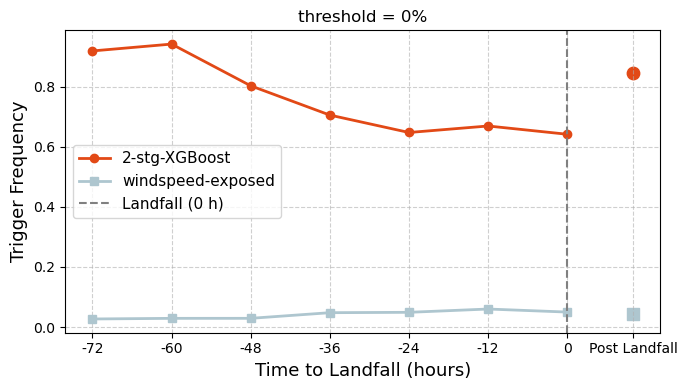

In [15]:

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

def plot_trigger_timing_with_postlandfall(adm1_grouped_red_affected,
                                          actual_predictions_adm1_affected):
    """
    Plot trigger frequency vs. lead time, adding post-landfall APE_xgb as marker on the far right.
    """

    # ---- Pre-landfall trigger rates ----
    trigger_summary = (
        adm1_grouped_red_affected.groupby("delta_time")[["trigger_xgb", "trigger_wind"]]
        .mean()
        .reset_index()
        .sort_values("delta_time")
    )

    # Convert delta_time to hours before landfall (negative = before)
    trigger_summary["time_to_landfall"] = -trigger_summary["delta_time"]

    # ---- Compute post-landfall trigger frequency from real predictions ----
    post_xgb_value = actual_predictions_adm1_affected["trigger_xgb"].mean()
    post_wind_value = adm1_grouped_red_affected["trigger_wind"].mean()  # keep same as pre-landfall

    # Define x-axis location for post-landfall
    post_time = trigger_summary["time_to_landfall"].max() + 10  # offset after last pre-landfall point

    # ---- Plot pre-landfall line ----
    plt.figure(figsize=(7, 4))
    plt.plot(
        trigger_summary["time_to_landfall"],
        trigger_summary["trigger_xgb"],
        marker="o", lw=2, label="2-stg-XGBoost", color="#E24916"
    )
    plt.plot(
        trigger_summary["time_to_landfall"],
        trigger_summary["trigger_wind"],
        marker="s", lw=2, label="windspeed-exposed", color='#AEC6CF'
    )

    # ---- Plot post-landfall points ----
    plt.scatter(post_time, post_xgb_value, color="#E24916", marker="o", s=80)
    plt.scatter(post_time, post_wind_value, color='#AEC6CF', marker="s", s=80)

    # ---- Include post-landfall as xtick ----
    xticks = list(trigger_summary["time_to_landfall"]) + [post_time]
    xtick_labels = [str(int(x)) for x in trigger_summary["time_to_landfall"]] + ["Post Landfall"]
    plt.xticks(xticks, xtick_labels)

    # ---- Formatting ----
    plt.axvline(0, color="gray", lw=1.5, linestyle="--", label="Landfall (0 h)")
    # plt.yscale("log")
    plt.xlabel("Time to Landfall (hours)", fontsize=13)
    plt.ylabel("Trigger Frequency", fontsize=13)
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.title("threshold = 0%")
    plt.legend(fontsize=11)
    plt.tight_layout()
    plt.show()



plot_trigger_timing_with_postlandfall(adm1_grouped_red_affected, actual_predictions_adm1_affected)


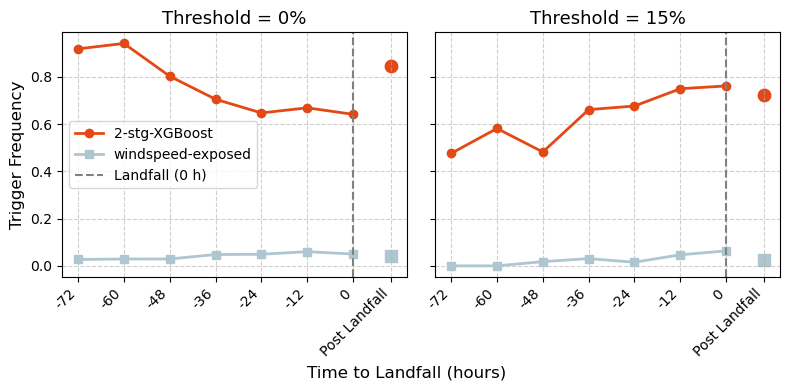

In [61]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

def plot_trigger_timing_comparison(
    adm1_grouped_red_affected, actual_predictions_adm1_affected,
    adm1_grouped_red_high_affected, actual_predictions_adm1_high_affected
):
    """
    Plot trigger frequency vs. lead time for two cases side by side:
    - Left: regular impacting ADM1 units (threshold 0%)
    - Right: high-impacting ADM1 units (threshold 15%)
    """

    fig, axes = plt.subplots(1, 2, figsize=(8, 4), sharey=True)

    for ax, (grouped_df, actual_df, thresh) in zip(
        axes,
        [
            (adm1_grouped_red_affected, actual_predictions_adm1_affected, "0%"),
            (adm1_grouped_red_high_affected, actual_predictions_adm1_high_affected, "15%")
        ]
    ):

        # ---- Pre-landfall trigger rates ----
        trigger_summary = (
            grouped_df.groupby("delta_time")[["trigger_xgb", "trigger_wind"]]
            .mean()
            .reset_index()
            .sort_values("delta_time")
        )

        trigger_summary["time_to_landfall"] = -trigger_summary["delta_time"]

        # ---- Post-landfall trigger frequency from real predictions ----
        post_xgb_value = actual_df["trigger_xgb"].mean()
        post_wind_value = grouped_df["trigger_wind"].mean()  # keep same as pre-landfall

        post_time = trigger_summary["time_to_landfall"].max() + 10  # offset after last pre-landfall point

        # ---- Plot pre-landfall lines ----
        ax.plot(
            trigger_summary["time_to_landfall"],
            trigger_summary["trigger_xgb"],
            marker="o", lw=2, label="2-stg-XGBoost", color="#E24916"
        )
        ax.plot(
            trigger_summary["time_to_landfall"],
            trigger_summary["trigger_wind"],
            marker="s", lw=2, label="windspeed-exposed", color='#AEC6CF'
        )

        # ---- Plot post-landfall points ----
        ax.scatter(post_time, post_xgb_value, color="#E24916", marker="o", s=80)
        ax.scatter(post_time, post_wind_value, color='#AEC6CF', marker="s", s=80)

        # ---- Include post-landfall as xtick ----
        xticks = list(trigger_summary["time_to_landfall"]) + [post_time]
        xtick_labels = [str(int(x)) for x in trigger_summary["time_to_landfall"]] + ["Post Landfall"]
        ax.set_xticks(xticks)
        ax.set_xticklabels(xtick_labels, rotation=45, ha="right")

        # Vertical line at landfall
        ax.axvline(0, color="gray", lw=1.5, linestyle="--", label="Landfall (0 h)")

        # Formatting
        # ax.set_yscale("log")
        if ax == axes[0]:
            ax.set_xlabel("Time to Landfall (hours)", fontsize=12, x=1)
        ax.set_title(f"Threshold = {thresh}", fontsize=13)
        ax.grid(True, linestyle="--", alpha=0.6)

    axes[0].set_ylabel("Trigger Frequency", fontsize=12)
    axes[0].legend(fontsize=10)
    plt.tight_layout()
    # plt.savefig("/home/fmoss/GLOBAL MODEL/local_files/historical_forecasts_trigger_analysis.png", dpi=300)
    plt.show()


# Call the function
plot_trigger_timing_comparison(
    adm1_grouped_red_affected, actual_predictions_adm1_affected,
    adm1_grouped_red_high_affected, actual_predictions_adm1_high_affected
)


Precision and recall vs time to landfall

- Focus on ADM1 affected regions
- 

Differences between windspeed in forecasts and on post-forecasts (curated data)

In [9]:
# forecasts_wind_adm0 = grouped[["DisNo.", "delta_time", "windspeed_mean"]]
# forecasts_wind_adm1 = adm1_grouped[["DisNo.", "GID_1" ,"delta_time", "wind_speed_mean"]]
forecasts_wind_grid = grid_grouped[["DisNo.", "id" ,"delta_time", "wind_speed_mean"]]

In [86]:
forecasts_wind_adm1.loc[forecasts_wind_adm1.wind_speed_mean >= 33, "impact"] = 1
forecasts_wind_adm1.loc[forecasts_wind_adm1.wind_speed_mean < 33, "impact"] = 0
forecasts_wind_adm1.groupby(["delta_time"]).impact.value_counts()

delta_time  impact
0.0         0.0        891
            1.0          8
12.0        0.0       1130
            1.0          9
24.0        0.0       1035
            1.0          8
36.0        0.0       1079
            1.0         11
48.0        0.0        986
            1.0          8
60.0        0.0        861
            1.0          6
72.0        0.0        700
            1.0          5
Name: count, dtype: int64

In [16]:
model_input_red = model_input[["DisNo.", "id", "GID_1" ,"wind_speed"]]
model_input_red = model_input_red[model_input_red["DisNo."].isin(events_to_consider)]

In [17]:
model_wind_adm0 = model_input_red.groupby("DisNo.").wind_speed.max().reset_index()
model_wind_adm1 = model_input_red.groupby(["DisNo.", "GID_1"]).wind_speed.max().reset_index()
model_wind_grid = model_input_red[["DisNo.", "GID_1", "id", "wind_speed"]]

In [18]:
model_wind_adm1.loc[model_wind_adm1.wind_speed >= 33, "impact"] = 1
model_wind_adm1.loc[model_wind_adm1.wind_speed < 33, "impact"] = 0
model_wind_adm1.impact.value_counts()

impact
0.0    1196
1.0      87
Name: count, dtype: int64

In [19]:
# wind_comparison_adm0 = forecasts_wind_adm0.merge(model_wind_adm0)
# wind_comparison_adm1 = forecasts_wind_adm1.merge(model_wind_adm1)

# wind_comparison_grid = forecasts_wind_grid.merge(model_wind_grid)
# Actual high-windspeed regions (grid level)
wind_comparison_grid = forecasts_wind_grid.merge(model_wind_grid[model_wind_grid.wind_speed >= 33], how="right")


# wind_comparison_adm0["diff"] = wind_comparison_adm0["windspeed_mean"] - wind_comparison_adm0["wind_speed"]
# wind_comparison_adm1["diff"] = wind_comparison_adm1["wind_speed_mean"] - wind_comparison_adm1["wind_speed"]
wind_comparison_grid["diff"] = wind_comparison_grid["wind_speed_mean"] - wind_comparison_grid["wind_speed"]

In [20]:
# global_mean_diff_adm0 = wind_comparison_adm0["diff"].mean()
# global_mean_diff_adm1 = wind_comparison_adm1["diff"].mean()
global_mean_diff_grid = wind_comparison_grid["diff"].mean()
print("Global mean difference:", 
# global_mean_diff_adm0, global_mean_diff_adm1, 
global_mean_diff_grid)


Global mean difference: -18.35271717778065


In [21]:
# Percentage difference
# wind_comparison_adm0["diff_pct"] = 100 * (wind_comparison_adm0["windspeed_mean"] - wind_comparison_adm0["wind_speed"]) / wind_comparison_adm0["wind_speed"]
# wind_comparison_adm1["diff_pct"] = 100 * (wind_comparison_adm1["wind_speed_mean"] - wind_comparison_adm1["wind_speed"]) / wind_comparison_adm1["wind_speed"]
wind_comparison_grid["diff_pct"] = 100 * (wind_comparison_grid["wind_speed_mean"] - wind_comparison_grid["wind_speed"]) / wind_comparison_grid["wind_speed"]

# Global mean percentage difference
# global_mean_diff_pct_adm0 = wind_comparison_adm0["diff_pct"].mean()
# global_mean_diff_pct_adm1 = wind_comparison_adm1["diff_pct"].mean()
global_mean_diff_pct_grid = wind_comparison_grid["diff_pct"].mean()

print("Global mean percentage difference (%):", 
      # global_mean_diff_pct_adm0, global_mean_diff_pct_adm1, 
      global_mean_diff_pct_grid)


Global mean percentage difference (%): -46.31567025188457


In [22]:
# global_mean_by_dt_adm0 = wind_comparison_adm0.groupby("delta_time")["diff"].mean()
# global_mean_by_dt_adm1 = wind_comparison_adm1.groupby("delta_time")["diff"].mean()
global_mean_by_dt_grid = wind_comparison_grid.groupby("delta_time")["diff"].mean()
# print("ADM0 mean diff by delta_time:")
# print(global_mean_by_dt_adm0)

# print("\nADM1 mean diff by delta_time:")
# print(global_mean_by_dt_adm1)


In [119]:
wind_comparison_grid

,DisNo.,id,delta_time,wind_speed_mean,GID_1,wind_speed,diff
0,2016-0342-CHN,CHN_169851,72.0,14.002025,CHN.4_1,33.092797,-19.090771
1,2016-0342-CHN,CHN_169851,60.0,20.108156,CHN.4_1,33.092797,-12.984641
2,2016-0342-CHN,CHN_169852,72.0,14.860059,CHN.4_1,33.013733,-18.153674
3,2016-0342-CHN,CHN_169852,60.0,20.506631,CHN.4_1,33.013733,-12.507103
4,2016-0342-CHN,CHN_174040,72.0,11.977695,CHN.4_1,40.401540,-28.423845
...,...,...,...,...,...,...,...
15182,2020-0470-VNM,VNM_12568,60.0,26.970412,VNM.47_1,33.867819,-6.897407
15183,2020-0470-VNM,VNM_12568,48.0,27.322947,VNM.47_1,33.867819,-6.544872
15184,2020-0470-VNM,VNM_12568,36.0,30.990948,VNM.47_1,33.867819,-2.876871
15185,2020-0470-VNM,VNM_12568,24.0,31.234130,VNM.47_1,33.867819,-2.633688


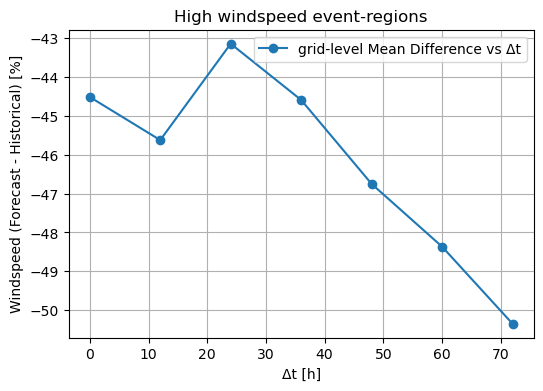

In [23]:
import matplotlib.pyplot as plt

mean_diff_dt_grid = (
    wind_comparison_grid
    .groupby("delta_time", as_index=False)["diff_pct"]
    .mean()
    .rename(columns={"diff_pct": "mean_diff"})
)
fig, ax = plt.subplots(1,1, figsize=(6,4))
mean_diff_dt_grid.plot(x="delta_time", y="mean_diff", marker="o", label="grid-level Mean Difference vs Δt", ax=ax)
ax.set_ylabel("Windspeed (Forecast - Historical) [%]")
ax.set_xlabel("Δt [h]")
plt.title("High windspeed event-regions")
# ax.set_ylim([-14,14])
plt.grid()
plt.legend()
# plt.savefig("/home/fmoss/GLOBAL MODEL/local_files/historical_forecasts_wind_comparison.png", dpi=300)
plt.show()


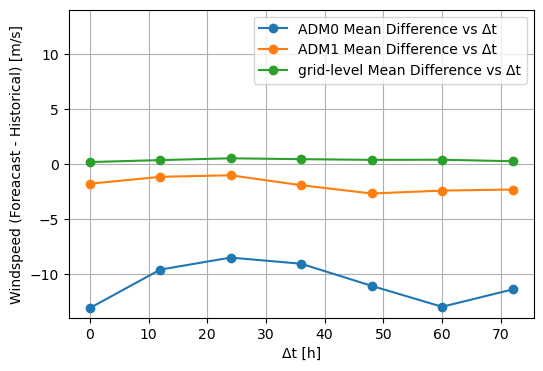

In [77]:
import matplotlib.pyplot as plt
mean_diff_dt_adm0 = (
    wind_comparison_adm0
    .groupby("delta_time", as_index=False)["diff"]
    .mean()
    .rename(columns={"diff": "mean_diff"})
)

mean_diff_dt_adm1 = (
    wind_comparison_adm1
    .groupby("delta_time", as_index=False)["diff"]
    .mean()
    .rename(columns={"diff": "mean_diff"})
)

mean_diff_dt_grid = (
    wind_comparison_grid
    .groupby("delta_time", as_index=False)["diff"]
    .mean()
    .rename(columns={"diff": "mean_diff"})
)
fig, ax = plt.subplots(1,1, figsize=(6,4))
mean_diff_dt_adm0.plot(x="delta_time", y="mean_diff", marker="o", label="ADM0 Mean Difference vs Δt", ax=ax)
mean_diff_dt_adm1.plot(x="delta_time", y="mean_diff", marker="o", label="ADM1 Mean Difference vs Δt", ax=ax)
mean_diff_dt_grid.plot(x="delta_time", y="mean_diff", marker="o", label="grid-level Mean Difference vs Δt", ax=ax)
ax.set_ylabel("Windspeed (Foreacast - Historical) [m/s]")
ax.set_xlabel("Δt [h]")
# plt.title("Mean Difference")
ax.set_ylim([-14,14])
plt.grid()
plt.legend()
plt.savefig("/home/fmoss/GLOBAL MODEL/local_files/historical_forecasts_wind_comparison.png", dpi=300)
plt.show()


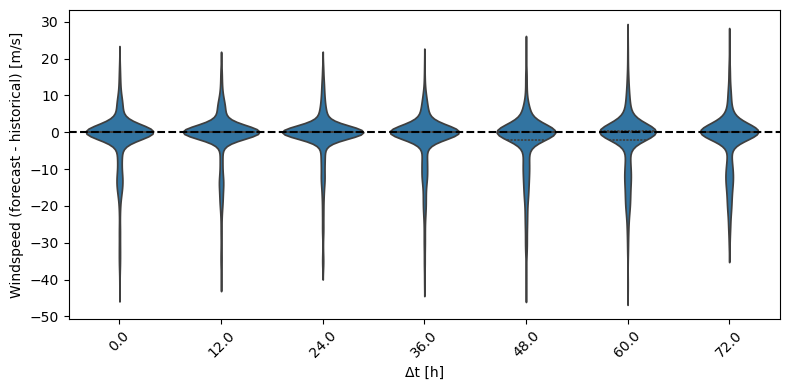

In [52]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,4))
sns.violinplot(data=wind_comparison_adm1, x="delta_time", y="diff", inner="quartile")
plt.axhline(0, color="black", linestyle="--")
# plt.title("Distribution of windspeed forecast error by time to landfall")
plt.xlabel("Δt [h]")
plt.ylabel("Windspeed (forecast - historical) [m/s]")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("/home/fmoss/GLOBAL MODEL/local_files/historical_forecasts_wind_comparison_distributions.png", dpi=300)
plt.show()


Other plots

In [42]:
adm1_grouped_red = adm1_grouped[["DisNo.", 'GID_0', 'GID_1', 'delta_time', 
              'predicted_mean', 'predicted_max',
              'predicted_wind_mean', 'predicted_wind_max',
              'actual_total', 'population']]
adm1_grouped_red['reported'] = adm1_grouped_red['actual_total']  / adm1_grouped_red["population"] * 100

adm1_grouped_red_affected = adm1_grouped_red[adm1_grouped_red.actual_total >= 100] #people
adm1_grouped_red_trigger_affected = adm1_grouped_red[adm1_grouped_red.reported >= 15] #people

/tmp/ipykernel_273484/1732308103.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  adm1_grouped_red['reported'] = adm1_grouped_red['actual_total']  / adm1_grouped_red["population"] * 100


In [41]:
adm1_grouped_red_affected.sort_values("reported")

,DisNo.,GID_0,GID_1,delta_time,predicted_mean,predicted_max,predicted_wind_mean,predicted_wind_max,actual_total,population,reported
3583,2012-0294-CHN,CHN,CHN.6_1,0.0,1.399311,2.035063,0.0,0.000000,273.671719,1.274685e+08,0.000215
3578,2012-0294-CHN,CHN,CHN.6_1,60.0,5.514057,8.733503,0.0,0.000000,273.671719,1.274685e+08,0.000215
3580,2012-0294-CHN,CHN,CHN.6_1,36.0,5.627282,8.226876,0.0,0.000000,273.671719,1.274685e+08,0.000215
3579,2012-0294-CHN,CHN,CHN.6_1,48.0,7.040776,9.271352,0.0,0.000000,273.671719,1.274685e+08,0.000215
3582,2012-0294-CHN,CHN,CHN.6_1,12.0,1.811465,3.741432,0.0,0.575165,273.671719,1.274685e+08,0.000215
...,...,...,...,...,...,...,...,...,...,...,...
2038,2020-0470-VNM,VNM,VNM.9_1,24.0,0.000000,0.000000,0.0,0.000000,629634.998239,2.485752e+06,25.329758
2035,2020-0470-VNM,VNM,VNM.9_1,60.0,0.000000,0.000000,0.0,0.000000,629634.998239,2.485752e+06,25.329758
2034,2020-0470-VNM,VNM,VNM.9_1,72.0,0.255354,6.383848,0.0,0.000000,629634.998239,2.485752e+06,25.329758
2039,2020-0470-VNM,VNM,VNM.9_1,12.0,0.000000,0.000000,0.0,0.000000,629634.998239,2.485752e+06,25.329758


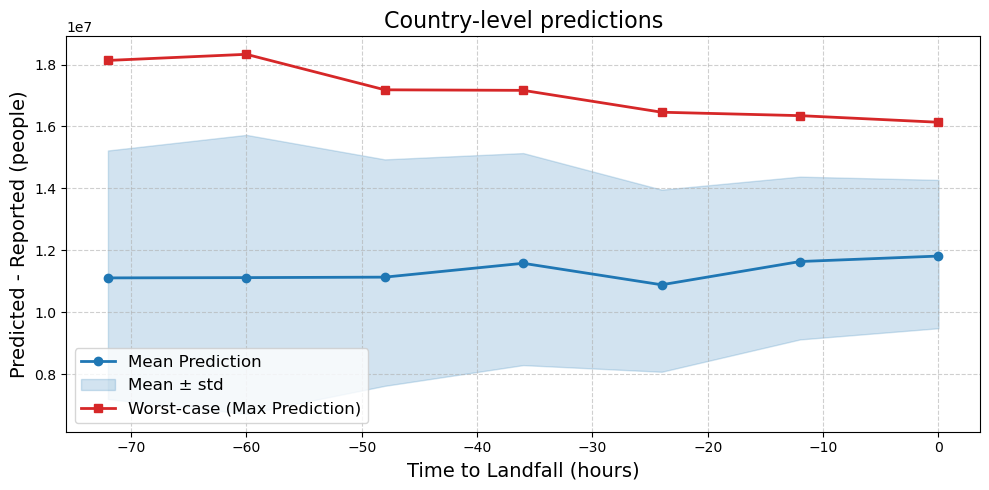

In [ ]:
import matplotlib.pyplot as plt



# Compute population-weighted predictions
adm1_grouped["predicted_mean_total"] = adm1_grouped["predicted_mean"] * adm1_grouped["population"] /100
adm1_grouped["predicted_plus_std_total"]  = adm1_grouped["predicted_plus_std"]  * adm1_grouped["population"] /100
adm1_grouped["predicted_minus_std_total"] = adm1_grouped["predicted_minus_std"] * adm1_grouped["population"] /100
adm1_grouped["predicted_max_total"]       = adm1_grouped["predicted_max"] * adm1_grouped["population"] /100

# Aggregate across ADM1 (GID_1) per delta_time
agg_country = adm1_grouped.groupby("delta_time").agg(
    predicted_mean_total=("predicted_mean_total", "sum"),
    predicted_plus_std_total=("predicted_plus_std_total", "sum"),
    predicted_minus_std_total=("predicted_minus_std_total", "sum"),
    predicted_max_total=("predicted_max_total", "sum"),
    actual_total=("actual_total", "sum")
).reset_index()

# Absolute error for mean prediction
agg_country["abs_error_mean"] = (agg_country["predicted_mean_total"] - agg_country["actual_total"]).abs()

# Confidence interval using mean ± std
agg_country["ci_lower"] = (agg_country["predicted_minus_std_total"] - agg_country["actual_total"]).abs()
agg_country["ci_upper"] = (agg_country["predicted_plus_std_total"] - agg_country["actual_total"]).abs()

# Absolute error for worst-case scenario
agg_country["abs_error_max"] = (agg_country["predicted_max_total"] - agg_country["actual_total"]).abs()


# Time to landfall
time_to_landfall = -agg_country["delta_time"]

plt.figure(figsize=(10, 5))

# Plot mean prediction ± CI
plt.plot(time_to_landfall, agg_country["abs_error_mean"], marker='o', color="tab:blue", lw=2, label="Mean Prediction")
plt.fill_between(
    time_to_landfall,
    agg_country["ci_lower"],
    agg_country["ci_upper"],
    color="tab:blue",
    alpha=0.2,
    label="Mean ± std"
)

# Plot worst-case scenario
plt.plot(time_to_landfall, agg_country["abs_error_max"], marker='s', color="tab:red", lw=2, label="Worst-case (Max Prediction)")

plt.xlabel("Time to Landfall (hours)", fontsize=14)
plt.ylabel("Predicted - Reported (people)", fontsize=14)
plt.title("Country-level predictions", fontsize=16)
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()


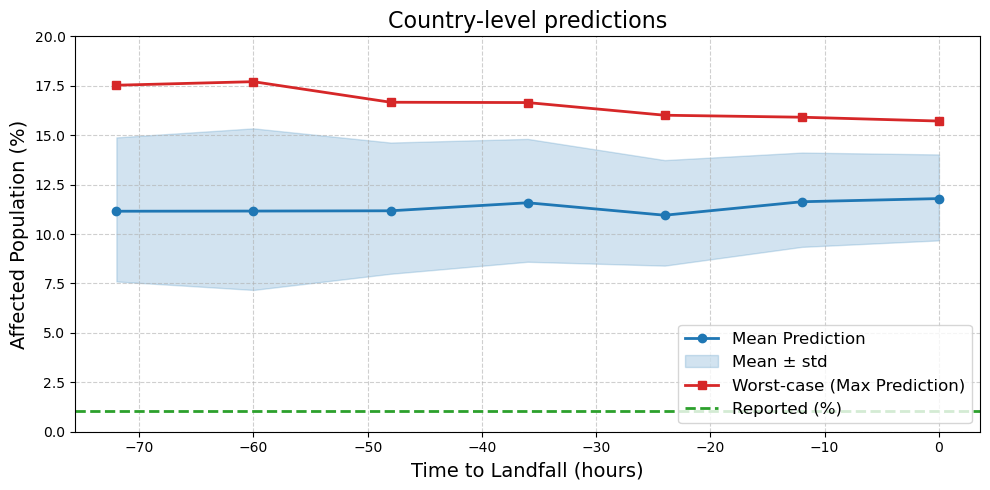

In [100]:
import matplotlib.pyplot as plt

# Compute population-weighted predictions
adm1_grouped["predicted_mean_total"] = adm1_grouped["predicted_mean"] * adm1_grouped["population"] /100
adm1_grouped["predicted_plus_std_total"]  = adm1_grouped["predicted_plus_std"]  * adm1_grouped["population"] /100
adm1_grouped["predicted_minus_std_total"] = adm1_grouped["predicted_minus_std"] * adm1_grouped["population"] /100
adm1_grouped["predicted_max_total"]       = adm1_grouped["predicted_max"] * adm1_grouped["population"] /100

# Aggregate across ADM1 per delta_time
agg_country = adm1_grouped.groupby("delta_time").agg(
    predicted_mean_total=("predicted_mean_total", "sum"),
    predicted_plus_std_total=("predicted_plus_std_total", "sum"),
    predicted_minus_std_total=("predicted_minus_std_total", "sum"),
    predicted_max_total=("predicted_max_total", "sum"),
    actual_total=("actual_total", "sum"),
    total_population=("population", "sum")
).reset_index()

# Normalize by total population
agg_country["abs_error_mean_pct"] = (agg_country["predicted_mean_total"]).abs() / agg_country["total_population"] * 100
agg_country["ci_lower_pct"] = (agg_country["predicted_minus_std_total"]).abs() / agg_country["total_population"] * 100
agg_country["ci_upper_pct"] = (agg_country["predicted_plus_std_total"]).abs() / agg_country["total_population"] * 100
agg_country["abs_error_max_pct"] = (agg_country["predicted_max_total"]).abs() / agg_country["total_population"] * 100

# Reported population percentage
agg_country["reported_pct"] = agg_country["actual_total"] / agg_country["total_population"] * 100

# Time to landfall
time_to_landfall = -agg_country["delta_time"]

plt.figure(figsize=(10, 5))

# Plot mean prediction ± CI
plt.plot(time_to_landfall, agg_country["abs_error_mean_pct"], marker='o', color="tab:blue", lw=2, label="Mean Prediction")
plt.fill_between(
    time_to_landfall,
    agg_country["ci_lower_pct"],
    agg_country["ci_upper_pct"],
    color="tab:blue",
    alpha=0.2,
    label="Mean ± std"
)

# Plot worst-case scenario
plt.plot(time_to_landfall, agg_country["abs_error_max_pct"], marker='s', color="tab:red", lw=2, label="Worst-case (Max Prediction)")

# Plot actual reported population line
plt.axhline(y=agg_country["reported_pct"].iloc[0], color="tab:green", lw=2, linestyle="--", label="Reported (%)")
plt.ylim([0,20])
plt.xlabel("Time to Landfall (hours)", fontsize=14)
plt.ylabel("Affected Population (%)", fontsize=14)
plt.title("Country-level predictions", fontsize=16)
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend(fontsize=12, loc="lower right")
plt.tight_layout()
plt.show()


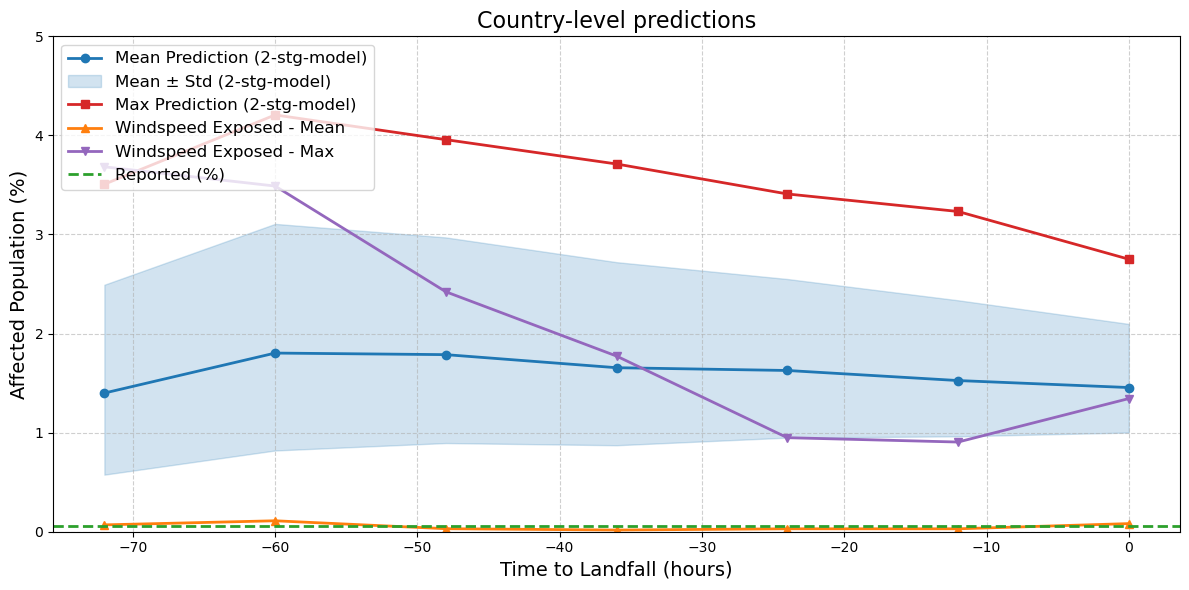

In [28]:
import matplotlib.pyplot as plt

# Compute population-weighted predictions for all scenarios
adm1_grouped["predicted_mean_total"] = adm1_grouped["predicted_mean"] * adm1_grouped["population"] / 100
adm1_grouped["predicted_plus_std_total"]  = adm1_grouped["predicted_plus_std"] * adm1_grouped["population"] / 100
adm1_grouped["predicted_minus_std_total"] = adm1_grouped["predicted_minus_std"] * adm1_grouped["population"] / 100
adm1_grouped["predicted_max_total"]       = adm1_grouped["predicted_max"] * adm1_grouped["population"] / 100
adm1_grouped["predicted_wind_mean_total"] = adm1_grouped["predicted_wind_mean"] * adm1_grouped["population"] / 100
adm1_grouped["predicted_wind_max_total"]  = adm1_grouped["predicted_wind_max"] * adm1_grouped["population"] / 100

# Aggregate across ADM1 per delta_time
agg_country = adm1_grouped.groupby("delta_time").agg(
    predicted_mean_total=("predicted_mean_total", "sum"),
    predicted_plus_std_total=("predicted_plus_std_total", "sum"),
    predicted_minus_std_total=("predicted_minus_std_total", "sum"),
    predicted_max_total=("predicted_max_total", "sum"),
    predicted_wind_mean_total=("predicted_wind_mean_total", "sum"),
    predicted_wind_max_total=("predicted_wind_max_total", "sum"),
    actual_total=("actual_total", "sum"),
    total_population=("population", "sum")
).reset_index()

# Normalize by total population
agg_country["pred_mean_pct"] = agg_country["predicted_mean_total"] / agg_country["total_population"] * 100
agg_country["ci_lower_pct"] = agg_country["predicted_minus_std_total"] / agg_country["total_population"] * 100
agg_country["ci_upper_pct"] = agg_country["predicted_plus_std_total"] / agg_country["total_population"] * 100
agg_country["pred_max_pct"] = agg_country["predicted_max_total"] / agg_country["total_population"] * 100
agg_country["wind_mean_pct"] = agg_country["predicted_wind_mean_total"] / agg_country["total_population"] * 100
agg_country["wind_max_pct"] = agg_country["predicted_wind_max_total"] / agg_country["total_population"] * 100
agg_country["reported_pct"] = agg_country["actual_total"] / agg_country["total_population"] * 100

# Time to landfall
time_to_landfall = -agg_country["delta_time"]

plt.figure(figsize=(12, 6))

# Plot mean prediction ± CI
plt.plot(time_to_landfall, agg_country["pred_mean_pct"], marker='o', color="tab:blue", lw=2, label="Mean Prediction (2-stg-model)")
plt.fill_between(
    time_to_landfall,
    agg_country["ci_lower_pct"],
    agg_country["ci_upper_pct"],
    color="tab:blue",
    alpha=0.2,
    label="Mean ± Std (2-stg-model)"
)

# Plot worst-case scenario
plt.plot(time_to_landfall, agg_country["pred_max_pct"], marker='s', color="tab:red", lw=2, label="Max Prediction (2-stg-model)")

# Plot wind model
plt.plot(time_to_landfall, agg_country["wind_mean_pct"], marker='^', color="tab:orange", lw=2, label="Windspeed Exposed - Mean")
plt.plot(time_to_landfall, agg_country["wind_max_pct"], marker='v', color="tab:purple", lw=2, label="Windspeed Exposed - Max")

# Plot reported population line
plt.axhline(y=agg_country["reported_pct"].iloc[0], color="tab:green", lw=2, linestyle="--", label="Reported (%)")

plt.ylim([0, 5])
plt.xlabel("Time to Landfall (hours)", fontsize=14)
plt.ylabel("Affected Population (%)", fontsize=14)
plt.title("Country-level predictions", fontsize=16)
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend(fontsize=12, loc="upper left")
plt.tight_layout()
plt.show()


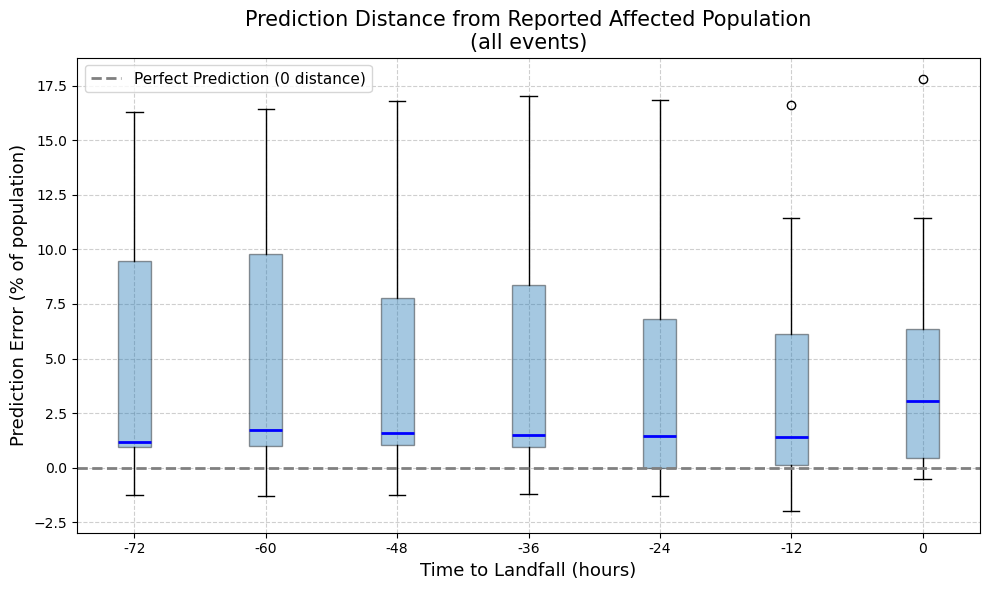

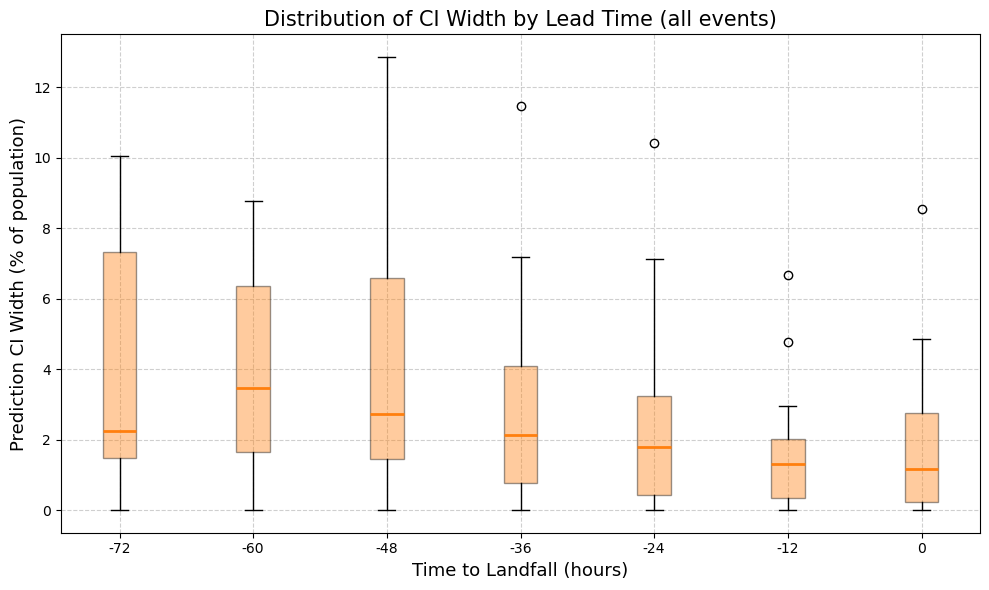

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np


def plot_error_boxplots_by_leadtime(adm1_grouped):
    """
    Plot boxplots of normalized distance (predicted - reported) of affected population
    across all events vs time-to-landfall (negative = underestimation, positive = overestimation).
    """

    # ---- Step 1: Compute population-weighted totals per event/time ----
    adm1_grouped["predicted_mean_total"] = adm1_grouped["predicted_mean"] * adm1_grouped["population"] / 100
    adm1_grouped["predicted_plus_std_total"] = adm1_grouped["predicted_plus_std"] * adm1_grouped["population"] / 100
    adm1_grouped["predicted_minus_std_total"] = adm1_grouped["predicted_minus_std"] * adm1_grouped["population"] / 100

    # ---- Step 2: Aggregate by event (DisNo.) and delta_time ----
    grouped = (
        adm1_grouped.groupby(["DisNo.", "delta_time"])
        .agg(
            predicted_mean_total=("predicted_mean_total", "sum"),
            predicted_plus_std_total=("predicted_plus_std_total", "sum"),
            predicted_minus_std_total=("predicted_minus_std_total", "sum"),
            actual_total=("actual_total", "sum"),
            total_population=("population", "sum")
        )
        .reset_index()
    )

    # ---- Step 3: Normalize by population ----
    grouped["pred_mean_pct"] = grouped["predicted_mean_total"] / grouped["total_population"] * 100
    grouped["ci_lower_pct"] = grouped["predicted_minus_std_total"] / grouped["total_population"] * 100
    grouped["ci_upper_pct"] = grouped["predicted_plus_std_total"] / grouped["total_population"] * 100
    grouped["reported_pct"] = grouped["actual_total"] / grouped["total_population"] * 100

    # ---- Step 4: Compute distances (predicted - reported) ----
    grouped["dist_mean"] = grouped["pred_mean_pct"] - grouped["reported_pct"]
    grouped["dist_lower"] = grouped["ci_lower_pct"] - grouped["reported_pct"]
    grouped["dist_upper"] = grouped["ci_upper_pct"] - grouped["reported_pct"]

    # ---- Step 5: Prepare data for boxplots ----
    lead_times = sorted(grouped["delta_time"].unique())
    time_to_landfall = [-t for t in lead_times]  # invert so that 0 = landfall

    dist_mean_by_time = [grouped.loc[grouped["delta_time"] == t, "dist_mean"].values for t in lead_times]
    dist_lower_by_time = [grouped.loc[grouped["delta_time"] == t, "dist_lower"].values for t in lead_times]
    dist_upper_by_time = [grouped.loc[grouped["delta_time"] == t, "dist_upper"].values for t in lead_times]

    # ---- Step 6: Plot boxplots ----
    plt.figure(figsize=(10, 6))

    bp_mean = plt.boxplot(dist_mean_by_time, positions=time_to_landfall, widths=3,
                          patch_artist=True, boxprops=dict(facecolor='tab:blue', alpha=0.4),
                          medianprops=dict(color='blue', lw=2),
                          labels=[str(int(x)) for x in time_to_landfall])

    # bp_lower = plt.boxplot(dist_lower_by_time, positions=[t - 1.5 for t in time_to_landfall], widths=2.5,
    #                        patch_artist=True, boxprops=dict(facecolor='tab:cyan', alpha=0.3),
    #                        medianprops=dict(color='tab:cyan', lw=1))

    # bp_upper = plt.boxplot(dist_upper_by_time, positions=[t + 1.5 for t in time_to_landfall], widths=2.5,
    #                        patch_artist=True, boxprops=dict(facecolor='tab:purple', alpha=0.3),
    #                        medianprops=dict(color='tab:purple', lw=1))

    plt.axhline(0, color="gray", lw=2, linestyle="--", label="Perfect Prediction (0 distance)")

    # ---- Step 7: Formatting ----
    plt.xlabel("Time to Landfall (hours)", fontsize=13)
    plt.ylabel("Prediction Error (% of population)", fontsize=13)
    plt.title("Prediction Distance from Reported Affected Population\n(all events)", fontsize=15)
    plt.grid(True, linestyle="--", alpha=0.6)
    # plt.legend(["Perfect prediction", "Predicted mean", "Predicted CI lower", "Predicted CI upper"],
    #            fontsize=11, loc="upper left")
    plt.legend(loc="upper left", fontsize=11)
    plt.tight_layout()
    plt.show()


def plot_ci_width_boxplots_by_leadtime(adm1_grouped):
    """
    Plot boxplots of confidence interval (upper - lower) width in predicted affected population (%)
    across all events vs time-to-landfall.
    """

    # ---- Step 1: Compute population-weighted totals per event/time ----
    adm1_grouped["predicted_plus_std_total"] = adm1_grouped["predicted_plus_std"] * adm1_grouped["population"] / 100
    adm1_grouped["predicted_minus_std_total"] = adm1_grouped["predicted_minus_std"] * adm1_grouped["population"] / 100

    # ---- Step 2: Aggregate by event (DisNo.) and delta_time ----
    grouped = (
        adm1_grouped.groupby(["DisNo.", "delta_time"])
        .agg(
            predicted_plus_std_total=("predicted_plus_std_total", "sum"),
            predicted_minus_std_total=("predicted_minus_std_total", "sum"),
            total_population=("population", "sum")
        )
        .reset_index()
    )

    # ---- Step 3: Normalize by population ----
    grouped["ci_upper_pct"] = grouped["predicted_plus_std_total"] / grouped["total_population"] * 100
    grouped["ci_lower_pct"] = grouped["predicted_minus_std_total"] / grouped["total_population"] * 100

    # ---- Step 4: Compute CI width ----
    grouped["ci_width"] = grouped["ci_upper_pct"] - grouped["ci_lower_pct"]

    # ---- Step 5: Prepare data for boxplots ----
    lead_times = sorted(grouped["delta_time"].unique())
    time_to_landfall = [-t for t in lead_times]  # invert so that 0 = landfall
    ci_width_by_time = [grouped.loc[grouped["delta_time"] == t, "ci_width"].values for t in lead_times]

    # ---- Step 6: Plot boxplots ----
    plt.figure(figsize=(10, 6))

    plt.boxplot(ci_width_by_time, positions=time_to_landfall, widths=3,
                patch_artist=True, boxprops=dict(facecolor='tab:orange', alpha=0.4),
                medianprops=dict(color='tab:orange', lw=2),
                labels=[str(int(x)) for x in time_to_landfall])

    plt.xlabel("Time to Landfall (hours)", fontsize=13)
    plt.ylabel("Prediction CI Width (% of population)", fontsize=13)
    plt.title("Distribution of CI Width by Lead Time (all events)", fontsize=15)
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.tight_layout()
    plt.show()

# --- Run both ---
plot_error_boxplots_by_leadtime(adm1_grouped)
plot_ci_width_boxplots_by_leadtime(adm1_grouped)


Map plots

In [24]:
global_shp = gpd.read_file("/data/big/fmoss/data/SHP/GADM_adm1.gpkg")

In [ ]:
phl_shp = global_shp[global_shp.GID_0=="PHL"]

# Example: get tracks for a storm
storm = '2019-0573-PHL'
storm_tracks_list = results[storm]  # list of DataFrames, each member × time_0


In [22]:
import matplotlib.pyplot as plt
import math
from itertools import groupby

def plot_ensemble_tracks_with_adm1_predictions(
    storm_tracks_list, phl_shp, adm1_grouped, ncols=3, variable = 'predicted_mean', title=""
):
    """
    Overlay ensemble storm tracks with ADM1-level predicted_mean values.
    Each subplot is a different time_0. Tracks are dark gray lines.
    ADM1 polygons are colored by predicted_mean.
    """
    import matplotlib as mpl
    import math

    # Ensure sorted by time_0
    storm_tracks_list.sort(key=lambda df: df['time_0'].iloc[0])
    last_time0 = pd.to_datetime(storm_tracks_list[-1]['time_0'].iloc[0])
    
    # Group tracks by time_0
    from itertools import groupby
    grouped_time0 = [(time0, list(members)) 
                     for time0, members in groupby(storm_tracks_list, key=lambda df: df['time_0'].iloc[0])]
    
    num_subplots = len(grouped_time0)
    nrows = math.ceil(num_subplots / ncols)
    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(ncols*5, nrows*5))
    axes = axes.flatten()
    # Determine vmin/vmax for color scale across all ADM1 predictions
    vmin = adm1_grouped[variable].min()
    vmax = adm1_grouped[variable].max()

    for i, (time0, members) in enumerate(grouped_time0):
        ax = axes[i]
        
        # Compute delta_time (hours to landfall)
        current_time0 = pd.to_datetime(time0)
        time_to_landfall = (last_time0 - current_time0).total_seconds() / 3600.0
        
        # Merge ADM1 polygons with predictions for this delta_time
        adm1_plot = adm1_grouped[adm1_grouped['delta_time'] == time_to_landfall].copy()
        if not adm1_plot.empty:
            adm1_gdf = phl_shp.merge(adm1_plot, on='GID_1', how='left')
            adm1_gdf.plot(
                ax=ax,
                column=variable,
                cmap='OrRd',
                edgecolor='black',
                alpha=0.7,
                vmin=vmin,
                vmax=vmax
            )
        else:
            phl_shp.plot(ax=ax, color="lightgray", edgecolor="black")
        
        # Plot all ensemble members as dark gray lines
        for df in members:
            df_sorted = df.sort_values("hour")
            ax.plot(df_sorted["longitude"], df_sorted["latitude"], color='darkgray', lw=1, alpha=0.5)
        
        # Axis settings
        ax.set_xlim(111, 138)
        ax.set_ylim(4, 22.05)
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_title(f"{time_to_landfall:.1f} h to landfall", fontsize=15)
        ax.grid(False)
    
    # Hide unused subplots
    for j in range(i+1, len(axes)):
        axes[j].axis('off')

    # Add horizontal colorbar below all subplots
    cbar_ax = fig.add_axes([0.15, -0.05, 0.7, 0.03])  # [left, bottom, width, height]
    sm = mpl.cm.ScalarMappable(cmap='OrRd', norm=mpl.colors.Normalize(vmin=vmin, vmax=vmax))
    sm._A = []
    cbar = fig.colorbar(sm, cax=cbar_ax, orientation='horizontal')
    cbar.set_label("Predicted (%)", fontsize=20)
    # Increase tick label size
    cbar.ax.tick_params(labelsize=16)
    
    plt.suptitle(title, size=20)
    plt.tight_layout()
    plt.show()


/tmp/ipykernel_395482/1411586611.py:83: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


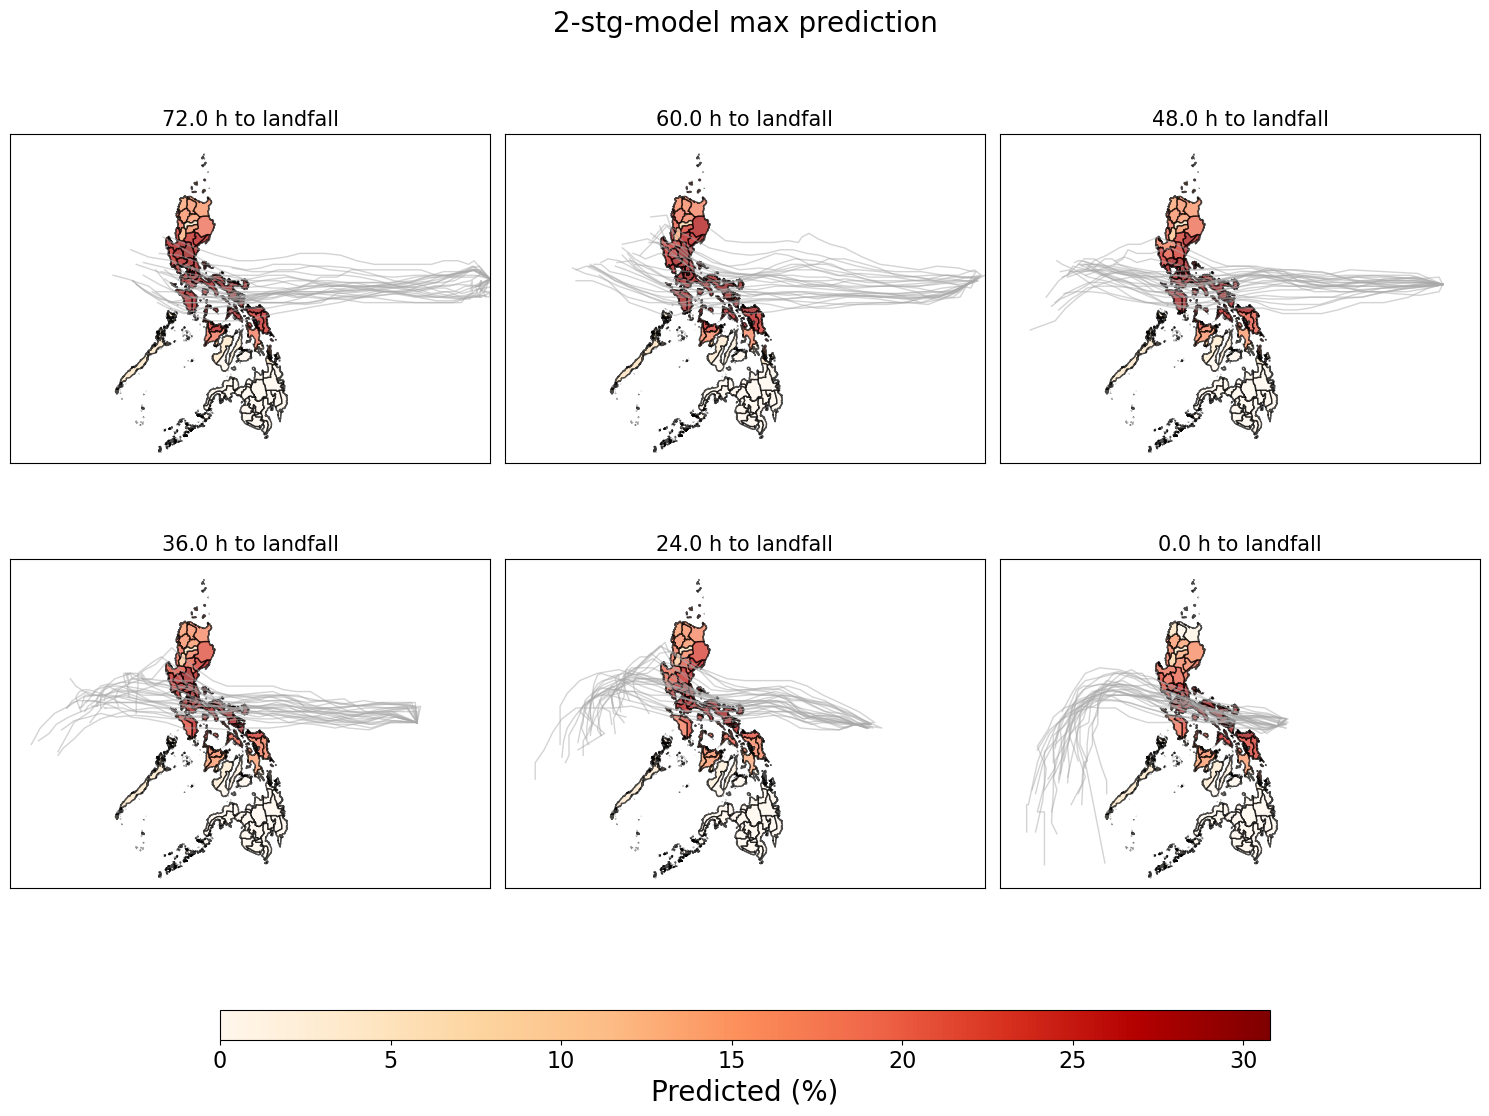

In [118]:
# Skip the first time_0 for symmetry
plot_ensemble_tracks_with_adm1_predictions(
    storm_tracks_list[26:], 
    phl_shp, 
    adm1_grouped, 
    ncols=3,
    variable="predicted_max",
    title="2-stg-model max prediction")


/tmp/ipykernel_395482/1411586611.py:83: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


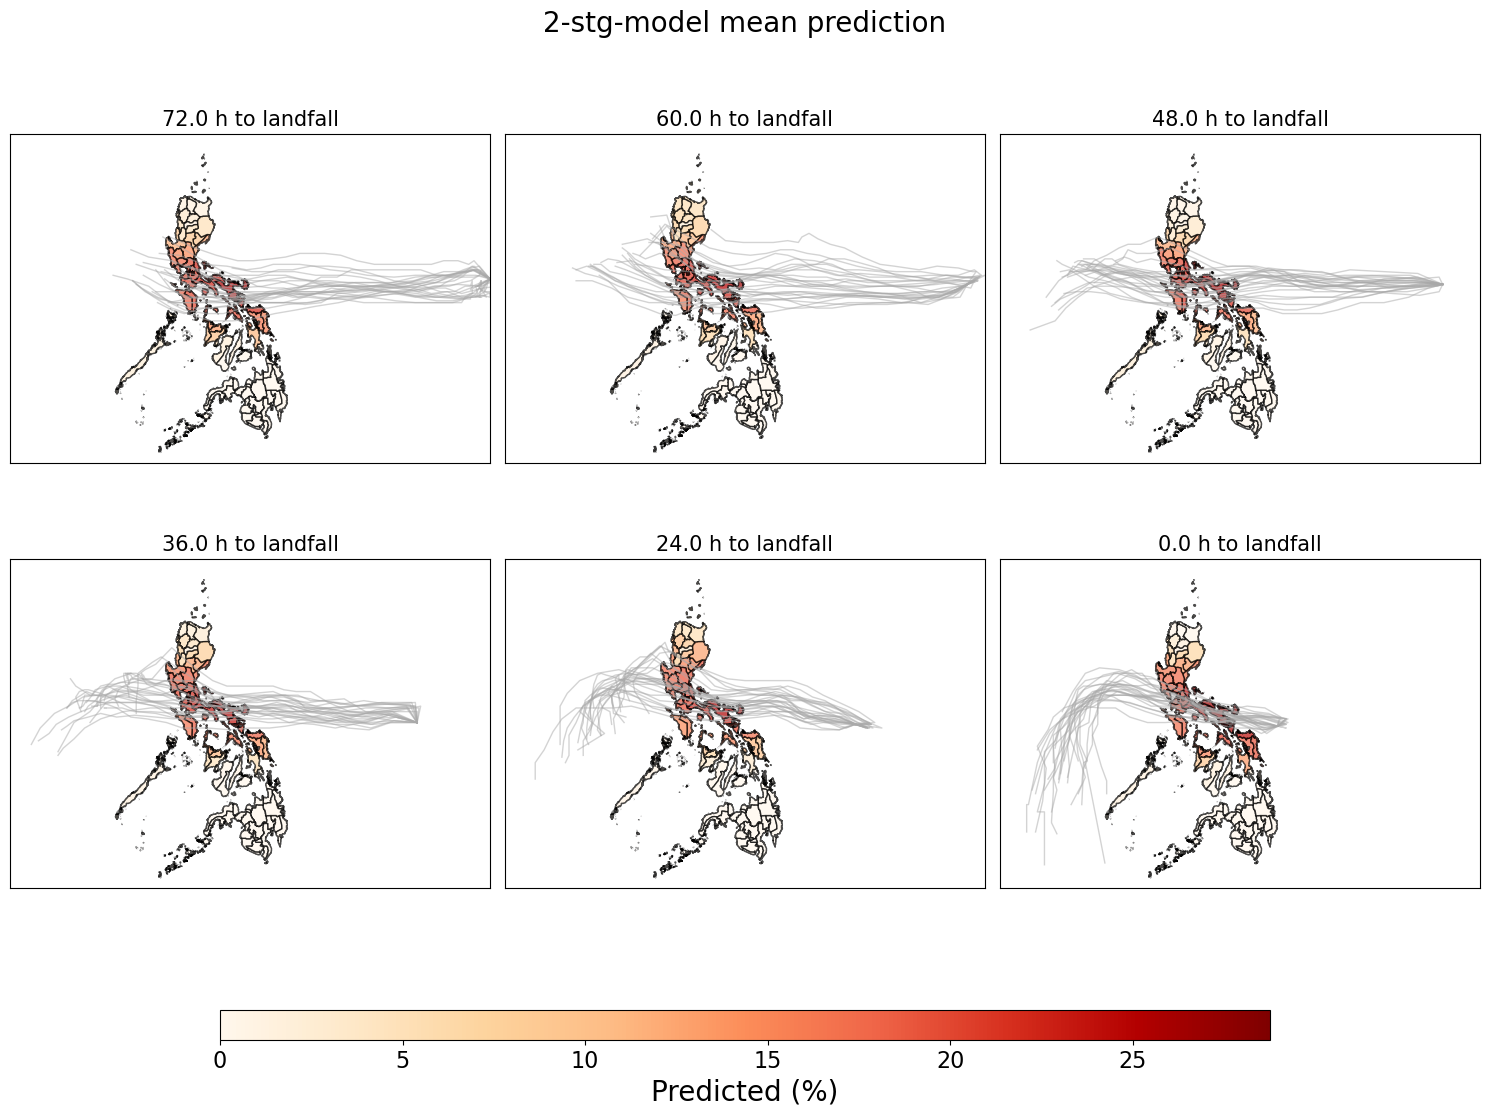

In [119]:
# Skip the first time_0 for symmetry
plot_ensemble_tracks_with_adm1_predictions(
    storm_tracks_list[26:], 
    phl_shp, 
    adm1_grouped, 
    ncols=3,
    variable="predicted_mean",
    title="2-stg-model mean prediction")

/tmp/ipykernel_395482/1411586611.py:83: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


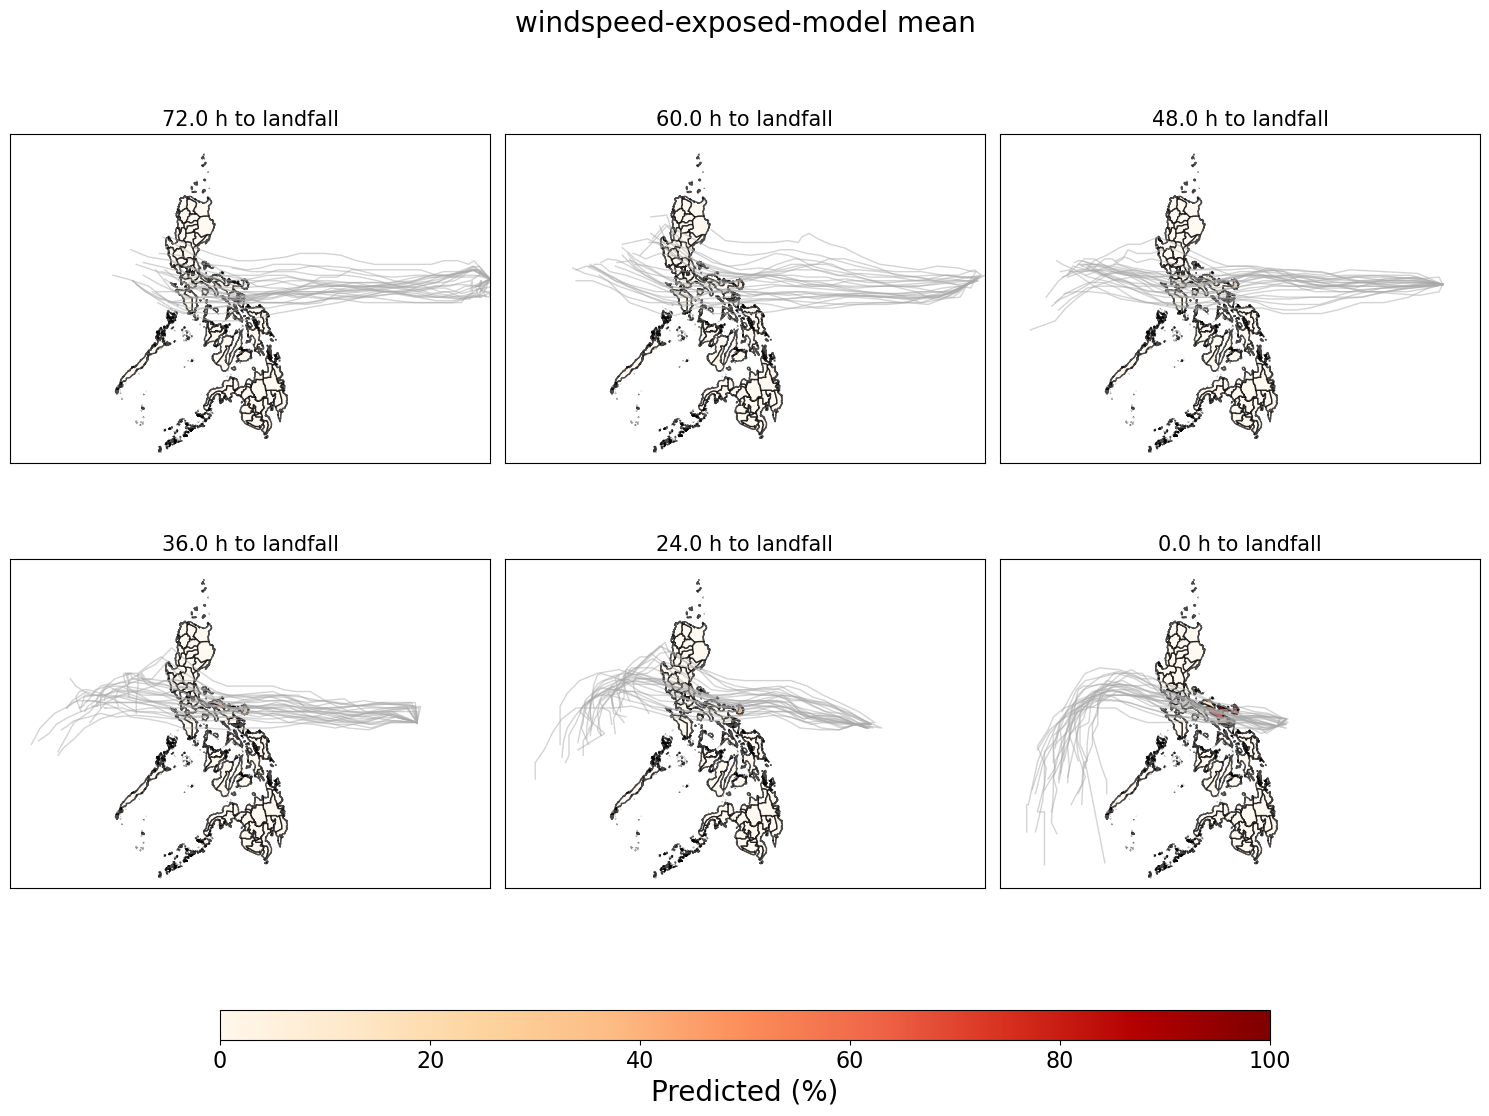

In [120]:
# Skip the first time_0 for symmetry
plot_ensemble_tracks_with_adm1_predictions(
    storm_tracks_list[26:], 
    phl_shp, 
    adm1_grouped, 
    ncols=3,
    variable="predicted_wind_mean",
    title="windspeed-exposed-model mean")

/tmp/ipykernel_395482/1411586611.py:83: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


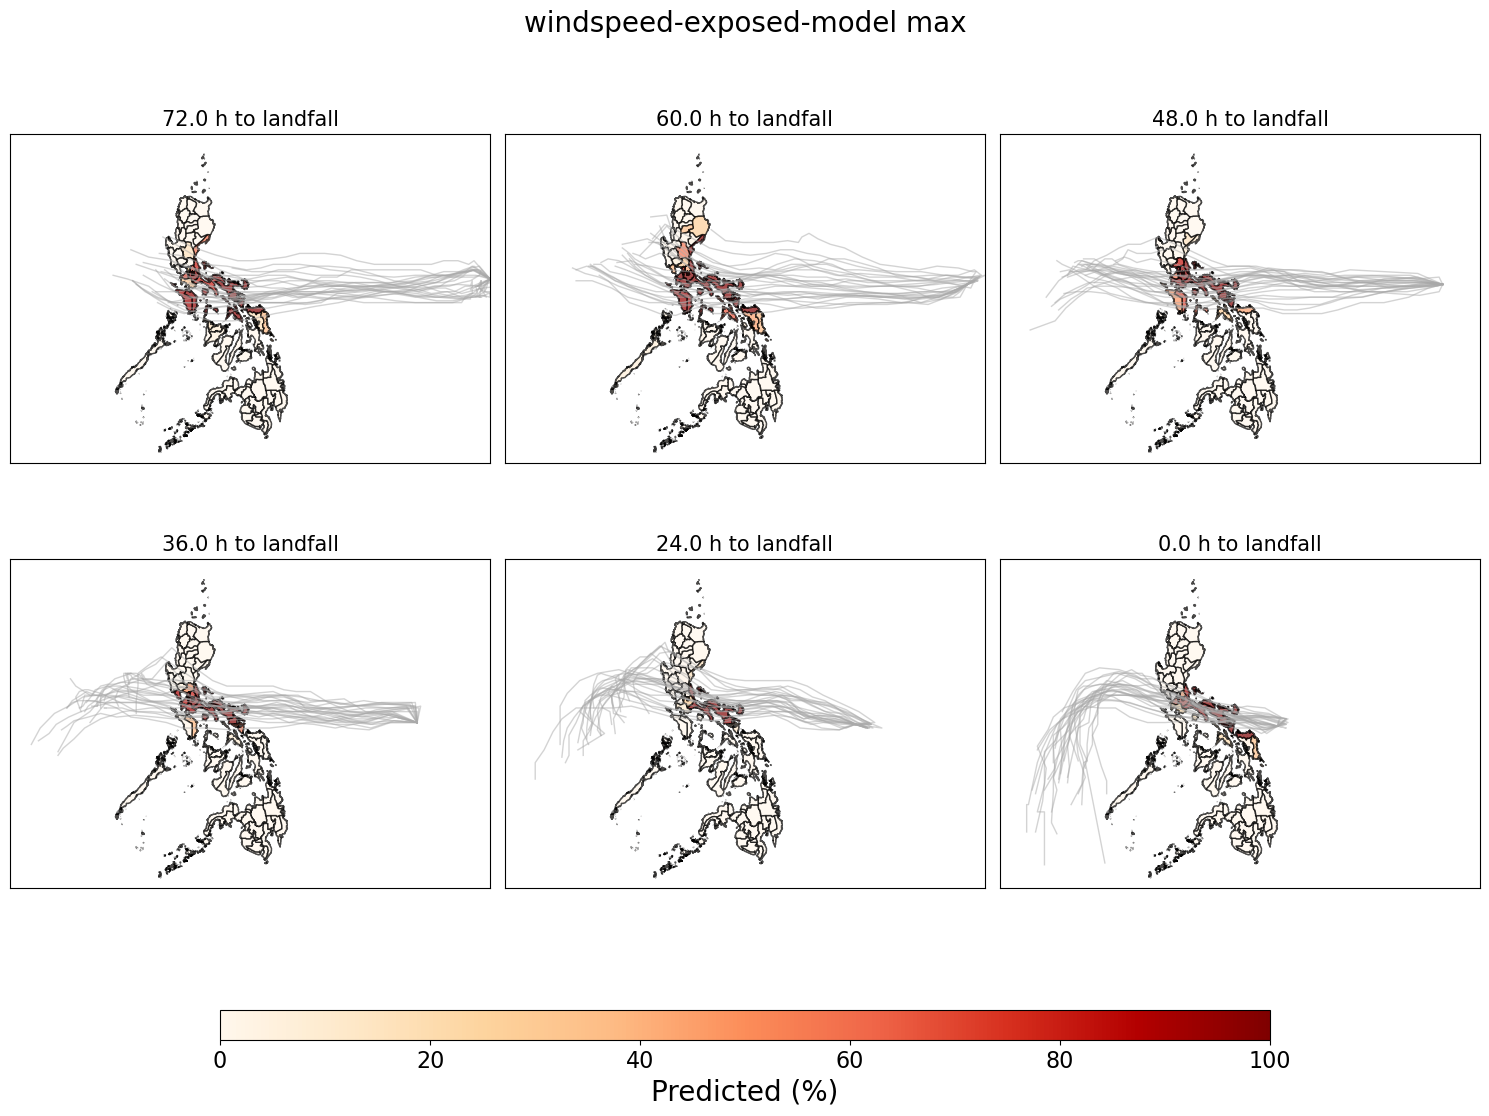

In [121]:
# Skip the first time_0 for symmetry
plot_ensemble_tracks_with_adm1_predictions(
    storm_tracks_list[26:], 
    phl_shp, 
    adm1_grouped, 
    ncols=3,
    variable="predicted_wind_max",
    title="windspeed-exposed-model max")